In [ ]:
import os
import subprocess
from pathlib import Path

# --- KONFIGURASI ---
folder_input = Path('PCAPs/').resolve()
folder_output = Path('DATASETS/CICIDS2017/PCAPs/hasilKonversiCAPtoCSV2').resolve()
tshark_path = r'C:\Program Files\Wireshark\tshark.exe' 

if not folder_output.exists():
    folder_output.mkdir(parents=True, exist_ok=True)
    print(f"Folder dibuat: {folder_output}")

# Menambahkan icmp.type dan icmp.code ke dalam daftar field
fields = [
    '-e', 'frame.number', 
    '-e', 'frame.time', 
    '-e', 'frame.time_delta',
    '-e', 'eth.src', 
    '-e', 'eth.dst', 
    '-e', 'ip.src', 
    '-e', 'ip.dst',
    '-e', 'ip.proto', 
    '-e', 'icmp.type',      # Mengetahui jenis error (misal: 3 untuk Unreachable)
    '-e', 'icmp.code',      # Mengetahui detail (misal: 3 untuk Port Unreachable)
    '-e', 'tcp.srcport',
    '-e', 'udp.srcport', 
    '-e', 'tcp.dstport', 
    '-e', 'udp.dstport',
    '-e', 'frame.len', 
    '-e', 'tcp.flags.str', 
    '-e', 'tcp.seq',
    '-e', 'tcp.ack', 
    '-e', '_ws.col.Protocol', 
    '-e', '_ws.col.Info'
]

def konversi_masal():
    files_found = [f for f in folder_input.rglob('*') if f.is_file() and f.suffix.lower() in ['.cap', '.pcap']]
    
    if not files_found:
        print(f"Tidak ditemukan file di {folder_input}")
        return

    print(f"Ditemukan {len(files_found)} file. Memulai konversi...")

    for pcap_file in files_found:
        csv_file = folder_output / (pcap_file.stem + ".csv")
        
        # Command TShark dengan penanganan field ICMP
        command = [
            tshark_path, 
            '-n',
            '-r', str(pcap_file.absolute()),
            '-T', 'fields'
        ] + fields + [
            '-E', 'header=y',
            '-E', 'separator=,',
            '-E', 'quote=d',
            # Opsional: Jika Anda ingin membersihkan data '1,6' di tahap ekstraksi, 
            # Anda bisa menambahkan '-E', 'occurrence=f' di sini. 
            # Namun karena Anda ingin melihat HUBUNGANNYA, biarkan default (tanpa occurrence=f).
        ]
        
        try:
            with open(csv_file, "w", encoding='utf-8') as outfile:
                result = subprocess.run(command, stdout=outfile, stderr=subprocess.PIPE, text=True, check=True)
            print(f"Berhasil: {pcap_file.name} -> {csv_file.name} {list(df.columns)} ({len(df)} baris)")
        except subprocess.CalledProcessError as e:
            print(f"Gagal pada file {pcap_file.name}:")
            print(f"Pesan Error TShark: {e.stderr}")
        except Exception as e:
            print(f"Error sistem: {e}")

if __name__ == "__main__":
    konversi_masal()

Ditemukan 5 file. Memulai konversi...


In [ ]:
import pandas as pd
import gc
import os
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# --- KONFIGURASI FILE ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_dir = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter"
output_parquet = os.path.join(output_dir, "Friday-WorkingHoursV1New.parquet")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

LIMIT_PACKETS = 5000  # Sesuai permintaan Anda

# --- MODIFIKASI CLASS FLOW (MONKEY PATCHING) ---

# 1. Simpan referensi fungsi asli
original_get_data = Flow.get_data

def patched_get_data(self):
    # Ambil 84 kolom standar asli
    data = original_get_data(self)
    
    # Tambahkan kolom kustom Pak Arie ke dalam dictionary
    data["flow_id"] = getattr(self, 'flow_id_custom', "")
    data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    data["frame_len"] = getattr(self, 'frame_len', 0)
    data["ip_id"] = getattr(self, 'ip_id', 0)
    data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    data["payload_len"] = getattr(self, 'payload_len_custom', 0)
    data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    data["tcp_window_size_value"] = getattr(self, 'tcp_win', 0)
    data["tcp_flags_str"] = getattr(self, 'tcp_flags_str', "")
    data["tcp_seq"] = getattr(self, 'tcp_seq', 0)
    data["tcp_ack"] = getattr(self, 'tcp_ack', 0)
    data["icmp_type"] = getattr(self, 'icmp_type', -1)
    data["icmp_code"] = getattr(self, 'icmp_code', -1)
    
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # Inisialisasi atribut kustom pada paket pertama flow
    if not hasattr(self, 'eth_src'):
        self.flow_id_custom = f"{packet['IP'].src}-{packet['IP'].dst}-{packet['IP'].proto}-{packet.sport if hasattr(packet, 'sport') else 0}"
        self.eth_src = packet.src if hasattr(packet, 'src') else ""
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else ""
        self.frame_len = len(packet)
        self.ip_id = 0
        self.ip_ttl = 0
        self.payload_len_custom = 0
        self.tcp_mss = 0
        self.tcp_win = 0
        self.tcp_flags_str = ""
        self.tcp_seq = 0
        self.tcp_ack = 0
        self.icmp_type = -1
        self.icmp_code = -1

    # Ekstraksi IP Layer
    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        if packet["IP"].payload:
            self.payload_len_custom = len(packet["IP"].payload)

    # Ekstraksi TCP Layer
    if packet.haslayer("TCP"):
        tcp = packet["TCP"]
        self.tcp_win = tcp.window
        self.tcp_flags_str = str(tcp.flags)
        self.tcp_seq = tcp.seq
        self.tcp_ack = tcp.ack
        opts = dict(x for x in tcp.options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)

    # Ekstraksi ICMP Layer
    if packet.haslayer("ICMP"):
        self.icmp_type = packet["ICMP"].type
        self.icmp_code = packet["ICMP"].code

    # Jalankan logika perhitungan statistik asli CICFlowMeter
    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)
    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))
    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))
    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto

# Terapkan patch ke library
Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- PROSES EKSTRAKSI ---

def main():
    print(f"[*] Memulai ekstraksi {LIMIT_PACKETS} paket...")
    flows = {}
    count = 0

    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if packet.haslayer("IP"):
                    count += 1
                    p = packet["IP"]
                    # 5-tuple key
                    key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0, packet.dport if hasattr(packet, 'dport') else 0)
                    
                    if key not in flows:
                        flows[key] = Flow(packet, PacketDirection.FORWARD)
                    
                    flows[key].add_packet(packet, PacketDirection.FORWARD)

                if count >= LIMIT_PACKETS:
                    break

        # Konversi ke DataFrame
        data_list = [f.get_data() for f in flows.values()]
        df = pd.DataFrame(data_list)

        # Simpan ke Parquet
        print(f"[*] Menyimpan {len(df)} flow ke {output_parquet}...")
        df.to_parquet(output_parquet, engine='pyarrow', index=False)
        print("[+] Ekstraksi selesai dengan sukses.")

    except Exception as e:
        print(f"[-] Terjadi kesalahan: {e}")

    finally:
        # Manajemen Memori
        del flows
        if 'df' in locals(): del df
        gc.collect()
        print("[*] Memori dibersihkan.")

if __name__ == "__main__":
    main()

[*] Memulai ekstraksi 5000 paket...
[-] Terjadi kesalahan: maximum recursion depth exceeded
[*] Memori dibersihkan.


In [ ]:
import pandas as pd
import gc
import os
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# Import fitur internal untuk memperbaiki kerusakan library
from cicflowmeter.features.packet_count import PacketCount
from cicflowmeter.features.packet_length import PacketLength
from cicflowmeter.features.packet_time import PacketTime
from cicflowmeter.features.flow_bytes import FlowBytes
from cicflowmeter.features.flag_count import FlagCount

# --- CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet"

os.makedirs(os.path.dirname(output_parquet), exist_ok=True)

# Simpan fungsi get_data asli sebelum di-patch
original_get_data = Flow.get_data

# --- PATCH GET_DATA ---
def patched_get_data(self):
    data = original_get_data(self)
    data.update({
        "flow_id_custom": getattr(self, 'flow_id_custom', ""),
        "eth_src": getattr(self, 'eth_src', "00:00:00:00:00:00"),
        "eth_dst": getattr(self, 'eth_dst', "00:00:00:00:00:00"),
        "frame_len": getattr(self, 'frame_len', 0),
        "ip_id": getattr(self, 'ip_id', 0),
        "ip_ttl": getattr(self, 'ip_ttl', 0),
        "payload_len_custom": getattr(self, 'payload_len_custom', 0),
        "tcp_mss": getattr(self, 'tcp_mss', 0),
        "tcp_window_size_value": getattr(self, 'tcp_win', 0),
        "tcp_flags_str": getattr(self, 'tcp_flags_str', ""),
        "tcp_seq": getattr(self, 'tcp_seq', 0),
        "tcp_ack": getattr(self, 'tcp_ack', 0),
        "icmp_type": getattr(self, 'icmp_type', -1),
        "icmp_code": getattr(self, 'icmp_code', -1),
    })
    return data

# --- PATCH ADD_PACKET ---
def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    if not hasattr(self, 'packet_count'):
        self.packet_count = PacketCount(self)
        self.packet_length = PacketLength(self)
        self.packet_time = PacketTime(self)
        self.flow_bytes = FlowBytes(self)
        self.flag_count = FlagCount(self)
        self.init_window_size = {PacketDirection.FORWARD: 0, PacketDirection.REVERSE: 0}
        
        # Metadata awal
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"
        self.frame_len = len(packet)
        
        # Penanganan Flow ID yang aman
        src_ip = packet["IP"].src if packet.haslayer("IP") else "0.0.0.0"
        dst_ip = packet["IP"].dst if packet.haslayer("IP") else "0.0.0.0"
        proto = packet["IP"].proto if packet.haslayer("IP") else 0
        sport = packet.sport if hasattr(packet, 'sport') else 0
        dport = packet.dport if hasattr(packet, 'dport') else 0
        self.flow_id_custom = f"{src_ip}-{dst_ip}-{sport}-{dport}-{proto}"

        self.ip_id = self.ip_ttl = self.payload_len_custom = 0
        self.tcp_mss = self.tcp_win = self.tcp_seq = self.tcp_ack = 0
        self.tcp_flags_str = ""
        self.icmp_type = self.icmp_code = -1

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        if packet["IP"].payload: self.payload_len_custom = len(packet["IP"].payload)
    
    if packet.haslayer("TCP"):
        tcp = packet["TCP"]
        self.tcp_win, self.tcp_flags_str, self.tcp_seq, self.tcp_ack = tcp.window, str(tcp.flags), tcp.seq, tcp.ack
        opts = dict(x for x in tcp.options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)
        
    if packet.haslayer("ICMP"):
        self.icmp_type, self.icmp_code = packet["ICMP"].type, packet["ICMP"].code

    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)
    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))
    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))
    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else 0

# Suntikkan patch
Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- EXECUTION ---
def run_extraction():
    flows = {}
    pkt_count = 0
    print(f"[*] Memulai ekstraksi 5000 paket...")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if packet.haslayer("IP"):
                    #pkt_count += 1
                    p = packet["IP"]
                    
                    # PERBAIKAN: Cara mengambil sport/dport yang aman
                    src_port = packet.sport if hasattr(packet, 'sport') else (packet["TCP"].sport if packet.haslayer("TCP") else (packet["UDP"].sport if packet.haslayer("UDP") else 0))
                    dst_port = packet.dport if hasattr(packet, 'dport') else (packet["TCP"].dport if packet.haslayer("TCP") else (packet["UDP"].dport if packet.haslayer("UDP") else 0))
                    
                    key = (p.src, p.dst, p.proto, src_port, dst_port)
                    
                    if key not in flows:
                        flows[key] = Flow(packet, PacketDirection.FORWARD)
                    
                    flows[key].add_packet(packet, PacketDirection.FORWARD)
                
                #if pkt_count >= 5000:
                   # break

        print("[*] Mengonversi ke DataFrame...")
        df = pd.DataFrame([f.get_data() for f in flows.values()])
        df.to_parquet(output_parquet, engine='pyarrow', index=False)
        print(f"[+] Berhasil! Total Kolom: {len(df.columns)}")
        
    except Exception as e:
        print(f"[!] Error: {e}")
    finally:
        del flows
        gc.collect()

if __name__ == "__main__":
    run_extraction()

[*] Memulai ekstraksi 5000 paket...


### Dataset .PCAP Inspection

In [ ]:
from scapy.all import rdpcap, IP, UDP, TCP

# Load sedikit saja (misal 1000 paket pertama) agar tidak berat
pcap_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap"
packets = rdpcap(pcap_path, count=100000)

print(f"=== ANALISIS FORENSIK PCAP (SCAPY) ===")
invalid_count = 0

for i, pkt in enumerate(packets):
    if pkt.haslayer(IP):
        proto = pkt[IP].proto
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst
    
        
        # Cek UDP (17)
        if proto == 17:
            if not pkt.haslayer(UDP):
                print(f"[!] Frame {i}: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)")
                print(f"    Detail: IP Src: {src_ip} | eth.src: {pkt.src}")
                invalid_count += 1
                
        # Cek TCP (6)
        elif proto == 6:
            if not pkt.haslayer(TCP):
                print(f"[!] Frame {i}: Protokol TCP ditemukan, tapi LAYER TCP TIDAK ADA")
                invalid_count += 1

print(f"\n[Summary] Ditemukan {invalid_count} paket invalid/headless dalam 100000 paket pertama.")

=== ANALISIS FORENSIK PCAP (SCAPY) ===
[!] Frame 1927: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.12 | eth.src: b8:ac:6f:36:04:e3
[!] Frame 1928: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.12 | eth.src: b8:ac:6f:36:04:e3
[!] Frame 2224: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.12 | eth.src: b8:ac:6f:36:04:e3
[!] Frame 2226: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.12 | eth.src: b8:ac:6f:36:04:e3
[!] Frame 2368: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.50 | eth.src: 00:19:b9:0a:69:f1
[!] Frame 2370: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragment)
    Detail: IP Src: 192.168.10.50 | eth.src: 00:19:b9:0a:69:f1
[!] Frame 5002: Protokol UDP ditemukan, tapi LAYER UDP TIDAK ADA (Invalid/Fragm

### Script 5: kode ekstraksi yang membagi output menjadi dua tabel (Flow_Level dan Packet_Level) secara sinkron.

In [ ]:
import pandas as pd
import gc
import os
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from scapy.all import PcapReader, Packet, IP, TCP, UDP, ICMP
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
from datetime import datetime

# --- 1. CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap"
output_dir = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractRelational/"
CHUNK_SIZE = 50000 

path_flow_level = os.path.join(output_dir, "Thursday-WorkingHours_Flow_Level.parquet")
path_packet_level = os.path.join(output_dir, "Thursday-WorkingHours_Packet_Level.parquet")

writer_flow = None
writer_packet = None

# --- 2. HELPER: UNIVERSAL WRITER ---
def save_to_parquet(data, path, writer_obj, schema_name):
    if not data: return writer_obj
    df = pd.DataFrame(data)
    
    if schema_name == "packet":
        # Casting integer columns (Int64 mendukung NaN/Null)
        int_cols = ['frame_number', 'service_port', 'client_port', 'ip_id', 'protocol', 'tcp_seq', 'tcp_ack']
        for col in int_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    
    table = pa.Table.from_pandas(df)
    if writer_obj is None:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        writer_obj = pq.ParquetWriter(path, table.schema, compression='snappy')
    writer_obj.write_table(table)
    return writer_obj

# --- 3. PATCHING CICFLOWMETER (L2-L5 + Temporal) ---
if not hasattr(Flow, '_is_patched'):
    Flow._original_get_data = Flow.get_data
    Flow._is_patched = True

def patched_get_data(self):
    data = self._original_get_data()
    # Pastikan semua atribut kustom tersedia, jika tidak ada isi NaN
    data.update({
        "flow_id_custom": getattr(self, 'flow_id_custom', "NaN"),
        "eth_src": getattr(self, 'eth_src', "NaN"),
        "eth_dst": getattr(self, 'eth_dst', "NaN"),
        "ip_src": getattr(self, 'src_ip', "NaN"),
        "ip_dst": getattr(self, 'dst_ip', "NaN"),
        "protocol": getattr(self, 'protocol', "NaN"),
        "start_ts_epoch": getattr(self, 'start_ts_epoch', "NaN")
    })
    return data

Flow.get_data = patched_get_data

# --- 4. EXECUTION ENGINE ---
def run_master_extraction_ultra():
    global writer_flow, writer_packet
    flows = {}
    packet_buffer = []
    pkt_count = 0
    
    print(f"[*] Memulai Ekstraksi Ultra-Relational (L2-L5 + Temporal)...")

    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                pkt_count += 1
                
                # Default values (NaN)
                e_src = packet.src if hasattr(packet, 'src') else "NaN"
                e_dst = packet.dst if hasattr(packet, 'dst') else "NaN"
                i_src = i_dst = proto = sport = dport = "NaN"
                packet_ts = int(packet.time) if hasattr(packet, 'time') else "NaN"

                if packet.haslayer(IP):
                    i_src = packet[IP].src
                    i_dst = packet[IP].dst
                    proto = packet[IP].proto
                    sport = packet.sport if hasattr(packet, 'sport') else 0
                    dport = packet.dport if hasattr(packet, 'dport') else 0
                else:
                    continue # Skip jika bukan paket IP untuk menjaga kualitas dataset

                # A. GENERATE ULTRA FLOW ID (Symmetric)
                fwd_key = (i_src, i_dst, proto, sport, dport)
                bwd_key = (i_dst, i_src, proto, dport, sport)
                
                if bwd_key in flows:
                    start_ts = flows[bwd_key].start_ts_epoch
                    # Format: ethSrc_ethDst_ipSrc_ipDst_proto_sport_dport_ts
                    # Tetap gunakan urutan forward agar ID konsisten
                    flow_id = f"{e_dst}_{e_src}_{i_dst}_{i_src}_{proto}_{dport}_{sport}_{start_ts}"
                    direction = PacketDirection.REVERSE
                    service_port, client_port = sport, dport
                else:
                    if fwd_key in flows:
                        start_ts = flows[fwd_key].start_ts_epoch
                    else:
                        start_ts = packet_ts
                    
                    flow_id = f"{e_src}_{e_dst}_{i_src}_{i_dst}_{proto}_{sport}_{dport}_{start_ts}"
                    direction = PacketDirection.FORWARD
                    service_port, client_port = dport, sport

                # B. TABEL B: PACKET LEVEL (Forensik Mentah)
                pkt_info = {
                    "frame_number": pkt_count,
                    "flow_id_custom": flow_id,
                    "direction": "FORWARD" if direction == PacketDirection.FORWARD else "BACKWARD",
                    "service_port": service_port,
                    "client_port": client_port,
                    "eth_src": e_src,
                    "eth_dst": e_dst,
                    "ip_src": i_src,
                    "ip_dst": i_dst,
                    "protocol": proto,
                    "ip_id": packet[IP].id if packet.haslayer(IP) else "NaN",
                    "frame_len": len(packet),
                    "timestamp": float(packet.time) if hasattr(packet, 'time') else "NaN"
                }
                if packet.haslayer(TCP):
                    pkt_info["tcp_seq"] = packet[TCP].seq
                    pkt_info["tcp_ack"] = packet[TCP].ack
                
                packet_buffer.append(pkt_info)

                # C. TABEL A: FLOW LEVEL (CICFlowMeter)
                if fwd_key not in flows and bwd_key not in flows:
                    new_flow = Flow(packet, PacketDirection.FORWARD)
                    new_flow.flow_id_custom = flow_id
                    new_flow.eth_src, new_flow.eth_dst = e_src, e_dst
                    new_flow.src_ip, new_flow.dst_ip = i_src, i_dst
                    new_flow.protocol = proto
                    new_flow.start_ts_epoch = start_ts
                    flows[fwd_key] = new_flow
                else:
                    target_key = fwd_key if fwd_key in flows else bwd_key
                    flows[target_key].add_packet(packet, direction)

                # D. SAVE CHUNKS
                if pkt_count % CHUNK_SIZE == 0:
                    print(f"[*] Processed {pkt_count} packets...", end="\r")
                    writer_packet = save_to_parquet(packet_buffer, path_packet_level, writer_packet, "packet")
                    writer_flow = save_to_parquet([f.get_data() for f in flows.values()], path_flow_level, writer_flow, "flow")
                    packet_buffer.clear()
                    flows.clear()
                    gc.collect()

        # Final save
        if packet_buffer: writer_packet = save_to_parquet(packet_buffer, path_packet_level, writer_packet, "packet")
        if flows: writer_flow = save_to_parquet([f.get_data() for f in flows.values()], path_flow_level, writer_flow, "flow")

    except Exception as e:
        print(f"\n[!] Error: {e}")
    finally:
        if writer_flow: writer_flow.close()
        if writer_packet: writer_packet.close()
        print(f"\n[+] Sukses! Dataset Relasional (L2-L5) tersimpan di {output_dir}")

if __name__ == "__main__":
    run_master_extraction_ultra()

[*] Memulai Ekstraksi Ultra-Relational (L2-L5 + Temporal)...
[*] Processed 50000 packets...
[!] Error: min() arg is an empty sequence

[+] Sukses! Dataset Relasional (L2-L5) tersimpan di D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractRelational/


### Script 4: extract .PCAP 

In [ ]:
import pandas as pd
import gc
import os
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
from datetime import datetime

# --- 1. CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHours.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHours_Master.parquet"
CHUNK_SIZE = 50000 

# Variabel Global untuk Writer
parquet_writer = None
master_columns = None

# --- 2. HELPER: SAVE TO PARQUET ---
def save_chunk_to_parquet(data, path):
    global parquet_writer, master_columns
    if not data: return
    
    df = pd.DataFrame(data)
    
    # Inisialisasi Master Schema pada Chunk pertama
    if master_columns is None:
        master_columns = df.columns.tolist()
        print(f"\n[INFO] Master Schema dikunci: {len(master_columns)} kolom.")
    else:
        df = df.reindex(columns=master_columns)

    # Normalisasi tipe data agar seragam
    for col in df.columns:
        if df[col].dtype not in ['float64', 'int64']:
            if any(x in col for x in ['status', 'id', 'eth', 'src', 'dst', 'timestamp']):
                df[col] = df[col].astype(str)
            else:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    table = pa.Table.from_pandas(df)
    if parquet_writer is None:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        parquet_writer = pq.ParquetWriter(path, table.schema, compression='snappy')
    
    parquet_writer.write_table(table)

# --- 3. SAFE PATCHING LOGIC ---
if not hasattr(Flow, '_is_patched'):
    Flow._original_get_data = Flow.get_data
    Flow._original_add_packet = Flow.add_packet
    Flow._is_patched = True

def patched_get_data(self):
    try:
        data = self._original_get_data()
    except Exception:
        data = {key: np.nan for key in ["flow_duration", "tot_fwd_pkts", "tot_bwd_pkts"]}
    
    # Rule IANA: ICMP Type/Code -1 jika bukan protokol ICMP
    is_icmp = getattr(self, 'protocol', 0) == 1
    
    # Update data dengan field tambahan (Master 94 Fitur)
    data.update({
        "timestamp": getattr(self, 'start_timestamp', "NaNw"),
        "eth_src": getattr(self, 'eth_src', "00:00:00:00:00:00"),
        "eth_dst": getattr(self, 'eth_dst', "00:00:00:00:00:00"),
        "icmp_type": getattr(self, 'icmp_type', -1) if is_icmp else -1,
        "icmp_code": getattr(self, 'icmp_code', -1) if is_icmp else -1,
        "ip_ttl": getattr(self, 'ip_ttl', 0),
        "tcp_seq": getattr(self, 'tcp_seq', 0),
        "tcp_ack": getattr(self, 'tcp_ack', 0),
        "flow_id_custom": getattr(self, 'flow_id_custom', "NaNw"),
        "protocol": getattr(self, 'protocol', 0)
    })
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # Capture Timestamp RIIL dari packet time Scapy
    arrival_time = float(packet.time)
    if not hasattr(self, 'start_timestamp'):
        # Format sesuai standar dataset untuk kemudahan filtering jam
        self.start_timestamp = datetime.fromtimestamp(arrival_time).strftime('%d/%m/%Y %H:%M:%S.%f')
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else 0
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"

    if packet.haslayer("IP"):
        p_ip = packet["IP"]
        self.ip_ttl = p_ip.ttl
        sport = packet.sport if hasattr(packet, 'sport') else 0
        dport = packet.dport if hasattr(packet, 'dport') else 0
        # Flow ID Standar IANA 5-Tuple
        self.flow_id_custom = f"{p_ip.src}-{p_ip.dst}-{p_ip.proto}-{sport}-{dport}"
        
        if p_ip.proto == 1 and packet.haslayer("ICMP"):
            self.icmp_type = packet["ICMP"].type
            self.icmp_code = packet["ICMP"].code

    if packet.haslayer("TCP"):
        self.tcp_win = packet["TCP"].window
        self.tcp_seq = packet["TCP"].seq
        self.tcp_ack = packet["TCP"].ack

    self._original_add_packet(packet, direction)

Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- 4. EXECUTION ENGINE ---
def run_extraction_master():
    global parquet_writer
    flows = {}
    pkt_count = 0
    
    print(f"[*] Memulai ekstraksi Master Data: {input_pcap}")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if not packet.haslayer("IP"): continue
                
                pkt_count += 1
                p = packet["IP"]
                sport = packet.sport if hasattr(packet, 'sport') else 0
                dport = packet.dport if hasattr(packet, 'dport') else 0

                fwd_key = (p.src, p.dst, p.proto, sport, dport)
                bwd_key = (p.dst, p.src, p.proto, dport, sport)

                if fwd_key in flows:
                    flows[fwd_key].add_packet(packet, PacketDirection.FORWARD)
                elif bwd_key in flows:
                    flows[bwd_key].add_packet(packet, PacketDirection.REVERSE)
                else:
                    flows[fwd_key] = Flow(packet, PacketDirection.FORWARD)

                if pkt_count % 10000 == 0:
                    print(f"[*] Paket Terproses: {pkt_count} | Total Flows: {len(flows)}", end="\r")

                if pkt_count % CHUNK_SIZE == 0:
                    print(f"\n[!] Menulis {len(flows)} flows ke Master Parquet...")
                    save_chunk_to_parquet([f.get_data() for f in flows.values()], output_parquet)
                    flows.clear()
                    gc.collect()

        if flows:
            save_chunk_to_parquet([f.get_data() for f in flows.values()], output_parquet)

    except Exception as e:
        print(f"\n[!] Error fatal: {e}")
    finally:
        if parquet_writer:
            parquet_writer.close()
        print(f"\n[+] Selesai! File Master: {output_parquet}")

if __name__ == "__main__":
    run_extraction_master()

[*] Memulai ekstraksi Master Data: D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap
[*] Paket Terproses: 50000 | Total Flows: 1666
[!] Menulis 1666 flows ke Master Parquet...

[INFO] Master Schema dikunci: 95 kolom.
[*] Paket Terproses: 100000 | Total Flows: 1306
[!] Menulis 1306 flows ke Master Parquet...
[*] Paket Terproses: 150000 | Total Flows: 2060
[!] Menulis 2060 flows ke Master Parquet...
[*] Paket Terproses: 200000 | Total Flows: 374
[!] Menulis 374 flows ke Master Parquet...
[*] Paket Terproses: 250000 | Total Flows: 613
[!] Menulis 613 flows ke Master Parquet...
[*] Paket Terproses: 300000 | Total Flows: 256
[!] Menulis 256 flows ke Master Parquet...
[*] Paket Terproses: 350000 | Total Flows: 203
[!] Menulis 203 flows ke Master Parquet...
[*] Paket Terproses: 400000 | Total Flows: 315
[!] Menulis 315 flows ke Master Parquet...
[*] Paket Terproses: 450000 | Total Flows: 620
[!] Menulis 620 flows ke Master Parquet...
[*] Paket Terproses: 50000

In [ ]:
import pandas as pd

# 1. Load Dataset Final
path_input = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday_Ready_To_Aggregate.parquet"
df = pd.read_parquet(path_input)

# 2. Membuat 'Service Port' dan 'Pair Identity'
# Kita tentukan mana port yang merupakan 'Layanan' (biasanya port kecil/well-known)
# Atau sederhananya: kita urutkan IP dan Port agar (A,B) selalu sama dengan (B,A)

def create_flow_key(row):
    # Urutkan IP agar IP_A selalu lebih kecil dari IP_B secara string
    ips = sorted([str(row['ip.src']), str(row['ip.dst'])])
    
    # Abaikan port 0/NaN dalam pembentukan kunci jika ada port lain yang valid
    # Namun untuk identitas dasar, kita ambil port terkecil sebagai Service Port
    ports = sorted([row['port.src'], row['port.dst']])
    
    return f"{ips[0]}_{ips[1]}_{row['protocol']}_{ports[0]}_{ports[1]}"

print("[*] Membentuk Bi-directional Flow Key berdasarkan Service Port...")
df['flow_key_symmetric'] = df.apply(create_flow_key, axis=1)

# 3. Menghitung Statistik Per Flow (Request + Response)
# Sekarang kita bisa menyatukan fragmen (port 0) ke flow induknya
# jika IP dan Protokolnya cocok pada jendela waktu yang sama.

flow_summary = df.groupby('flow_key_symmetric').agg({
    'payload.len': 'sum',
    'is.mac': 'count', # Menghitung jumlah paket dalam satu flow
    'timestamp': 'first'
}).reset_index()

print("\n=== HASIL PENYATUAN BI-DIRECTIONAL ===")
print(flow_summary.head(10))

In [ ]:
import pandas as pd

# 1. Load data
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
df_audit = pd.read_parquet(path_master)

# 2. Audit Struktur & Dimensi
print("=== RINGKASAN DATA MASTER ===")
print(f"Jumlah Baris : {df_audit.shape[0]:,}")
print(f"Jumlah Kolom : {df_audit.shape[1]}")

# 3. Cek 5 Baris Pertama Kolom Spesifik
cols_to_check = ['timestamp', 'icmp_type', 'icmp_code', 'protocol', 'flow_id_custom']
# Pastikan kolom ada sebelum ditampilkan
available_cols = [c for c in cols_to_check if c in df_audit.columns]

print("\n=== 5 BARIS PERTAMA (KOLOM KUNCI) ===")
print(df_audit[available_cols].head())

# 4. Analisis Nilai Spesifik
print("\n=== ANALISIS NILAI ===")
# Cek apakah timestamp benar-benar Unix Epoch (angka besar)
print(f"Contoh Timestamp Mentah : {df_audit['timestamp'].iloc[0]}")

# Cek distribusi ICMP (Pastikan Rule -1 untuk TCP/UDP berjalan)
if 'icmp_type' in df_audit.columns:
    print("\nDistribusi ICMP Type (Top 5):")
    print(df_audit['icmp_type'].value_counts().head())

# Cek apakah ada data Protokol 1 (ICMP) yang tertangkap
print(f"\nJumlah Baris ICMP (Protocol 1): {len(df_audit[df_audit['protocol'] == 1])}")

=== RINGKASAN DATA MASTER ===
Jumlah Baris : 381,554
Jumlah Kolom : 95

=== 5 BARIS PERTAMA (KOLOM KUNCI) ===
           timestamp  icmp_type  icmp_code  protocol  \
0  1499342340.490146         -1         -1         6   
1  1499342340.491108         -1         -1         6   
2  1499342357.298886         -1         -1        17   
3  1499342357.349349         -1         -1         6   
4  1499342395.442089         -1         -1        17   

                           flow_id_custom  
0  192.168.10.3-192.168.10.50-6-389-33898  
1  192.168.10.3-192.168.10.50-6-389-33904  
2  192.168.10.3-192.168.10.14-17-53-59555  
3  192.168.10.14-65.55.44.109-6-59135-443  
4    129.6.15.29-192.168.10.50-17-123-123  

=== ANALISIS NILAI ===
Contoh Timestamp Mentah : 1499342340.490146

Distribusi ICMP Type (Top 5):
icmp_type
-1    381294
 3       182
 0        63
 8        15
Name: count, dtype: int64

Jumlah Baris ICMP (Protocol 1): 260


In [ ]:
import pandas as pd

# 1. Load Dataset
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
df = pd.read_parquet(path_master)

# 2. Filter record port NaN
df_nan_ports = df[df['src_port'].isna() | df['dst_port'].isna()]

# 3. Kolom inspeksi sesuai instruksi
cols_to_inspect = [
    'protocol', 
    'src_port', 
    'dst_port', 
    'icmp_type', 
    'icmp_code', 
    'eth_src', 
    'eth_dst'
    #'is_tcp'
]

print("=== RECORD SAMPEL PORT NaN ===")
print(df_nan_ports[cols_to_inspect].head(20).to_string(index=False))

# 4. HITUNG JUMLAH NaN SECARA DETAIL
print("\n" + "="*50)
print("ANALISIS KUANTITATIF NaN (FORENSIC VIEW)")
print("="*50)

# Rekap total NaN pada kolom port
total_nan_src = df['src_port'].isna().sum()
total_nan_dst = df['dst_port'].isna().sum()

# Rekap per Protokol
proto_nan_summary = df_nan_ports.groupby('protocol').size().reset_index(name='count_nan_records')
proto_nan_summary['percentage'] = (proto_nan_summary['count_nan_records'] / len(df) * 100).round(4)

print(f"Total Baris dengan src.port NaN : {total_nan_src:,}")
print(f"Total Baris dengan dst.port NaN : {total_nan_dst:,}")
print("\nDistribusi NaN per Protokol:")
print(proto_nan_summary.to_string(index=False))

# 5. Cross-Check Spesifik untuk Protokol 6 & 17 (TCP/UDP)
print("\n" + "-"*50)
tcp_udp_nan = df_nan_ports[df_nan_ports['protocol'].isin([6, 17])]
print(f"ALERTA: Ditemukan {len(tcp_udp_nan)} record L5 Aplikasi tanpa Port informasi.")

=== RECORD SAMPEL PORT NaN ===
 protocol  src_port  dst_port  icmp_type  icmp_code           eth_src           eth_dst
       17       NaN       NaN         -1         -1 00:19:b9:0a:69:f1 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
       17       NaN       NaN         -1         -1 18:66:da:9b:e3:7d 00:c1:b1:14:eb:31
 

### Master (extracted .PCAP) to Labeled timestamp(epoch version) to timestampx (datetime)

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD DATA MASTER (Dataset Asli 95 Fitur)
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
path_labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Labeled.parquet"

df_new = pd.read_parquet(path_master)
print(f"[*] Data Master dimuat: {df_new.shape[0]} baris.")

# 2. FITUR 'is_tcp' (Integer Encoding)
# is_tcp=1 (TCP), is_tcp=0 (UDP), is_tcp=-1 (ICMP)
conditions_tcp = [
    (df_new['protocol'] == 6),
    (df_new['protocol'] == 17),
    (df_new['protocol'] == 1)
]
choices_tcp = [1, 0, -1]
df_new['is_tcp'] = np.select(conditions_tcp, choices_tcp, default=-99).astype(np.int8)

# 3. FITUR 'is_mac' (Integer Encoding)
# is_mac=1 (L2 Valid), is_mac=0 (not L2)
df_new['is_mac'] = np.where(
    (df_new['eth_src'] != "00:00:00:00:00:00") & (df_new['eth_src'].notna()), 
    1, 0
).astype(np.int8)

# 4. FITUR 'timestampx' (Human Readable Time)
# Mengonversi Unix Epoch ke format datetime yang bisa dibaca
df_new['timestampx'] = pd.to_datetime(df_new['timestamp'].astype(float), unit='s')

# 5. SIMPAN KE DATASET BARU (Labeled Dataset)
df_new.to_parquet(path_labeled, compression='snappy')
print(f"[+] Dataset Labeled berhasil dibuat dengan {df_new.shape[1]} fitur.")

# --- INSPEKSI HASIL ---
print("\n=== HASIL INSPEKSI DATASET BARU ===")
cols_inspect = ['protocol', 'is_tcp', 'eth_src', 'is_mac', 'timestamp', 'timestampx']
print(df_new[cols_inspect].head(10))

print("---------------")
print("Dataset Inspection")
print("---------------")
print(df_new.columns)
print("---------------")
print("Number of Rows:", len(df_new), "rows")
print("Number of Columns:",len(df_new.columns), "columns")
print("---------------")

# Validasi Logika IANA sesuai permintaan Bapak
print("\n=== VALIDASI LOGIKA IANA (ICMP VS PORT) ===")
# Mengambil sampel ICMP
sample_icmp = df_new[df_new['is_tcp'] == -1][['is_tcp', 'icmp_type', 'src_port', 'dst_port']].head(3)
# Mengambil sampel TCP
sample_tcp = df_new[df_new['is_tcp'] == 1][['is_tcp', 'icmp_type', 'src_port', 'dst_port']].head(3)

print("Sampel ICMP (Harus is_tcp=-1, Port=0):")
print(sample_icmp)
print("\nSampel TCP (Harus is_tcp=1, ICMP=-1):")
print(sample_tcp)

[*] Data Master dimuat: 381554 baris.
[+] Dataset Labeled berhasil dibuat dengan 98 fitur.

=== HASIL INSPEKSI DATASET BARU ===
   protocol  is_tcp            eth_src  is_mac          timestamp  \
0         6       1  00:19:b9:0a:69:f1       1  1499342340.490146   
1         6       1  00:19:b9:0a:69:f1       1  1499342340.491108   
2        17       0  b8:ac:6f:36:07:ee       1  1499342357.298886   
3         6       1  b8:ac:6f:36:07:ee       1  1499342357.349349   
4        17       0  00:19:b9:0a:69:f1       1  1499342395.442089   
5        17       0  00:23:ae:9b:ad:b3       1   1499342436.33362   
6        17       0  00:23:ae:9b:ad:b3       1  1499342437.858643   
7        17       0  18:66:da:9b:e3:7d       1  1499342437.882411   
8        17       0  00:23:ae:9b:ad:b3       1  1499342438.004499   
9        17       0  00:23:ae:9b:ad:b3       1  1499342438.014675   

                     timestampx  
0 2017-07-06 11:59:00.490145922  
1 2017-07-06 11:59:00.491107941  
2 2017-07-

### Rubah nama kolom ber-underscore (Labeled.parquet) ke nama kolom ber-titik (Dot.parquet).
#### Labeled to Dot

In [ ]:
import pandas as pd

# 1. LOAD DATA LABELED (98 Fitur)
path_labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Labeled.parquet"
df = pd.read_parquet(path_labeled)

# 2. TRANSFORMASI NAMA KOLOM (Hanya Ganti Karakter Nama)
# Menggunakan list comprehension untuk mengganti '_' ke '.' pada semua 98 kolom
df.columns = [col.replace('_', '.') for col in df.columns]
df.columns = [col.replace('_', '.') for col in df.columns]

# 3. VERIFIKASI (Tanpa merubah isi data / NaN tetap dibiarkan)
print(f"[*] Total fitur diproses: {len(df.columns)}")
print("\n=== DAFTAR NAMA FITUR BARU (DOT NOTATION) ===")
print(df.columns.tolist())

# Cek sampel baris yang sebelumnya mengandung NaN untuk memastikan nilai tetap asli
print("\n=== PREVIEW DATA (NILAI TETAP ASLI / NaN TIDAK BERUBAH) ===")
cols_to_view = ['flow.id.custom', 'src.port', 'dst.port', 'icmp.type', 'is.tcp', 'timestampx']
print(df[cols_to_view].head(10))

# Cek sampel baris yang sebelumnya mengandung NaN untuk memastikan nilai tetap asli
print("\n=== PREVIEW DATA (NILAI TETAP ASLI / NaN TIDAK BERUBAH) ===")
cols_to_view = ['flow.id.custom', 'src.port', 'dst.port', 'icmp.type', 'is.tcp', 'timestampx']
print(df[cols_to_view].head(10))

# 4. SIMPAN DATASET MASTER FINAL
path_Dot = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df.to_parquet(path_final, compression='snappy')
df_new = pd.read_parquet(path_Dot)

print(f"\n[+] Sukses! File Master Final 98 Fitur (Dot Format) tersimpan di:\n{path_Dot}")

print("---------------")
print("Dataset Inspection")
print("---------------")
print("Labeled.parquet - Number of Columns:", len(df.columns)," columns")
print("Dot.parquet - Number of Columns:", len(df_new.columns), "columns")
print("---------------")
print("Labeled.parquet - Number of Rows:", len(df), "rows")
print("Dot.parquet -Number of Columns:",len(df_new), "rows")
print("---------------")



[*] Total fitur diproses: 98

=== DAFTAR NAMA FITUR BARU (DOT NOTATION) ===
['src.ip', 'dst.ip', 'src.port', 'dst.port', 'protocol', 'eth.src', 'eth.dst', 'icmp.type', 'icmp.code', 'ip.ttl', 'ip.id', 'tcp.flags.res', 'tcp.window.size.value', 'tcp.mss', 'payload.len', 'timestamp', 'flow.duration', 'flow.byts.s', 'flow.pkts.s', 'fwd.pkts.s', 'bwd.pkts.s', 'tot.fwd.pkts', 'tot.bwd.pkts', 'totlen.fwd.pkts', 'totlen.bwd.pkts', 'fwd.pkt.len.max', 'fwd.pkt.len.min', 'fwd.pkt.len.mean', 'fwd.pkt.len.std', 'bwd.pkt.len.max', 'bwd.pkt.len.min', 'bwd.pkt.len.mean', 'bwd.pkt.len.std', 'pkt.len.max', 'pkt.len.min', 'pkt.len.mean', 'pkt.len.std', 'pkt.len.var', 'fwd.header.len', 'bwd.header.len', 'fwd.seg.size.min', 'fwd.act.data.pkts', 'flow.iat.mean', 'flow.iat.max', 'flow.iat.min', 'flow.iat.std', 'fwd.iat.tot', 'fwd.iat.max', 'fwd.iat.min', 'fwd.iat.mean', 'fwd.iat.std', 'bwd.iat.tot', 'bwd.iat.max', 'bwd.iat.min', 'bwd.iat.mean', 'bwd.iat.std', 'fwd.psh.flags', 'bwd.psh.flags', 'fwd.urg.flags',

In [ ]:
import pandas as pd

# 1. Load kedua dataset (hanya head untuk kecepatan)

path_Labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Labeled.parquet"
path_Dot = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"

df_labeled = pd.read_parquet(path_Labeled)
df_dot = pd.read_parquet(path_Dot)
df_master = pd.read_parquet(path_master)

# 2. Ambil informasi kolom dan tipe data
info_labeled = pd.DataFrame({
    'Kolom Labeled': df_labeled.columns,
    'Tipe Labeled': df_labeled.dtypes.values
})

info_dot = pd.DataFrame({
    'Kolom Dot': df_dot.columns,
    'Tipe Dot': df_dot.dtypes.values
})

info_master = pd.DataFrame({
    'Kolom Master': df_master.columns,
    'Tipe Master': df_master.dtypes.values
})

# 3. Gabungkan secara horizontal
# Kita gunakan 'outer' join agar jika ada perbedaan jumlah kolom, semuanya tetap terlihat
comparison_df = pd.concat([info_labeled, info_dot, info_master], axis=1)

# 4. Tampilkan dalam bentuk tabel
print(f"Perbandingan Skema Dataset:")
print("-" * 100)
# Menggunakan display(comparison_df) jika di Jupyter agar lebih rapi
print(comparison_df.to_string(index=False))

# 5. Cek Ringkasan Perbedaan
print("-" * 100)
print(f"Jumlah Kolom Labeled: {len(df_labeled.columns)}")
print(f"Jumlah Kolom Dot    : {len(df_dot.columns)}")
print(f"Jumlah Kolom Master : {len(df_master.columns)}")

Perbandingan Skema Dataset:
----------------------------------------------------------------------------------------------------
        Kolom Labeled   Tipe Labeled             Kolom Dot       Tipe Dot          Kolom Master Tipe Master
               src_ip         object                src.ip         object                src_ip      object
               dst_ip         object                dst.ip         object                dst_ip      object
             src_port        float64              src.port        float64              src_port     float64
             dst_port        float64              dst.port        float64              dst_port     float64
             protocol          int64              protocol          int64              protocol       int64
              eth_src         object               eth.src         object               eth_src      object
              eth_dst         object               eth.dst         object               eth_dst      object
       

In [ ]:
import pandas as pd

# 1. Load data
path_dot = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df = pd.read_parquet(path_dot)

# 2. Proses Rename (Menyesuaikan input Bapak ke format dot-notation yang konsisten)
rename_map = {
    'src.ip': 'ip.src',
    'dst.ip': 'ip.dst',
    'src.port': 'port.src',
    'dst.port': 'port.dst'
}
df = df.rename(columns=rename_map)

# 3. Definisikan Urutan Kolom Prioritas (Kolom di depan)
priority_cols = [
    'timestampx', 
    'timestamp', 
    'flow.id.custom', 
    'eth.src', 
    'eth.dst', 
    'ip.src', 
    'ip.dst', 
    'protocol', 
    'port.src', 
    'port.dst', 
    'icmp.code', 
    'icmp.type', 
    'is.tcp', 
    'is.mac', 
    'ip.ttl', 
    'ip.id', 
    'tcp.mss', 
    'tcp.window.size.value', 
    'tcp.flags.res', 
    'tcp.seq', 
    'tcp.ack'
]

# 4. Gabungkan dengan kolom sisanya (fitur statistik flow) agar tidak ada data yang hilang
remaining_cols = [col for col in df.columns if col not in priority_cols]
new_column_order = priority_cols + remaining_cols

# 5. Terapkan urutan baru
df = df[new_column_order]

# 6. Simpan kembali
output_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_ColsReorder.parquet"
df.to_parquet(output_path, index=False)

print(f"Selesai! File standar disimpan di: {output_path}")
print(f"Total Kolom: {len(df.columns)}")
print("\n5 Kolom pertama:")
print(df.info())
print(df.head())

Selesai! File standar disimpan di: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_ColsReorder.parquet
Total Kolom: 98

5 Kolom pertama:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381554 entries, 0 to 381553
Data columns (total 98 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   timestampx             381554 non-null  datetime64[ns]
 1   timestamp              381554 non-null  object        
 2   flow.id.custom         381554 non-null  object        
 3   eth.src                381554 non-null  object        
 4   eth.dst                381554 non-null  object        
 5   ip.src                 381554 non-null  object        
 6   ip.dst                 381554 non-null  object        
 7   protocol               381554 non-null  int64         
 8   port.src               321247 non-null  float64       
 9   port.dst               321247 non-

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah di-standardize tadi
path_ColsReorder = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_ColsReorder.parquet"
path_output = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet"
df = pd.read_parquet(path_ColsReorder)

# 2. Konversi Port ke Nullable Integer (Int64)
# Kita gunakan 'Int64' agar jika ada NaN tetap aman, tapi angka lainnya jadi bulat (diskrit)
df['port.src'] = df['port.src'].astype('Int64')
df['port.dst'] = df['port.dst'].astype('Int64')

# 3. Opsional: Jika Bapak ingin memastikan NaN berubah jadi 0 (agar bisa pakai int64 standar)
# df['port.src'] = df['port.src'].fillna(0).astype('int64')
# df['port.dst'] = df['port.dst'].fillna(0).astype('int64')

# 4. Verifikasi perubahan
print("--- Verifikasi Tipe Data Port ---")
print(df[['port.src', 'port.dst']].info())
print("\nSamples data port:")
print(df[['port.src', 'port.dst']].head())

# 5. Simpan kembali hasil akhir
df.to_parquet(path_output, index=False)
print(f"\n[+] Sukses! Port sekarang bertipe diskrit di: {path_output}")

--- Verifikasi Tipe Data Port ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381554 entries, 0 to 381553
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   port.src  321247 non-null  Int64
 1   port.dst  321247 non-null  Int64
dtypes: Int64(2)
memory usage: 6.5 MB
None

Samples data port:
   port.src  port.dst
0     33898       389
1     33904       389
2     59555        53
3     59135       443
4      <NA>      <NA>

[+] Sukses! Port sekarang bertipe diskrit di: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet


In [ ]:
import pandas as pd

# 1. Load kedua dataset (hanya head untuk kecepatan)

path_ColsReorder = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_ColsReorder.parquet"
path_PortSrcDst = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet"
path_Labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Labeled.parquet"

df_ColsReorder = pd.read_parquet(path_ColsReorder)
df_PortSrcDst = pd.read_parquet(path_PortSrcDst)
df_Labeled = pd.read_parquet(path_Labeled)

# 2. Ambil informasi kolom dan tipe data
info_ColsReorder = pd.DataFrame({
    'Kolom ColsReorder': df_ColsReorder.columns,
    'Tipe ColsReorder': df_ColsReorder.dtypes.values
})

info_PortSrcDst = pd.DataFrame({
    'Kolom PortSrcDst': df_PortSrcDst.columns,
    'Tipe PortSrcDst': df_PortSrcDst.dtypes.values
})

info_Labeled = pd.DataFrame({
    'Kolom Labeled': df_Labeled.columns,
    'Tipe Labeled': df_Labeled.dtypes.values
})

# 3. Gabungkan secara horizontal
# Kita gunakan 'outer' join agar jika ada perbedaan jumlah kolom, semuanya tetap terlihat
comparison_df = pd.concat([info_ColsReorder, info_PortSrcDst, info_Labeled], axis=1)

# 4. Tampilkan dalam bentuk tabel
print(f"Perbandingan Skema Dataset:")
print("-" * 100)
# Menggunakan display(comparison_df) jika di Jupyter agar lebih rapi
print(comparison_df.to_string(index=False))

# 5. Cek Ringkasan Perbedaan
print("-" * 100)
print(f"Jumlah Kolom ColsReorder: {len(df_ColsReorder.columns)}")
print(f"Jumlah Kolom PortSrcDst   : {len(df_PortSrcDst.columns)}")
print(f"Jumlah Kolom Labeled : {len(df_Labeled.columns)}")

Perbandingan Skema Dataset:
----------------------------------------------------------------------------------------------------
    Kolom ColsReorder Tipe ColsReorder      Kolom PortSrcDst Tipe PortSrcDst         Kolom Labeled   Tipe Labeled
           timestampx   datetime64[ns]            timestampx  datetime64[ns]                src_ip         object
            timestamp           object             timestamp          object                dst_ip         object
       flow.id.custom           object        flow.id.custom          object              src_port        float64
              eth.src           object               eth.src          object              dst_port        float64
              eth.dst           object               eth.dst          object              protocol          int64
               ip.src           object                ip.src          object               eth_src         object
               ip.dst           object                ip.dst          obj

In [ ]:
import pandas as pd
# 1. Pastikan variabel kolom konsisten (Sesuaikan underscore pada eth_src/dst)

# 1. LOAD DATA LABELED (98 Fitur)
path_PortSrcDst = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet"
df_new = pd.read_parquet(path_PortSrcDst)

cols_inspect = [
  #  'flow.id.custom',
   # 'timestampx', 
    'eth.src', 
    'eth.dst',
    'ip.src',
    'ip.dst',
    'port.src', 
    'port.dst', 
    'icmp.type', 
    'icmp.code', 
    'is.tcp', 
    'is.mac', 
    'ip.id',
    'tcp.mss',
    'protocol'
]

print("=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===")

# 2. Ambil sampel: 5 data teratas (TCP/UDP) dan 5 data ICMP asli
df_icmp_only = df_new[df_new['is.tcp'] == -1].head(5)
df_mix = pd.concat([df_new.head(5), df_icmp_only])

# 3. Tampilkan secara rapi
print(df_mix[cols_inspect].to_string(index=False))

# 4. Ringkasan Statistik untuk Laporan
print("\n=== RINGKASAN VALIDASI LAYER ===")
print(f"Total Baris L2 Valid (is_mac=1) : {df_new['is.mac'].sum():,}")
print(f"Total Baris ICMP (is_tcp=-1)    : {len(df_new[df_new['is.tcp'] == -1]):,}")
print(f"Total Baris TCP (is_tcp=1)      : {len(df_new[df_new['is.tcp'] == 1]):,}")
print(f"Total Baris UDP (is_tcp=0)      : {len(df_new[df_new['is.tcp'] == 0]):,}")

=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===
          eth.src           eth.dst        ip.src       ip.dst  port.src  port.dst  icmp.type  icmp.code  is.tcp  is.mac   ip.id  tcp.mss  protocol
00:19:b9:0a:69:f1 18:66:da:9b:e3:7d 192.168.10.50 192.168.10.3     33898       389         -1         -1       1       1 17812.0      0.0         6
00:19:b9:0a:69:f1 18:66:da:9b:e3:7d 192.168.10.50 192.168.10.3     33904       389         -1         -1       1       1 17814.0      0.0         6
b8:ac:6f:36:07:ee 18:66:da:9b:e3:7d 192.168.10.14 192.168.10.3     59555        53         -1         -1       0       1 12780.0      0.0        17
b8:ac:6f:36:07:ee 00:c1:b1:14:eb:31 192.168.10.14 65.55.44.109     59135       443         -1         -1       1       1  3970.0      0.0         6
00:19:b9:0a:69:f1 00:c1:b1:14:eb:31           nan          nan      <NA>      <NA>         -1         -1       0       1     NaN      NaN        17
00:1e:4f:d4:ca:28 18:66:da:9b:e3:7d 192.168.10.1

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data
path_port = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet"
path_output = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df = pd.read_parquet(path_port)

# 2. Reset is.mac ke default 0
df['is.mac'] = 0

# 3. Logika Ketat: 
# is.mac = 1 HANYA JIKA (eth ada nilainya) DAN (ip.src DAN ip.dst bernilai NaN)
# Kita pastikan pengecekan terhadap tipe data string 'nan' atau nilai null asli
cond_is_mac_1 = (
    (df['eth.src'].notna()) & (df['eth.dst'].notna()) & 
    (df['ip.src'].isna() | (df['ip.src'] == 'NaN')) & 
    (df['ip.dst'].isna() | (df['ip.dst'] == 'NaN'))
)

df.loc[cond_is_mac_1, 'is.mac'] = 1

# 4. Verifikasi Logika
print("--- Verifikasi Logika Baru is.mac ---")
print(df['is.mac'].value_counts())

# Cek untuk memastikan ARP atau L3/L4 normal tetap is.mac = 0
print("\nContoh baris is.mac = 0 (Harus punya IP atau ARP):")
print(df[df['is.mac'] == 0][['eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'is.mac']].head())

# 5. Simpan kembali
df.to_parquet(path_output, index=False)
print(f"\n[+] Logika is.mac telah diperbarui sesuai kriteria L2-Pure: {path_output}")

--- Verifikasi Logika Baru is.mac ---
is.mac
0    381554
Name: count, dtype: int64

Contoh baris is.mac = 0 (Harus punya IP atau ARP):
             eth.src            eth.dst         ip.src        ip.dst  is.mac
0  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d  192.168.10.50  192.168.10.3       0
1  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d  192.168.10.50  192.168.10.3       0
2  b8:ac:6f:36:07:ee  18:66:da:9b:e3:7d  192.168.10.14  192.168.10.3       0
3  b8:ac:6f:36:07:ee  00:c1:b1:14:eb:31  192.168.10.14  65.55.44.109       0
4  00:19:b9:0a:69:f1  00:c1:b1:14:eb:31            nan           nan       0

[+] Logika is.mac telah diperbarui sesuai kriteria L2-Pure: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data
path_port = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_PortSrcDst.parquet"
path_output = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df = pd.read_parquet(path_port)

# 2. Reset is.mac ke default 0
df['is.mac'] = 0

# 3. Logika Perbaikan: Paksa pengecekan string 'nan' huruf kecil dan besar
# Kita buat fungsi helper agar lebih presisi
def check_if_ip_empty(val):
    v = str(val).lower().strip()
    return v in ['nan', 'none', '', 'null']

# Terapkan filter
cond_is_mac_1 = (
    (df['ip.src'].apply(check_if_ip_empty)) & 
    (df['ip.dst'].apply(check_if_ip_empty))
)

df.loc[cond_is_mac_1, 'is.mac'] = 1

# 4. Verifikasi Logika
print("--- HASIL VERIFIKASI LOGIKA BARU ---")
print(df['is.mac'].value_counts())

# Cek spesifik baris yang tadi salah (Indeks 4)
print("\nCek sampel data (termasuk yang sebelumnya salah):")
print(df[['eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'is.mac']].head(10))

# 5. Simpan kembali
df.to_parquet(path_output, index=False)
print(f"\n[+] Sukses! is.mac sekarang bernilai 1 untuk IP 'nan'.")

--- HASIL VERIFIKASI LOGIKA BARU ---
is.mac
0    321247
1     60307
Name: count, dtype: int64

Cek sampel data (termasuk yang sebelumnya salah):
             eth.src            eth.dst         ip.src        ip.dst  is.mac
0  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d  192.168.10.50  192.168.10.3       0
1  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d  192.168.10.50  192.168.10.3       0
2  b8:ac:6f:36:07:ee  18:66:da:9b:e3:7d  192.168.10.14  192.168.10.3       0
3  b8:ac:6f:36:07:ee  00:c1:b1:14:eb:31  192.168.10.14  65.55.44.109       0
4  00:19:b9:0a:69:f1  00:c1:b1:14:eb:31            nan           nan       1
5  00:23:ae:9b:ad:b3  01:00:5e:00:00:fb  192.168.10.19   224.0.0.251       0
6  00:23:ae:9b:ad:b3  18:66:da:9b:e3:7d  192.168.10.19  192.168.10.3       0
7  18:66:da:9b:e3:7d  00:c1:b1:14:eb:31            nan           nan       1
8  00:23:ae:9b:ad:b3  18:66:da:9b:e3:7d  192.168.10.19  192.168.10.3       0
9  00:23:ae:9b:ad:b3  18:66:da:9b:e3:7d  192.168.10.19  192.168.10.3       0

[+] Suk

In [ ]:
import pandas as pd
# 1. Pastikan variabel kolom konsisten (Sesuaikan underscore pada eth_src/dst)

# 1. LOAD DATA LABELED (98 Fitur)
path_PortSrcDst = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df_new = pd.read_parquet(path_PortSrcDst)

cols_inspect = [
  #  'flow.id.custom',
   # 'timestampx', 
    'eth.src', 
    'eth.dst',
    'ip.src',
    'ip.dst',
    'port.src', 
    'port.dst', 
    'icmp.type', 
    'icmp.code', 
    'is.tcp', 
    'is.mac', 
    'ip.id',
    'tcp.mss',
    'protocol'
]

print("=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===")

# 2. Ambil sampel: 5 data teratas (TCP/UDP) dan 5 data ICMP asli
df_icmp_only = df_new[df_new['is.tcp'] == -1].head(5)
df_mix = pd.concat([df_new.head(5), df_icmp_only])

# 3. Tampilkan secara rapi
print(df_mix[cols_inspect].to_string(index=False))

# 4. Ringkasan Statistik untuk Laporan
print("\n=== RINGKASAN VALIDASI LAYER ===")
print(f"Total Baris L2 Valid (is.mac=1) : {df_new['is.mac'].sum():,}")
print(f"Total Baris ICMP (is.tcp=-1)    : {len(df_new[df_new['is.tcp'] == -1]):,}")
print(f"Total Baris TCP (is.tcp=1)      : {len(df_new[df_new['is.tcp'] == 1]):,}")
print(f"Total Baris UDP (is.tcp=0)      : {len(df_new[df_new['is.tcp'] == 0]):,}")

=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===
          eth.src           eth.dst        ip.src       ip.dst  port.src  port.dst  icmp.type  icmp.code  is.tcp  is.mac   ip.id  tcp.mss  protocol
00:19:b9:0a:69:f1 18:66:da:9b:e3:7d 192.168.10.50 192.168.10.3     33898       389         -1         -1       1       0 17812.0      0.0         6
00:19:b9:0a:69:f1 18:66:da:9b:e3:7d 192.168.10.50 192.168.10.3     33904       389         -1         -1       1       0 17814.0      0.0         6
b8:ac:6f:36:07:ee 18:66:da:9b:e3:7d 192.168.10.14 192.168.10.3     59555        53         -1         -1       0       0 12780.0      0.0        17
b8:ac:6f:36:07:ee 00:c1:b1:14:eb:31 192.168.10.14 65.55.44.109     59135       443         -1         -1       1       0  3970.0      0.0         6
00:19:b9:0a:69:f1 00:c1:b1:14:eb:31           nan          nan      <NA>      <NA>         -1         -1       0       1     NaN      NaN        17
00:1e:4f:d4:ca:28 18:66:da:9b:e3:7d 192.168.10.1

In [ ]:
import pandas as pd

# 1. Load Data
path_final = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df = pd.read_parquet(path_final)

# 2. Definisikan Filter untuk 4 Skenario Utama
# Skenario A: Murni L2 (Hanya MAC, No IP)
mask_l2 = (df['is.mac'] == 1)

# Skenario B: L3 - ICMP (Protokol 1, is.tcp -1)
mask_icmp = (df['protocol'] == 1) & (df['is.tcp'] == -1)

# Skenario C: L4 - TCP (Protokol 6, is.tcp 1)
mask_tcp = (df['protocol'] == 6) & (df['is.tcp'] == 1)

# Skenario D: L4 - UDP (Protokol 17, is.tcp 0)
mask_udp = (df['protocol'] == 17) & (df['is.tcp'] == 0)

# 3. Fungsi untuk mengambil sampel secara aman
def get_sample(mask, label):
    sample = df[mask].head(3)
    if not sample.empty:
        print(f"\n--- [SAMPEL: {label}] ---")
        cols = ['eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'port.src', 'port.dst', 'protocol', 'is.mac', 'is.tcp']
        print(sample[cols].to_string(index=False))
    else:
        print(f"\n[!] Tidak ditemukan data untuk kategori: {label}")

# 4. Eksekusi Pengecekan
print("=== LOGIKA PENGECEKAN INTEROPERABILITAS LAYER ===")
get_sample(mask_l2, "MURNI L2 (is.mac=1)")
get_sample(mask_icmp, "ICMP TRAFFIC (protocol=1, is.tcp=-1)")
get_sample(mask_tcp, "TCP TRAFFIC (protocol=6, is.tcp=1)")
get_sample(mask_udp, "UDP TRAFFIC (protocol=17, is.tcp=0)")

=== LOGIKA PENGECEKAN INTEROPERABILITAS LAYER ===

--- [SAMPEL: MURNI L2 (is.mac=1)] ---
          eth.src           eth.dst ip.src ip.dst  port.src  port.dst  protocol  is.mac  is.tcp
00:19:b9:0a:69:f1 00:c1:b1:14:eb:31    nan    nan      <NA>      <NA>        17       1       0
18:66:da:9b:e3:7d 00:c1:b1:14:eb:31    nan    nan      <NA>      <NA>        17       1       0
18:66:da:9b:e3:7d 00:c1:b1:14:eb:31    nan    nan      <NA>      <NA>        17       1       0

--- [SAMPEL: ICMP TRAFFIC (protocol=1, is.tcp=-1)] ---
          eth.src           eth.dst        ip.src       ip.dst  port.src  port.dst  protocol  is.mac  is.tcp
00:1e:4f:d4:ca:28 18:66:da:9b:e3:7d 192.168.10.15 192.168.10.3         0         0         1       0      -1
00:25:00:a8:c4:60 18:66:da:9b:e3:7d 192.168.10.25 192.168.10.3         0         0         1       0      -1
00:c1:b1:14:eb:31 18:66:da:9b:e3:7d  192.168.10.1 192.168.10.3         0         0         1       0      -1

--- [SAMPEL: TCP TRAFFIC (protocol

In [ ]:
import pandas as pd

# 1. Load data yang sudah diproses is.mac-nya
path_input = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df = pd.read_parquet(path_input)

# --------------------------------------------------------------------------
# 2. AUDIT "THE WEIRD ONES" (Diletakkan di sini)
# --------------------------------------------------------------------------
weird_protocols = df[~df['protocol'].isin([1, 6, 17])]

print("=== AUDIT PROTOKOL NON-STANDAR (NOT TCP/UDP/ICMP) ===")
if not weird_protocols.empty:
    print(f"Ditemukan {len(weird_protocols)} paket dengan protokol asing.")
    # Tampilkan jenis protokol apa saja yang ditemukan
    print("Daftar Nomor Protokol yang ditemukan:", weird_protocols['protocol'].unique())
    
    # Tampilkan sampel datanya
    cols_inspect = ['eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'protocol', 'is.mac']
    print(weird_protocols[cols_inspect].head(10).to_string(index=False))
else:
    print("Bersih! Tidak ada protokol selain TCP, UDP, dan ICMP.")
# --------------------------------------------------------------------------

# 3. Lanjutkan ke langkah berikutnya (misal: Agregasi atau Final Save)

=== AUDIT PROTOKOL NON-STANDAR (NOT TCP/UDP/ICMP) ===
Ditemukan 1032 paket dengan protokol asing.
Daftar Nomor Protokol yang ditemukan: [0 2]
          eth.src           eth.dst        ip.src      ip.dst  protocol  is.mac
b8:ac:6f:36:04:e3 01:00:5e:00:00:16           nan         nan         0       1
00:1e:4f:d4:ca:28 01:00:5e:00:00:16 192.168.10.15  224.0.0.22         2       0
b8:ac:6f:36:08:f5 01:00:5e:00:00:16  192.168.10.8  224.0.0.22         2       0
b8:ac:6f:1d:1f:6c 01:00:5e:00:00:16  192.168.10.9  224.0.0.22         2       0
b8:ac:6f:36:0a:8b 01:00:5e:00:00:16  192.168.10.5  224.0.0.22         2       0
00:23:ae:9b:95:67 01:00:5e:00:00:16           nan         nan         0       1
00:25:00:a8:c4:60 01:00:5e:00:00:fb 192.168.10.25 224.0.0.251         2       0
b8:ac:6f:36:0b:a8 01:00:5e:00:00:16           nan         nan         0       1
00:23:ae:9b:95:67 00:c1:b1:14:eb:31           nan         nan         0       1
00:23:ae:9b:95:67 00:c1:b1:14:eb:31           nan         

In [ ]:
import pandas as pd

# 1. Load Data
path_input = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_L2ARP.parquet"
df = pd.read_parquet(path_input)

# 2. Daftar kolom yang seharusnya Integer Diskrit (Header Features)
# Meskipun mengandung NaN (pada paket non-TCP/IP), kita gunakan Int64 agar tetap bulat
cols_to_fix = [
    'ip.id', 
    'tcp.mss', 
    'tcp.flags.res', 
    'tcp.seq',      # Terkadang terbaca float jika ada NaN
    'tcp.ack',      # Terkadang terbaca float jika ada NaN
    'tcp.window.size.value',
    'payload.len',
    'fwd.header.len',
    'bwd.header.len'
]

print(f"[*] Melakukan audit tipe data pada {len(cols_to_fix)} fitur header...")

# 3. Proses Konversi
for col in cols_to_fix:
    if col in df.columns:
        # Kita gunakan 'Int64' (Nullable) untuk menangani NaN dengan aman
        df[col] = df[col].astype('Int64')

# 4. Verifikasi Hasil
print("\n=== HASIL VERIFIKASI TIPE DATA BARU ===")
print(df[cols_to_fix].dtypes)

# Tampilkan sampel untuk melihat hilangnya desimal .0
print("\n=== SAMPEL DATA DISKRIT (TANPA .0) ===")
print(df[cols_to_fix].head(10))

# 5. Simpan ke File Final
path_final = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/hursday-WorkingHours_L2ARP_Int64.parquet"
df.to_parquet(path_final, index=False)
print(f"\n[+] Sukses! Dataset kini 100% konsisten dan disimpan di: {path_final}")
df_new=pd.read_parquet(path_final)
print(df_new.info())

[*] Melakukan audit tipe data pada 9 fitur header...

=== HASIL VERIFIKASI TIPE DATA BARU ===
ip.id                    Int64
tcp.mss                  Int64
tcp.flags.res            Int64
tcp.seq                  Int64
tcp.ack                  Int64
tcp.window.size.value    Int64
payload.len              Int64
fwd.header.len           Int64
bwd.header.len           Int64
dtype: object

=== SAMPEL DATA DISKRIT (TANPA .0) ===
   ip.id  tcp.mss  tcp.flags.res     tcp.seq     tcp.ack  \
0  17812        0              0  1224250354  1224250354   
1  17814        0              0  1421920972  1410148998   
2  12780        0              0           0           0   
3   3970        0              0   604595796  1726840667   
4   <NA>     <NA>           <NA>           0           0   
5   1765        0              0           0           0   
6   4495        0              0           0           0   
7   <NA>     <NA>           <NA>           0           0   
8   4496        0              0 

In [ ]:
import pandas as pd

path_final = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/hursday-WorkingHours_L2ARP_Int64.parquet"

df_new=pd.read_parquet(path_final)
print(df_new.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381554 entries, 0 to 381553
Data columns (total 98 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   timestampx             381554 non-null  datetime64[ns]
 1   timestamp              381554 non-null  object        
 2   flow.id.custom         381554 non-null  object        
 3   eth.src                381554 non-null  object        
 4   eth.dst                381554 non-null  object        
 5   ip.src                 381554 non-null  object        
 6   ip.dst                 381554 non-null  object        
 7   protocol               381554 non-null  int64         
 8   port.src               321247 non-null  Int64         
 9   port.dst               321247 non-null  Int64         
 10  icmp.code              381554 non-null  int64         
 11  icmp.type              381554 non-null  int64         
 12  is.tcp                 381554 non-null  int8

### Dataset Inspection: Dot.parquet

In [ ]:
import pandas as pd

path_labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df = pd.read_parquet(path_labeled)

print("---------------")
print("Dataset Inspection")
print("---------------")
print(df.columns)
print("---------------")
print("Number of Rows:", len(df), "rows")
print("Number of Columns:",len(df.columns), "columns")
print("---------------")

---------------
Dataset Inspection
---------------
Index(['src.ip', 'dst.ip', 'src.port', 'dst.port', 'protocol', 'eth.src',
       'eth.dst', 'icmp.type', 'icmp.code', 'ip.ttl', 'ip.id', 'tcp.flags.res',
       'tcp.window.size.value', 'tcp.mss', 'payload.len', 'timestamp',
       'flow.duration', 'flow.byts.s', 'flow.pkts.s', 'fwd.pkts.s',
       'bwd.pkts.s', 'tot.fwd.pkts', 'tot.bwd.pkts', 'totlen.fwd.pkts',
       'totlen.bwd.pkts', 'fwd.pkt.len.max', 'fwd.pkt.len.min',
       'fwd.pkt.len.mean', 'fwd.pkt.len.std', 'bwd.pkt.len.max',
       'bwd.pkt.len.min', 'bwd.pkt.len.mean', 'bwd.pkt.len.std', 'pkt.len.max',
       'pkt.len.min', 'pkt.len.mean', 'pkt.len.std', 'pkt.len.var',
       'fwd.header.len', 'bwd.header.len', 'fwd.seg.size.min',
       'fwd.act.data.pkts', 'flow.iat.mean', 'flow.iat.max', 'flow.iat.min',
       'flow.iat.std', 'fwd.iat.tot', 'fwd.iat.max', 'fwd.iat.min',
       'fwd.iat.mean', 'fwd.iat.std', 'bwd.iat.tot', 'bwd.iat.max',
       'bwd.iat.min', 'bwd.iat.

In [ ]:
path_labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df = pd.read_parquet(path_labeled)

print(df.columns)

Index(['src.ip', 'dst.ip', 'src.port', 'dst.port', 'protocol', 'eth.src',
       'eth.dst', 'icmp.type', 'icmp.code', 'ip.ttl', 'ip.id', 'tcp.flags.res',
       'tcp.window.size.value', 'tcp.mss', 'payload.len', 'timestamp',
       'flow.duration', 'flow.byts.s', 'flow.pkts.s', 'fwd.pkts.s',
       'bwd.pkts.s', 'tot.fwd.pkts', 'tot.bwd.pkts', 'totlen.fwd.pkts',
       'totlen.bwd.pkts', 'fwd.pkt.len.max', 'fwd.pkt.len.min',
       'fwd.pkt.len.mean', 'fwd.pkt.len.std', 'bwd.pkt.len.max',
       'bwd.pkt.len.min', 'bwd.pkt.len.mean', 'bwd.pkt.len.std', 'pkt.len.max',
       'pkt.len.min', 'pkt.len.mean', 'pkt.len.std', 'pkt.len.var',
       'fwd.header.len', 'bwd.header.len', 'fwd.seg.size.min',
       'fwd.act.data.pkts', 'flow.iat.mean', 'flow.iat.max', 'flow.iat.min',
       'flow.iat.std', 'fwd.iat.tot', 'fwd.iat.max', 'fwd.iat.min',
       'fwd.iat.mean', 'fwd.iat.std', 'bwd.iat.tot', 'bwd.iat.max',
       'bwd.iat.min', 'bwd.iat.mean', 'bwd.iat.std', 'fwd.psh.flags',
       'bwd.

In [ ]:
# 1. LOAD DATA LABELED (98 Fitur)
path_dot = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df = pd.read_parquet(path_dot)

#print (df.dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381554 entries, 0 to 381553
Data columns (total 98 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   src.ip                 381554 non-null  object        
 1   dst.ip                 381554 non-null  object        
 2   src.port               321247 non-null  float64       
 3   dst.port               321247 non-null  float64       
 4   protocol               381554 non-null  int64         
 5   eth.src                381554 non-null  object        
 6   eth.dst                381554 non-null  object        
 7   icmp.type              381554 non-null  int64         
 8   icmp.code              381554 non-null  int64         
 9   ip.ttl                 381554 non-null  int64         
 10  ip.id                  321247 non-null  float64       
 11  tcp.flags.res          321247 non-null  float64       
 12  tcp.window.size.value  321247 non-null  floa

In [ ]:
import pandas as pd
# 1. Pastikan variabel kolom konsisten (Sesuaikan underscore pada eth_src/dst)

# 1. LOAD DATA LABELED (98 Fitur)
path_dot = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Dot.parquet"
df_new = pd.read_parquet(path_dot)

cols_inspect = [
    'flow.id.custom',
    'timestampx', 
    'is.tcp', 
    'src.port', 
    'dst.port', 
    'icmp.type', 
    'icmp.code', 
   # 'is_mac', 
    #'eth_src', 
   # 'eth_dst'
]

print("=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===")

# 2. Ambil sampel: 5 data teratas (TCP/UDP) dan 5 data ICMP asli
df_icmp_only = df_new[df_new['is.tcp'] == -1].head(5)
df_mix = pd.concat([df_new.head(5), df_icmp_only])

# 3. Tampilkan secara rapi
print(df_mix[cols_inspect].to_string(index=False))

# 4. Ringkasan Statistik untuk Laporan
print("\n=== RINGKASAN VALIDASI LAYER ===")
print(f"Total Baris L2 Valid (is_mac=1) : {df_new['is.mac'].sum():,}")
print(f"Total Baris ICMP (is_tcp=-1)    : {len(df_new[df_new['is.tcp'] == -1]):,}")
print(f"Total Baris TCP (is_tcp=1)      : {len(df_new[df_new['is.tcp'] == 1]):,}")
print(f"Total Baris UDP (is_tcp=0)      : {len(df_new[df_new['is.tcp'] == 0]):,}")

=== INSPEKSI VALIDASI TOTAL: L2 (MAC) HINGGA L4 (PORT/ICMP) ===
                        flow.id.custom                    timestampx  is.tcp  src.port  dst.port  icmp.type  icmp.code
192.168.10.3-192.168.10.50-6-389-33898 2017-07-06 11:59:00.490145922       1   33898.0     389.0         -1         -1
192.168.10.3-192.168.10.50-6-389-33904 2017-07-06 11:59:00.491107941       1   33904.0     389.0         -1         -1
192.168.10.3-192.168.10.14-17-53-59555 2017-07-06 11:59:17.298886061       0   59555.0      53.0         -1         -1
192.168.10.14-65.55.44.109-6-59135-443 2017-07-06 11:59:17.349349022       1   59135.0     443.0         -1         -1
  129.6.15.29-192.168.10.50-17-123-123 2017-07-06 11:59:55.442089081       0       NaN       NaN         -1         -1
 192.168.10.15-192.168.10.3-1-53-63710 2017-07-06 12:01:02.085913897      -1       0.0       0.0          3          3
  192.168.10.25-192.168.10.3-1-137-137 2017-07-06 12:04:37.830914021      -1       0.0       0.0       

In [ ]:
import pandas as pd
import numpy as np

def repair_application_context(df):
    # Gunakan Int64 (Nullable) agar bisa menangani 0 atau -1 dengan baik
    df['src_port'] = df['src_port'].astype('Int64')
    df['dst_port'] = df['dst_port'].astype('Int64')

    # 1. Pisahkan trafik
    normal_df = df[df['src_port'].notna()].copy()
    headless_df = df[df['src_port'].isna()].copy()
    
    if len(headless_df) == 0:
        print("[!] Tidak ditemukan record NaN. Data sudah bersih.")
        return df

    # 2. Buat Map Aplikasi
    # Kita gunakan mode (nilai paling sering muncul) untuk menentukan port aplikasi
    print("[*] Membangun Application Map dari trafik normal...")
    app_map = normal_df.groupby(['src_ip', 'dst_ip', 'protocol'])['dst_port'].agg(lambda x: x.value_counts().index[0] if not x.empty else np.nan).to_dict()
    
    print(f"[*] Mencoba memperbaiki {len(headless_df)} record headless...")

    # Tambahkan kolom flag agar AI tahu ini adalah data hasil perbaikan (Imputation)
    headless_df['is_repaired'] = 1
    normal_df['is_repaired'] = 0

    def find_app_port(row):
        key = (row['src_ip'], row['dst_ip'], row['protocol'])
        return app_map.get(key, -1) 

    # 3. Eksekusi Perbaikan
    headless_df['dst_port'] = headless_df.apply(find_app_port, axis=1)
    # Kita set src_port ke 0 atau -1 untuk menandakan port dinamisnya tidak tertangkap (fragmen)
    headless_df['src_port'] = 0 
    
    # 4. Gabungkan
    df_final = pd.concat([normal_df, headless_df]).sort_index()
    return df_final

# --- MAIN EXECUTION ---
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
path_repaired = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master_Repaired.parquet"

print(f"[*] Loading Master Data...")
df_master = pd.read_parquet(path_master)

df_repaired = repair_application_context(df_master)

# Simpan hasil perbaikan
df_repaired.to_parquet(path_repaired, compression='snappy')
print(f"[+] Data Terperbaiki disimpan di: {path_repaired}")

In [ ]:
# Cek: Protokol apa saja yang port-nya NaN?
nan_ports_proto = df[df['src.port'].isna()]['protocol'].unique()
print(f"Protokol dengan Port NaN: {nan_ports_proto}")

# Jika hasilnya adalah [1], berarti itu murni ICMP.
# Jika muncul protokol lain, itu adalah penyebab NaN tersebut.

Protokol dengan Port NaN: [17  0  6]


In [ ]:
from scapy.all import rdpcap, IP, UDP, TCP

# Path ke file PCAP Bapak
pcap_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap"
packets = rdpcap(pcap_path, count=100000)

print(f"{'Frame':<8} | {'Proto':<5} | {'Src IP':<15} | {'Dst IP':<15} | {'Src Port':<8} | {'Dst Port':<8} | {'Status'}")
print("-" * 90)

invalid_count = 0

for i, pkt in enumerate(packets):
    if pkt.haslayer(IP):
        proto = pkt[IP].proto
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst
        
        src_port = None
        dst_port = None
        status = "Normal"

        # Cek UDP (17)
        if proto == 17:
            if pkt.haslayer(UDP):
                src_port = pkt[UDP].sport
                dst_port = pkt[UDP].dport
            else:
                status = "INVALID/FRAGMENT"
                invalid_count += 1
        
        # Cek TCP (6)
        elif proto == 6:
            if pkt.haslayer(TCP):
                src_port = pkt[TCP].sport
                dst_port = pkt[TCP].dport
            else:
                status = "INVALID/FRAGMENT"
                invalid_count += 1
        
        # Hanya tampilkan yang INVALID/FRAGMENT untuk inspeksi
        if status == "INVALID/FRAGMENT":
            # Kita gunakan str() untuk menangani None agar tidak error saat print
            print(f"{i:<8} | {proto:<5} | {src_ip:<15} | {dst_ip:<15} | {str(src_port):<8} | {str(dst_port):<8} | {status}")

print("-" * 90)
print(f"\n[Summary] Ditemukan {invalid_count} paket invalid/headless dalam 100000 paket pertama.")

Frame    | Proto | Src IP          | Dst IP          | Src Port | Dst Port | Status
------------------------------------------------------------------------------------------
1927     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
1928     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2224     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2226     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2368     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2370     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
5002     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
5004     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
10154    | 17    | 192.168.10.50   | 192.168.10.3    | None     | None   

In [ ]:
from scapy.all import PcapReader, IP, UDP, TCP

pcap_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap"

print(f"{'Frame':<8} | {'Proto':<5} | {'Src IP':<15} | {'Dst IP':<15} | {'Src Port':<8} | {'Dst Port':<8} | {'Status'}")
print("-" * 95)

invalid_count = 0
total_packets = 0
#limit_check = 100000  # Kita cek 100rb paket pertama untuk detail, tapi hitung total semuanya

# Menggunakan PcapReader agar hemat RAM
with PcapReader(pcap_path) as pcap_file:
    for i, pkt in enumerate(pcap_file):
        #total_packets += 1
        
        # Logika inspeksi untuk 100.000 paket pertama
        #if i < limit_check:
            if pkt.haslayer(IP):
                proto = pkt[IP].proto
                src_ip = pkt[IP].src
                dst_ip = pkt[IP].dst
                
                src_port = "None"
                dst_port = "None"
                status = "Normal"

                # Cek UDP (17)
                if proto == 17:
                    if pkt.haslayer(UDP):
                        src_port = pkt[UDP].sport
                        dst_port = pkt[UDP].dport
                    else:
                        status = "INVALID/FRAGMENT"
                        invalid_count += 1
                
                # Cek TCP (6)
                elif proto == 6:
                    if pkt.haslayer(TCP):
                        src_port = pkt[TCP].sport
                        dst_port = pkt[TCP].dport
                    else:
                        status = "INVALID/FRAGMENT"
                        invalid_count += 1
                
                # Munculkan hanya yang INVALID/FRAGMENT di layar
                if status == "INVALID/FRAGMENT":
                    print(f"{i:<8} | {proto:<5} | {src_ip:<15} | {dst_ip:<15} | {str(src_port):<8} | {str(dst_port):<8} | {status}")

print("-" * 95)
print(f"ANALISIS SELESAI")
print(f"Total paket yang diperiksa (detail) : {limit_check:,}")
print(f"Jumlah paket Invalid/Headless       : {invalid_count:,}")
#print(f"TOTAL SELURUH BARIS DALAM PCAP      : {total_packets:,}")

Frame    | Proto | Src IP          | Dst IP          | Src Port | Dst Port | Status
-----------------------------------------------------------------------------------------------
1927     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
1928     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2224     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2226     | 17    | 192.168.10.12   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2368     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
2370     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
5002     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
5004     | 17    | 192.168.10.50   | 192.168.10.3    | None     | None     | INVALID/FRAGMENT
10154    | 17    | 192.168.10.50   | 192.168.10.3    | None     | No

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD DATA LABELED (98 Fitur)
path_labeled = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Labeled.parquet"
df = pd.read_parquet(path_labeled)

# 2. PROSES PENGGANTIAN NAMA MASSAL (Underscore -> Dot)
# Mengubah semua 98 kolom secara otomatis
df.columns = [col.replace('_', '.') for col in df.columns]

# 4. VERIFIKASI PERUBAHAN
print(f"[*] Total Fitur yang diproses: {len(df.columns)}")
print("\n=== DAFTAR 20 FITUR PERTAMA (CONTOH FORMAT BARU) ===")
print(df.columns[:20].tolist())

# 5. INSPEKSI DATA PENTING
cols_penting = [
    'flow.id.custom', 'timestampx', 'is.tcp', 'is.mac', 
    'eth.src', 'eth.dst', 'src.port', 'dst.port', 
    'icmp.type', 'icmp.code'
]
print("\n=== PREVIEW DATA (98 FITUR - DOT NOTATION) ===")
print(df[cols_penting].head(10).to_string(index=False))

# 6. SIMPAN SEBAGAI FILE MASTER FINAL
path_final = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Final_98Fitur.parquet"
df.to_parquet(path_final, compression='snappy')

print(f"\n[+] Sukses! File Master Final 98 Fitur tersimpan di:\n{path_final}")

[*] Total Fitur yang diproses: 98

=== DAFTAR 20 FITUR PERTAMA (CONTOH FORMAT BARU) ===
['src.ip', 'dst.ip', 'src.port', 'dst.port', 'protocol', 'eth.src', 'eth.dst', 'icmp.type', 'icmp.code', 'ip.ttl', 'ip.id', 'tcp.flags.res', 'tcp.window.size.value', 'tcp.mss', 'payload.len', 'timestamp', 'flow.duration', 'flow.byts.s', 'flow.pkts.s', 'fwd.pkts.s']

=== PREVIEW DATA (98 FITUR - DOT NOTATION) ===
                        flow.id.custom                    timestampx  is.tcp  is.mac           eth.src           eth.dst  src.port  dst.port  icmp.type  icmp.code
192.168.10.3-192.168.10.50-6-389-33898 2017-07-06 11:59:00.490145922       1       1 00:19:b9:0a:69:f1 18:66:da:9b:e3:7d   33898.0     389.0         -1         -1
192.168.10.3-192.168.10.50-6-389-33904 2017-07-06 11:59:00.491107941       1       1 00:19:b9:0a:69:f1 18:66:da:9b:e3:7d   33904.0     389.0         -1         -1
192.168.10.3-192.168.10.14-17-53-59555 2017-07-06 11:59:17.298886061       0       1 b8:ac:6f:36:07:ee 18:66:

In [ ]:
#print(df.columns.tolist())
#rint(list(df))
#print(",".join(df.columns))
#file = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
#df=pd.read_parquet(file)
#df_sorted = df.sort_index(axis=1)
#print(df_sorted)
print(len(df), "rows")
print(len(df.columns),"columns")
print(df.head())

381554 rows
95 columns
          src_ip        dst_ip  src_port  dst_port  protocol  \
0  192.168.10.50  192.168.10.3   33898.0     389.0         6   
1  192.168.10.50  192.168.10.3   33904.0     389.0         6   
2  192.168.10.14  192.168.10.3   59555.0      53.0        17   
3  192.168.10.14  65.55.44.109   59135.0     443.0         6   
4            nan           nan       NaN       NaN        17   

             eth_src            eth_dst  icmp_type  icmp_code  ip_ttl  ...  \
0  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1     128  ...   
1  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1     128  ...   
2  b8:ac:6f:36:07:ee  18:66:da:9b:e3:7d         -1         -1     128  ...   
3  b8:ac:6f:36:07:ee  00:c1:b1:14:eb:31         -1         -1     128  ...   
4  00:19:b9:0a:69:f1  00:c1:b1:14:eb:31         -1         -1      53  ...   

   fwd_seg_size_avg  bwd_seg_size_avg  cwr_flag_count  subflow_fwd_pkts  \
0        259.074766        445.714286           

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD MASTER DATA
path_master = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_Master.parquet"
path_agregasi = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHours_UEBA.parquet"

print("[*] Memuat Master Data untuk Agregasi...")
df_master = pd.read_parquet(path_master)

# 2. KONVERSI & EKSTRAKSI WAKTU
# Memastikan timestamp hasil ekstraksi baru terbaca sebagai datetime
df_master['timestamp'] = pd.to_datetime(df_master['timestamp'], dayfirst=True)
df_master['hour'] = df_master['timestamp'].dt.hour

# 3. PROSES AGREGASI (UEBA BASELINE)
print("[*] Menghitung metrik perilaku per jam...")
df_ueba = df_master.groupby(['eth_src', 'src_ip', 'hour']).agg({
    'totlen_bwd_pkts': ['sum', 'mean', 'max'], # Metrik Download
    'protocol': lambda x: (x == 1).sum(),      # Menghitung jumlah ICMP (Protocol 1)
    'flow_id_custom': 'count'                  # Intensitas koneksi (Flows)
}).reset_index()

# Merapikan nama kolom hasil agregasi
df_ueba.columns = [
    'eth_src', 'src_ip', 'hour', 
    'total_bwd_bytes', 'avg_bwd_bytes', 'max_bwd_bytes', 
    'icmp_count', 'flow_intensity'
]

# 4. LABELING ANOMALI SEDERHANA
# Menentukan threshold (misal: top 5% untuk download)
threshold_dl = df_ueba['total_bwd_bytes'].quantile(0.95)
df_ueba['is_high_download'] = df_ueba['total_bwd_bytes'] > threshold_dl
df_ueba['is_icmp_spike'] = df_ueba['icmp_count'] > 10 # Contoh threshold 10 flows/jam

# 5. SIMPAN KE FILE KE-2
df_ueba.to_parquet(path_agregasi, compression='snappy')
print(f"[+] File Agregasi Berhasil Disimpan: {path_agregasi}")
print(f"[*] Total Baris Agregasi: {len(df_ueba)}")

### Script 3 
If error happen, <br>
running program, Delete File, create file when 1st chunk reach 100000 packet and write to file every 100000 packet

In [ ]:
import pandas as pd
import gc
import os
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# --- 1. CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Thursday-WorkingHours.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Thursday-WorkingHoursNew.parquet"
CHUNK_SIZE = 100000 

# --- AUTOMATED CLEANUP ---
if os.path.exists(output_parquet):
    try:
        os.remove(output_parquet)
        print(f"[!] File lama dihapus: {output_parquet}")
    except Exception as e:
        print(f"[!] Gagal menghapus file (mungkin sedang dibuka): {e}")

# Variabel Global
parquet_writer = None
master_columns = None

# --- 2. SAFE PATCHING LOGIC (Anti-Recursion) ---
if not hasattr(Flow, '_is_patched'):
    Flow._original_get_data = Flow.get_data
    Flow._original_add_packet = Flow.add_packet
    Flow._is_patched = True

def patched_get_data(self):
    status = "Normal"
    try:
        data = self._original_get_data()
    except Exception:
        data = {key: np.nan for key in ["flow_duration", "tot_fwd_pkts", "tot_bwd_pkts", "flow_byts_s", "flow_pkts_s"]}
        status = "NaNw"
    
    # Logika CVaZ & Throughput Protection
    flow_duration = data.get('flow_duration', 0)
    if flow_duration == 0 or pd.isna(flow_duration):
        data['flow_duration'] = 0.11111
        if status == "Normal": status = "CVaZ"

    for col in ['flow_byts_s', 'flow_pkts_s']:
        val = data.get(col, 0)
        if np.isinf(val) or np.isnan(val):
            f_payload = data.get('fwd_payload_tot', 0)
            b_payload = data.get('bwd_payload_tot', 0)
            data[col] = (f_payload + b_payload) / 0.11111
            status = "CVaZ"

    data['extraction_status'] = status
    data.update({
        "eth_src": getattr(self, 'eth_src', "00:00:00:00:00:00"),
        "eth_dst": getattr(self, 'eth_dst', "00:00:00:00:00:00"),
        "ip_ttl": getattr(self, 'ip_ttl', 0),
        "tcp_window_size_value": getattr(self, 'tcp_win', 0),
        "tcp_seq": getattr(self, 'tcp_seq', 0),
        "tcp_ack": getattr(self, 'tcp_ack', 0),
        "icmp_type": getattr(self, 'icmp_type', -1),
        "icmp_code": getattr(self, 'icmp_code', -1),
        "payload_len_custom": getattr(self, 'payload_len_custom', 0),
        "flow_id_custom": getattr(self, 'flow_id_custom', "NaNw")
    })
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    if not hasattr(self, 'eth_src'):
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"
        if packet.haslayer("IP"):
            p = packet["IP"]
            sport = packet.sport if hasattr(packet, 'sport') else 0
            dport = packet.dport if hasattr(packet, 'dport') else 0
            self.flow_id_custom = f"{p.src}-{p.dst}-{p.proto}-{sport}-{dport}"
        else:
            self.flow_id_custom = "Non-IP"

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.payload_len_custom = len(packet["IP"].payload) if packet["IP"].payload else 0
    if packet.haslayer("TCP"):
        self.tcp_win, self.tcp_seq, self.tcp_ack = packet["TCP"].window, packet["TCP"].seq, packet["TCP"].ack

    self._original_add_packet(packet, direction)

Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- 3. HELPER: SAVE TO PARQUET (With Schema Locking) ---
def save_chunk_to_parquet(data, path):
    global parquet_writer, master_columns
    if not data: return
    
    df = pd.DataFrame(data)
    
    # Kunci Urutan Kolom (Mencegah Schema Mismatch Error)
    if master_columns is None:
        master_columns = df.columns.tolist()
        print(f"\n[INFO] Master Schema dikunci: {len(master_columns)} kolom.")
    else:
        df = df.reindex(columns=master_columns)

    # Normalisasi Data
    for col in df.columns:
        if df[col].dtype not in ['float64', 'int64']:
            if any(x in col for x in ['status', 'id', 'eth', 'src', 'dst']):
                df[col] = df[col].astype(str)
            else:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    table = pa.Table.from_pandas(df)
    if parquet_writer is None:
        parquet_writer = pq.ParquetWriter(path, table.schema, compression='snappy')
        print(f"[INFO] ParquetWriter Aktif.")
    
    parquet_writer.write_table(table)

# --- 4. EXECUTION ENGINE ---
def run_extraction_optimized():
    global parquet_writer
    flows = {}
    pkt_count = 0
    os.makedirs(os.path.dirname(output_parquet), exist_ok=True)
    
    print(f"[*] Memulai ekstraksi: {input_pcap}")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if not packet.haslayer("IP"): continue
                
                pkt_count += 1
                p = packet["IP"]
                sport = packet.sport if hasattr(packet, 'sport') else 0
                dport = packet.dport if hasattr(packet, 'dport') else 0

                fwd_key = (p.src, p.dst, p.proto, sport, dport)
                bwd_key = (p.dst, p.src, p.proto, dport, sport)

                if fwd_key in flows:
                    flows[fwd_key].add_packet(packet, PacketDirection.FORWARD)
                elif bwd_key in flows:
                    flows[bwd_key].add_packet(packet, PacketDirection.REVERSE)
                else:
                    flows[fwd_key] = Flow(packet, PacketDirection.FORWARD)

                if pkt_count % 10000 == 0:
                    print(f"[*] Paket: {pkt_count} | Flows: {len(flows)}", end="\r")

                if pkt_count % CHUNK_SIZE == 0:
                    print(f"\n[!] Writing {len(flows)} flows...")
                    save_chunk_to_parquet([f.get_data() for f in flows.values()], output_parquet)
                    flows.clear()
                    gc.collect()

        if flows:
            save_chunk_to_parquet([f.get_data() for f in flows.values()], output_parquet)

    except Exception as e:
        print(f"\n[!] Error fatal: {e}")
    finally:
        if 'parquet_writer' in globals() and parquet_writer is not None:
            parquet_writer.close()
            print(f"[INFO] ParquetWriter ditutup.")
        print(f"[+] Selesai! Data: {output_parquet}")

if __name__ == "__main__":
    run_extraction_optimized()

[*] Memulai ekstraksi: D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Wednesday-workingHours.pcap
[*] Paket: 100000 | Flows: 757
[!] Writing 757 flows...

[INFO] Master Schema dikunci: 97 kolom.
[INFO] ParquetWriter Aktif.
[*] Paket: 200000 | Flows: 86
[!] Writing 86 flows...
[*] Paket: 300000 | Flows: 177
[!] Writing 177 flows...
[*] Paket: 400000 | Flows: 176
[!] Writing 176 flows...


In [ ]:
import pandas as pd

# Baca hanya kolom status dan identitas agar hemat RAM
df_audit = pd.read_parquet(output_parquet, columns=['extraction_status', 'eth_src', 'flow_duration'])

print("=== RINGKASAN AUDIT DATA UEBA ===")
print(f"Total Flows yang diekstrak: {len(df_audit):,}")
print("\nDistribusi Status Ekstraksi:")
print(df_audit['extraction_status'].value_counts())

print("\nCek Sample Metadata Layer 2 (MAC Address):")
print(df_audit['eth_src'].unique()[:5]) # Menampilkan 5 MAC Address unik pertama

print("\nStatistik Durasi (Cek CVaZ 0.11111):")
print(df_audit['flow_duration'].describe())

=== RINGKASAN AUDIT DATA UEBA ===
Total Flows yang diekstrak: 548,976

Distribusi Status Ekstraksi:
extraction_status
Normal    340751
CVaZ      208225
Name: count, dtype: int64

Cek Sample Metadata Layer 2 (MAC Address):
['00:19:b9:0a:69:f1' 'b8:ac:6f:1d:1f:6c' '00:25:00:a8:c4:60'
 '18:66:da:9b:e3:7d' 'b8:ac:6f:36:07:ee']

Statistik Durasi (Cek CVaZ 0.11111):
count    5.489760e+05
mean     1.316101e+07
std      5.750026e+07
min      1.111100e-01
25%      1.111100e-01
50%      3.050000e+02
75%      5.042768e+06
max      2.518912e+09
Name: flow_duration, dtype: float64


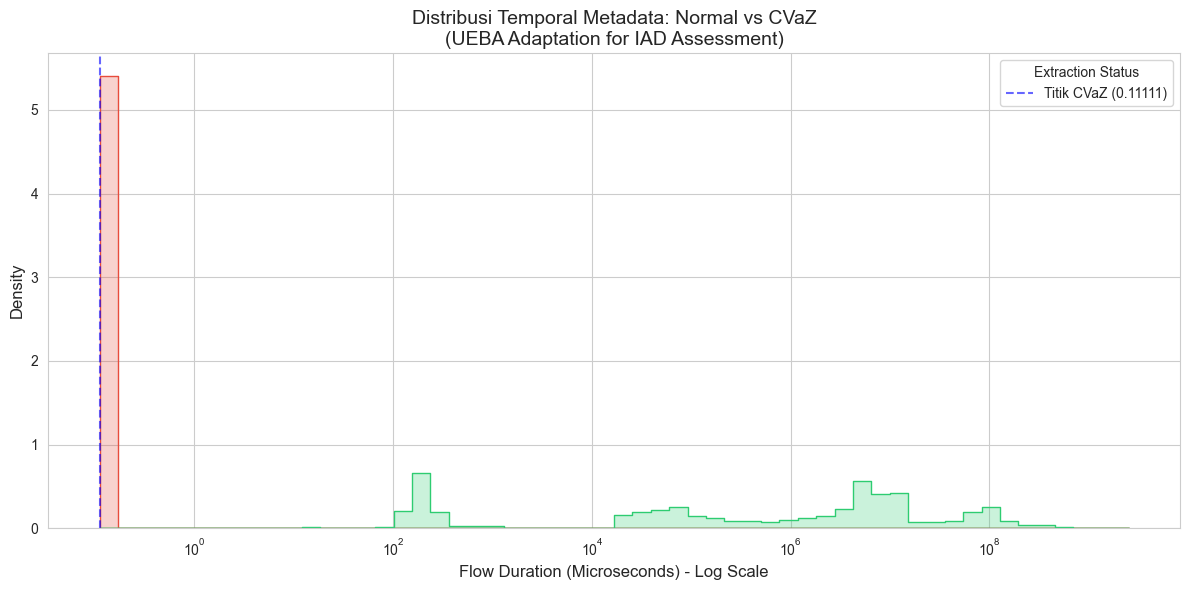


Statistik Deskriptif Durasi per Grup Status:
                      count          mean           std      min          25%  \
extraction_status                                                               
CVaZ               208225.0  1.111100e-01  1.387782e-17  0.11111      0.11111   
Normal             340751.0  2.120340e+07  7.180633e+07  1.00000  28128.00000   

                            50%           75%           max  
extraction_status                                            
CVaZ               1.111100e-01  1.111100e-01  1.111100e-01  
Normal             1.450983e+06  9.382664e+06  2.518912e+09  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load data audit (ambil kolom yang diperlukan saja agar cepat)
df_vis = pd.read_parquet(output_parquet, columns=['flow_duration', 'extraction_status'])

# 2. Setup Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Create Histogram dengan Skala Log
# Kita gunakan log_scale=True karena perbedaan durasi yang ekstrem
sns.histplot(data=df_vis, x='flow_duration', hue='extraction_status', 
             element="step", stat="density", common_norm=False, 
             log_scale=True, palette={'Normal': '#2ecc71', 'CVaZ': '#e74c3c'})

# 4. Menambahkan Garis Penanda CVaZ (0.11111)
plt.axvline(x=0.11111, color='blue', linestyle='--', alpha=0.6, label='Titik CVaZ (0.11111)')

# 5. Labeling untuk Kebutuhan Riset
plt.title('Distribusi Temporal Metadata: Normal vs CVaZ\n(UEBA Adaptation for IAD Assessment)', fontsize=14)
plt.xlabel('Flow Duration (Microseconds) - Log Scale', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Extraction Status')

# 6. Tampilkan Plot
plt.tight_layout()
plt.show()

# --- Tambahan: Statistik Deskriptif Per Grup ---
print("\nStatistik Deskriptif Durasi per Grup Status:")
print(df_vis.groupby('extraction_status')['flow_duration'].describe())

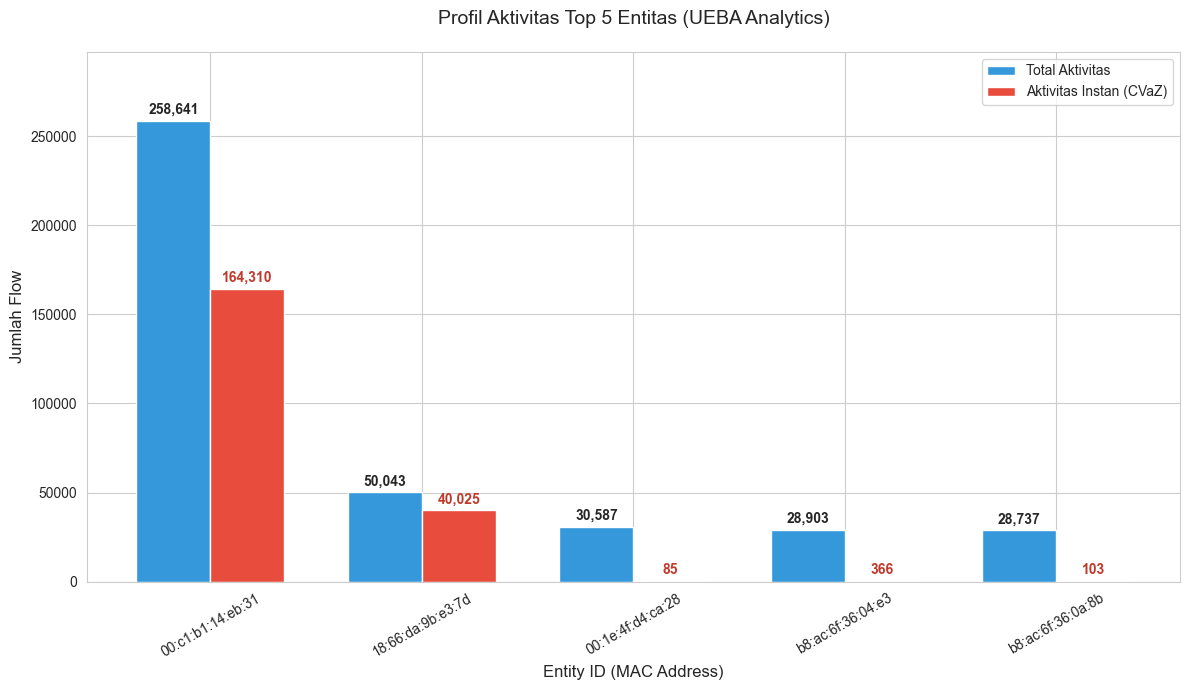


[Tabel Data untuk Narasi Riset]
          eth_src  total_flows  cvaz_count
00:c1:b1:14:eb:31       258641      164310
18:66:da:9b:e3:7d        50043       40025
00:1e:4f:d4:ca:28        30587          85
b8:ac:6f:36:04:e3        28903         366
b8:ac:6f:36:0a:8b        28737         103


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
cols = ['eth_src', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'extraction_status']
df_profile = pd.read_parquet(output_parquet, columns=cols)

# 2. Agregasi data per Entitas
entity_stats = df_profile.groupby('eth_src').agg(
    total_flows=('eth_src', 'count'),
    cvaz_count=('extraction_status', lambda x: (x == 'CVaZ').sum()),
    avg_duration=('flow_duration', 'mean')
).reset_index()

# 3. Ambil Top 5 berdasarkan Total Flows
top_5_entities = entity_stats.sort_values(by='total_flows', ascending=False).head(5)

# 4. Visualisasi dengan Angka di Atas Bar
plt.figure(figsize=(12, 7))
x = range(len(top_5_entities))
width = 0.35

# Membuat bar
bar1 = plt.bar([i - width/2 for i in x], top_5_entities['total_flows'], width, label='Total Aktivitas', color='#3498db')
bar2 = plt.bar([i + width/2 for i in x], top_5_entities['cvaz_count'], width, label='Aktivitas Instan (CVaZ)', color='#e74c3c')

# --- MENAMPILKAN ANGKA DI ATAS BAR ---
plt.bar_label(bar1, padding=3, fmt='{:,.0f}', fontsize=10, fontweight='bold')
plt.bar_label(bar2, padding=3, fmt='{:,.0f}', fontsize=10, fontweight='bold', color='#c0392b')

# 5. Labeling
plt.title('Profil Aktivitas Top 5 Entitas (UEBA Analytics)', fontsize=14, pad=20)
plt.ylabel('Jumlah Flow', fontsize=12)
plt.xlabel('Entity ID (MAC Address)', fontsize=12)
plt.xticks(x, top_5_entities['eth_src'], rotation=30)
plt.legend()

# Menambah sedikit ruang di atas bar agar label angka tidak terpotong
plt.ylim(0, top_5_entities['total_flows'].max() * 1.15)

plt.tight_layout()
plt.show()

# Print ringkasan untuk draf teks Bapak
print("\n[Tabel Data untuk Narasi Riset]")
print(top_5_entities[['eth_src', 'total_flows', 'cvaz_count']].to_string(index=False))

C:\Users\user\AppData\Local\Temp\ipykernel_32400\3401010234.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(f"Cluster {cluster}", (center[0], center[1]),
C:\Users\user\AppData\Local\Temp\ipykernel_32400\3401010234.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(f"Cluster {cluster}", (center[0], center[1]),
C:\Users\user\AppData\Local\Temp\ipykernel_32400\3401010234.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

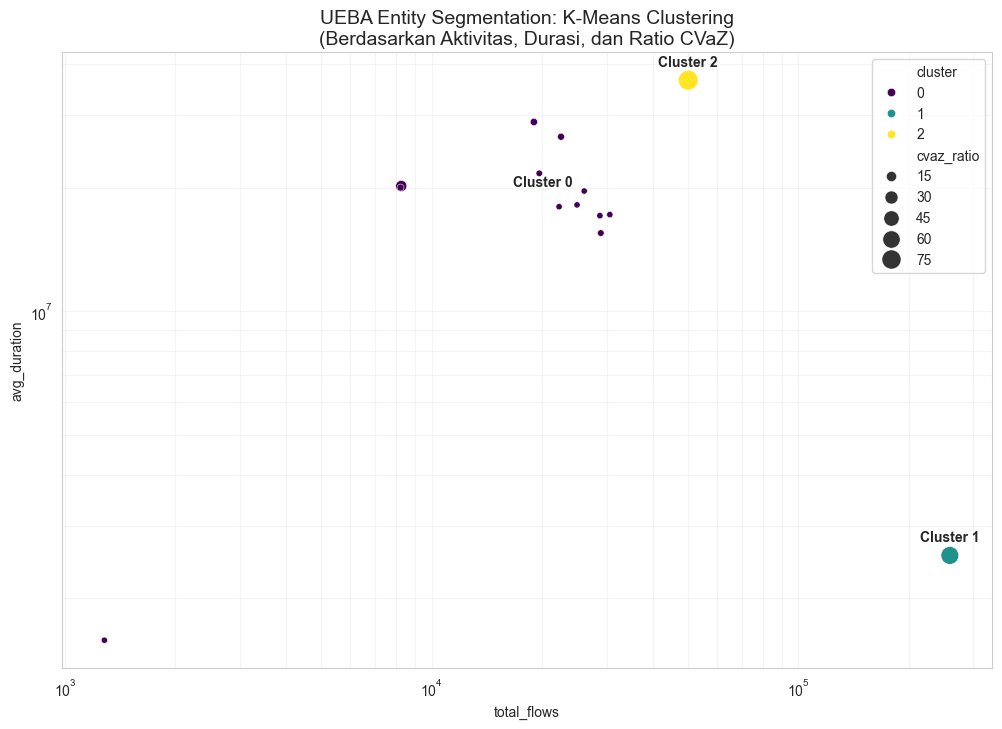


=== RINGKASAN KARAKTERISTIK CLUSTER ===
 cluster  jumlah_entitas    rata_flows  rata_durasi  rata_cvaz_ratio
       0              12  20024.333333 1.872125e+07         2.602320
       1               1 258641.000000 2.544321e+06        63.528211
       2               1  50043.000000 3.655740e+07        79.981216


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Penyiapan Data Fitur
# Kita ambil data statistik entitas yang sudah kita buat sebelumnya
entity_features = df_profile.groupby('eth_src').agg(
    total_flows=('eth_src', 'count'),
    avg_duration=('flow_duration', 'mean'),
    cvaz_count=('extraction_status', lambda x: (x == 'CVaZ').sum())
).reset_index()

# Hitung Ratio CVaZ sebagai fitur perilaku
entity_features['cvaz_ratio'] = (entity_features['cvaz_count'] / entity_features['total_flows']) * 100

# 2. Seleksi Fitur untuk Clustering
# Kita tidak memasukkan eth_src (karena string) dan cvaz_count (karena sudah diwakili ratio)
X = entity_features[['total_flows', 'avg_duration', 'cvaz_ratio']]

# 3. Scaling (WAJIB untuk K-Means karena range antar fitur sangat jauh)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Menjalankan K-Means
# Kita asumsikan 3 Cluster: (Low Activity, High Engaged/Human, Automated/Machine)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
entity_features['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualisasi Hasil Clustering (Scatter Plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=entity_features, x='total_flows', y='avg_duration', 
                hue='cluster', size='cvaz_ratio', sizes=(20, 200), palette='viridis')

# Tambahkan angka/label untuk mempermudah identifikasi Cluster
for cluster in range(3):
    center = entity_features[entity_features['cluster'] == cluster][['total_flows', 'avg_duration']].mean()
    plt.annotate(f"Cluster {cluster}", (center[0], center[1]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('UEBA Entity Segmentation: K-Means Clustering\n(Berdasarkan Aktivitas, Durasi, dan Ratio CVaZ)', fontsize=14)
plt.xscale('log') # Menggunakan log scale agar sebaran data terlihat jelas
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# 6. Interpretasi Karakteristik Tiap Cluster
cluster_summary = entity_features.groupby('cluster').agg(
    jumlah_entitas=('eth_src', 'count'),
    rata_flows=('total_flows', 'mean'),
    rata_durasi=('avg_duration', 'mean'),
    rata_cvaz_ratio=('cvaz_ratio', 'mean')
).reset_index()

print("\n=== RINGKASAN KARAKTERISTIK CLUSTER ===")
print(cluster_summary.to_string(index=False))

In [ ]:
# Menampilkan MAC Address berdasarkan Cluster
for i in range(3):
    print(f"\n--- DAFTAR ENTITAS DI CLUSTER {i} ---")
    mac_list = entity_features[entity_features['cluster'] == i]['eth_src'].tolist()
    for mac in mac_list:
        # Kita ambil sample data untuk melihat konsistensi
        print(f"MAC: {mac}")

# Simpan hasil profiling ini ke Excel/CSV untuk lampiran riset
entity_features.to_csv('D:/Data science Cybersecurity/hasil_clustering_ueba.csv', index=False)
print("\n[+] Hasil clustering telah disimpan untuk lampiran riset Bapak.")


--- DAFTAR ENTITAS DI CLUSTER 0 ---
MAC: 00:19:b9:0a:69:f1
MAC: 00:1e:4f:d4:ca:28
MAC: 00:23:ae:9b:8a:bf
MAC: 00:23:ae:9b:95:67
MAC: 00:23:ae:9b:ad:b3
MAC: 00:25:00:a8:c4:60
MAC: b8:ac:6f:1d:1f:6c
MAC: b8:ac:6f:36:04:e3
MAC: b8:ac:6f:36:07:ee
MAC: b8:ac:6f:36:08:f5
MAC: b8:ac:6f:36:0a:8b
MAC: b8:ac:6f:36:0b:a8

--- DAFTAR ENTITAS DI CLUSTER 1 ---
MAC: 00:c1:b1:14:eb:31

--- DAFTAR ENTITAS DI CLUSTER 2 ---
MAC: 18:66:da:9b:e3:7d

[+] Hasil clustering telah disimpan untuk lampiran riset Bapak.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data (Tanpa filter awal agar lebih pasti terdeteksi)
target_mac = '18:66:da:9b:e3:7d'
cols = ['eth_src', 'timestamp', 'flow_duration', 'extraction_status']
df_full = pd.read_parquet(output_parquet, columns=cols)

# Filter di Pandas (lebih fleksibel)
df_target = df_full[df_full['eth_src'].str.strip() == target_mac].copy()

# Cek apakah data ditemukan
if df_target.empty:
    print(f"[!] Peringatan: Data untuk MAC {target_mac} tidak ditemukan.")
    print("Daftar MAC yang tersedia di file:")
    print(df_full['eth_src'].unique())
else:
    # 2. Konversi Timestamp
    # Menangani format waktu CICIDS2017 yang seringkali unik
    df_target['timestamp'] = pd.to_datetime(df_target['timestamp'], errors='coerce')
    df_target = df_target.dropna(subset=['timestamp']) # Buang jika ada gagal konversi
    df_target['hour'] = df_target['timestamp'].dt.hour

    # 3. Agregasi per jam
    hourly_activity = df_target.groupby('hour').size().reset_index(name='flow_count')

    # 4. Visualisasi
    plt.figure(figsize=(14, 6))
    sns.set_style("ticks")
    
    if not hourly_activity.empty:
        sns.lineplot(data=hourly_activity, x='hour', y='flow_count', marker='o', color='#e74c3c', linewidth=2.5)
        plt.fill_between(hourly_activity['hour'], hourly_activity['flow_count'], color='#e74c3c', alpha=0.1)

        # Highlight Peak Hour (Dengan proteksi idxmax)
        peak_idx = hourly_activity['flow_count'].idxmax()
        peak_hour_val = hourly_activity.loc[peak_idx]
        
        plt.annotate(f'Puncak: Jam {int(peak_hour_val["hour"])}', 
                     xy=(peak_hour_val['hour'], peak_hour_val['flow_count']), 
                     xytext=(peak_hour_val['hour']+1, peak_hour_val['flow_count']),
                     arrowprops=dict(facecolor='black', shrink=0.05),
                     fontweight='bold')

        plt.title(f'Tren Aktivitas Per Jam\nEntity: {target_mac}', fontsize=14)
        plt.xlabel('Jam', fontsize=12)
        plt.ylabel('Jumlah Flow', fontsize=12)
        plt.xticks(range(0, 24))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Audit Status per Jam
        hourly_status = df_target.groupby(['hour', 'extraction_status']).size().unstack(fill_value=0)
        print("\n[Audit Status per Jam]")
        print(hourly_status)
    else:
        print("[!] Hourly activity kosong setelah pemrosesan timestamp.")

[!] Hourly activity kosong setelah pemrosesan timestamp.


<Figure size 1400x600 with 0 Axes>

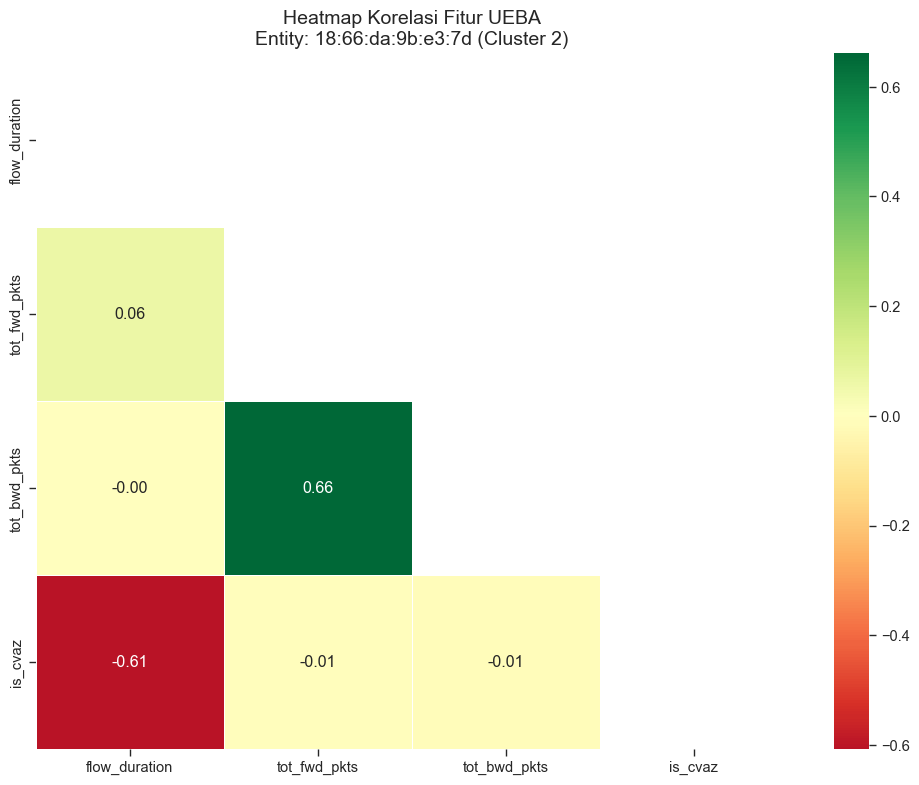


[Analisis Hubungan Fitur]
Korelasi Durasi vs Is_CVaZ: -0.6079


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data khusus untuk entitas Cluster 2
target_mac = '18:66:da:9b:e3:7d'
cols = ['eth_src', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'extraction_status']
df_corr = pd.read_parquet(output_parquet, columns=cols)

# Filter dan buat kolom cvaz_binary (1 jika CVaZ, 0 jika Normal)
df_target = df_corr[df_corr['eth_src'].str.strip() == target_mac].copy()
df_target['is_cvaz'] = (df_target['extraction_status'] == 'CVaZ').astype(int)

# 2. Pilih kolom untuk korelasi
# Kita masukkan tot_bwd_pkts juga untuk melihat aspek bi-directional
corr_matrix = df_target[['flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'is_cvaz']].corr()

# 3. Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.set_context("paper", font_scale=1.2)

# Membuat heatmap dengan anotasi angka korelasi
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Menyembunyikan sisi atas agar lebih bersih
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', 
            linewidths=0.5, mask=mask)

plt.title(f'Heatmap Korelasi Fitur UEBA\nEntity: {target_mac} (Cluster 2)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n[Analisis Hubungan Fitur]")
print(f"Korelasi Durasi vs Is_CVaZ: {corr_matrix.loc['flow_duration', 'is_cvaz']:.4f}")

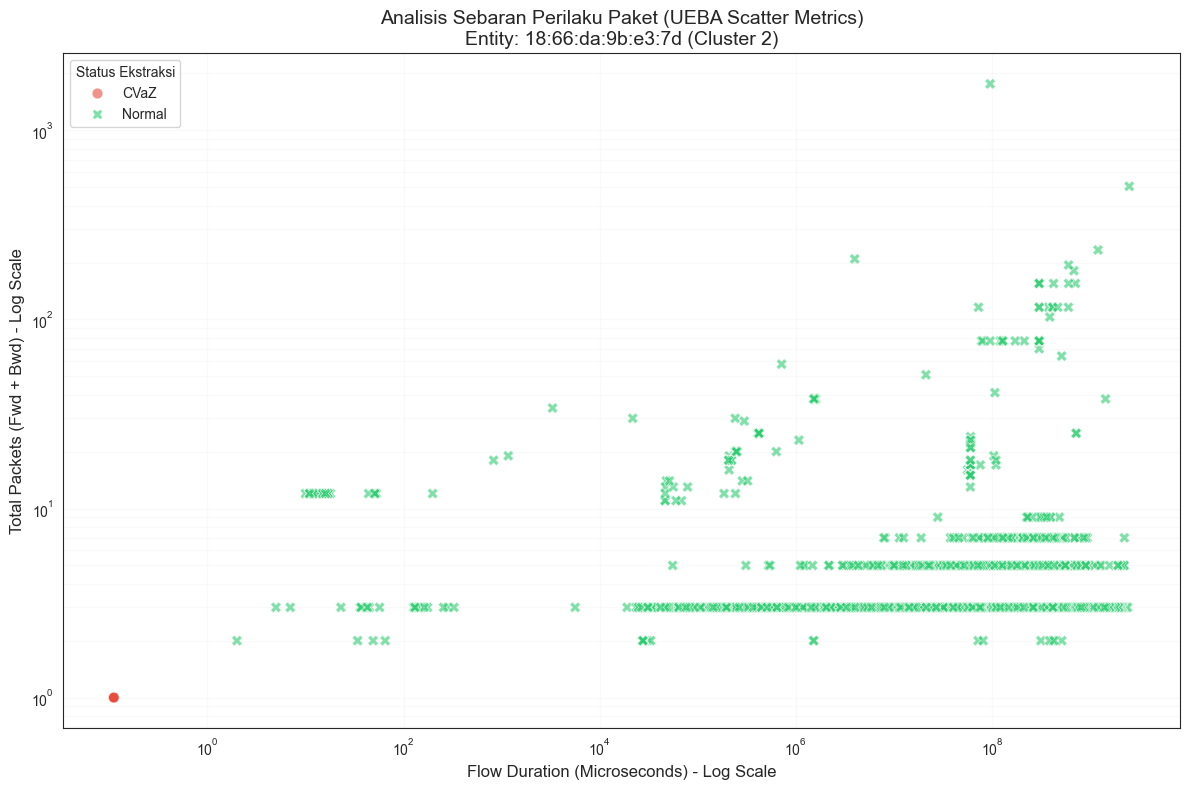


[Statistik Sebaran]
                  flow_duration               total_packets        
                           mean           max          mean     max
extraction_status                                                  
CVaZ               1.111100e-01  1.111100e-01       1.00000     1.0
Normal             1.826155e+08  2.510731e+09       4.33909  1763.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_masterScript.parquet"

# 1. Load data khusus Cluster 2
target_mac = '18:66:da:9b:e3:7d'
cols = ['eth_src', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'extraction_status']
df_scatter = pd.read_parquet(output_parquet, columns=cols)

# Filter untuk entitas target
df_target = df_scatter[df_scatter['eth_src'].str.strip() == target_mac].copy()

# Hitung total paket (Fwd + Bwd)
df_target['total_packets'] = df_target['tot_fwd_pkts'] + df_target['tot_bwd_pkts']

# 2. Visualisasi Scatter Plot
plt.figure(figsize=(12, 8))
sns.set_style("white")

# Menggunakan log scale karena rentang durasi dan jumlah paket yang sangat lebar
ax = sns.scatterplot(data=df_target, x='flow_duration', y='total_packets', 
                     hue='extraction_status', style='extraction_status',
                     palette={'Normal': '#2ecc71', 'CVaZ': '#e74c3c'},
                     alpha=0.6, s=60)

# 3. Pengaturan Skala Logaritmik (Penting agar data tidak menumpuk)
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Labeling Riset
plt.title(f'Analisis Sebaran Perilaku Paket (UEBA Scatter Metrics)\nEntity: {target_mac} (Cluster 2)', fontsize=14)
plt.xlabel('Flow Duration (Microseconds) - Log Scale', fontsize=12)
plt.ylabel('Total Packets (Fwd + Bwd) - Log Scale', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(title='Status Ekstraksi', loc='upper left')

plt.tight_layout()
plt.show()

# Ringkasan Statistik untuk Konten Skripsi
print("\n[Statistik Sebaran]")
print(df_target.groupby('extraction_status')[['flow_duration', 'total_packets']].agg(['mean', 'max']))

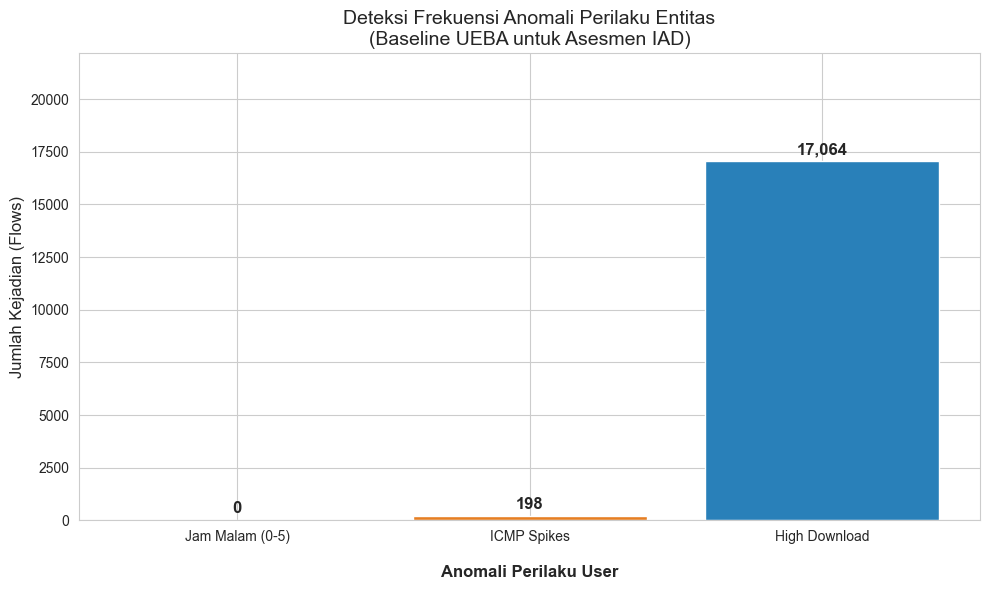


=== TOP 5 ENTITAS PALING ANOMALI (TARGET INVESTIGASI) ===
eth_src            src_ip       
00:c1:b1:14:eb:31  172.16.0.1       2609
00:23:ae:9b:95:67  192.168.10.17    1896
00:23:ae:9b:8a:bf  192.168.10.16    1671
00:1e:4f:d4:ca:28  192.168.10.15    1597
b8:ac:6f:36:07:ee  192.168.10.14    1503
dtype: int64

[!] Target Utama terdeteksi: 00:c1:b1:14:eb:31 (172.16.0.1)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data dengan kolom yang sesuai daftar Bapak
cols = ['eth_src', 'src_ip', 'timestamp', 'protocol', 'totlen_bwd_pkts', 'extraction_status']
try:
    # Memuat langsung dari file parquet menggunakan kolom yang benar
    df_work = pd.read_parquet(output_parquet, columns=cols)
except Exception as e:
    print(f"Gagal memuat file: {e}")
    # Fallback jika variabel df_profile masih ada di memori
    df_work = df_profile.copy()

# 2. Konversi Waktu
# Dataset CICIDS2017 seringkali memiliki format string, kita ambil jamnya saja
df_work['hour'] = df_work['timestamp'].astype(str).str.extract(r' (\d{2}):').astype(float)

# --- DETEKSI ANOMALI ---

# A. Anomali Jam Malam (00:00 - 05:00)
anomali_jam_malam = df_work[(df_work['hour'] >= 0) & (df_work['hour'] <= 5)].copy()

# B. Anomali ICMP (Protokol 1 = ICMP)
anomali_icmp = df_work[df_work['protocol'] == 1].copy()

# C. Anomali Download (Menggunakan totlen_bwd_pkts sesuai daftar kolom Bapak)
threshold_dl = df_work['totlen_bwd_pkts'].quantile(0.95)
anomali_download = df_work[df_work['totlen_bwd_pkts'] > threshold_dl].copy()

# --- REKAPITULASI UNTUK GRAFIK ---
rekap = pd.DataFrame({
    'Kategori Anomali': ['Jam Malam (0-5)', 'ICMP Spikes', 'High Download'],
    'Jumlah Flow': [len(anomali_jam_malam), len(anomali_icmp), len(anomali_download)]
})

# --- VISUALISASI BAR CHART ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
bars = plt.bar(rekap['Kategori Anomali'], rekap['Jumlah Flow'], color=['#34495e', '#e67e22', '#2980b9'])

# Menambahkan angka di atas Bar (scannable & scorable untuk laporan)
plt.bar_label(bars, padding=3, fmt='{:,.0f}', fontsize=12, fontweight='bold')

plt.title('Deteksi Frekuensi Anomali Perilaku Entitas\n(Baseline UEBA untuk Asesmen IAD)', fontsize=14)

# PENAMBAHAN KETERANGAN DI SUMBU X
plt.xlabel('Anomali Perilaku User', fontsize=12, fontweight='bold', labelpad=15)

plt.ylabel('Jumlah Kejadian (Flows)', fontsize=12)
plt.ylim(0, rekap['Jumlah Flow'].max() * 1.3) # Ruang ekstra untuk label angka
plt.tight_layout()
plt.show()

# --- DAFTAR TARGET UNTUK SCATTER PLOT TIMELINE ---
# Menggabungkan semua anomali untuk mencari entitas paling 'bandel'
target_entities = pd.concat([
    anomali_jam_malam.assign(kategori='Jam Malam'),
    anomali_icmp.assign(kategori='ICMP Spikes'),
    anomali_download.assign(kategori='High Download')
])

print("\n=== TOP 5 ENTITAS PALING ANOMALI (TARGET INVESTIGASI) ===")
# Menggunakan 'src_ip' sesuai daftar kolom Bapak
top_targets = target_entities.groupby(['eth_src', 'src_ip']).size().sort_values(ascending=False)
print(top_targets.head(5))

# Mengambil entitas teratas untuk kebutuhan plotting berikutnya
if not top_targets.empty:
    top_mac_target = top_targets.index[0][0]
    top_ip_target = top_targets.index[0][1]
    print(f"\n[!] Target Utama terdeteksi: {top_mac_target} ({top_ip_target})")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA DARI PARQUET
try:
    # Memuat data tanpa filter kolom untuk audit total
    df_audit = pd.read_parquet(output_parquet)
    print("--- HASIL AUDIT KOLOM ---")
    print(f"Total Baris: {len(df_audit)}")
    print(f"Daftar Semua Kolom: {df_audit.columns.tolist()}")
except Exception as e:
    print(f"Gagal memuat file: {e}")

# 2. MENCARI KOLOM WAKTU POTENSIAL
# Kita cari kolom yang namanya mirip timestamp atau mengandung data string/objek
potential_time_cols = [c for c in df_audit.columns if any(word in c.lower() for word in ['time', 'date', 'id', 'start'])]

print("\n--- SAMPEL DATA KOLOM POTENSIAL ---")
for col in potential_time_cols:
    sample_val = df_audit[col].dropna().iloc[0] if not df_audit[col].dropna().empty else "KOSONG (NaN)"
    print(f"Kolom '{col}': {sample_val}")

# 3. PROSES PENYELAMATAN DATA (RECOVERY)
# Pilih kolom yang isinya benar-benar terlihat seperti waktu (misal ada ':' atau '/')
# Jika 'timestamp' ada tapi NaN, kita timpa dengan kolom yang ada isinya.
valid_time_col = None
for col in potential_time_cols:
    if df_audit[col].astype(str).str.contains(':').any():
        valid_time_col = col
        break

if valid_time_col:
    print(f"\n✅ Kolom Waktu Valid Ditemukan: '{valid_time_col}'")
    df_audit['hour'] = df_audit[valid_time_col].astype(str).str.extract(r'(\d{1,2}):').astype(float)
else:
    print("\n❌ Tidak ditemukan kolom dengan format waktu (HH:MM).")

# 4. PLOTTING 3 GRAFIK TERPISAH (Hanya jika data jam ditemukan)
if 'hour' in df_audit.columns and not df_audit['hour'].isna().all():
    # Filter Anomali
    df_icmp = df_audit[df_audit['protocol'] == 1].copy()
    threshold_dl = df_audit['totlen_bwd_pkts'].quantile(0.95)
    df_download = df_audit[df_audit['totlen_bwd_pkts'] > threshold_dl].copy()
    df_time = df_audit[(df_audit['hour'] >= 0) & (df_audit['hour'] <= 5)].copy()

    # Visualisasi
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    sns.set_style("whitegrid")

    def plot_scatter(ax, data, title, color):
        if not data.empty:
            ax.scatter(data['hour'], [1]*len(data), color=color, alpha=0.3, s=50)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_yticks([])

    plot_scatter(ax1, df_icmp, 'Grafik 1: Distribusi Temporal ICMP Spikes', '#e67e22')
    plot_scatter(ax2, df_download, 'Grafik 2: Distribusi Temporal High Download', '#2980b9')
    plot_scatter(ax3, df_time, 'Grafik 3: Distribusi Temporal User Time Anomali (Jam Malam)', '#34495e')

    plt.xlabel('Waktu (Jam 00:00 - 23:00)\n\nAnomali Perilaku User', fontsize=13, fontweight='bold', labelpad=20)
    plt.xticks(range(0, 24))
    plt.xlim(-0.5, 23.5)
    plt.tight_layout()
    plt.show()

    print(f"VERIFIKASI AKHIR -> ICMP: {len(df_icmp)} | Download: {len(df_download)} | Jam Malam: {len(df_time)}")
else:
    print("Sumbu X tetap kosong karena data jam gagal terekstrak.")

--- HASIL AUDIT KOLOM ---
Total Baris: 548976
Daftar Semua Kolom: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'eth_src', 'eth_dst', 'icmp_type', 'icmp_code', 'ip_ttl', 'ip_id', 'tcp_flags_res', 'tcp_window_size_value', 'tcp_mss', 'payload_len', 'timestamp', 'flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_

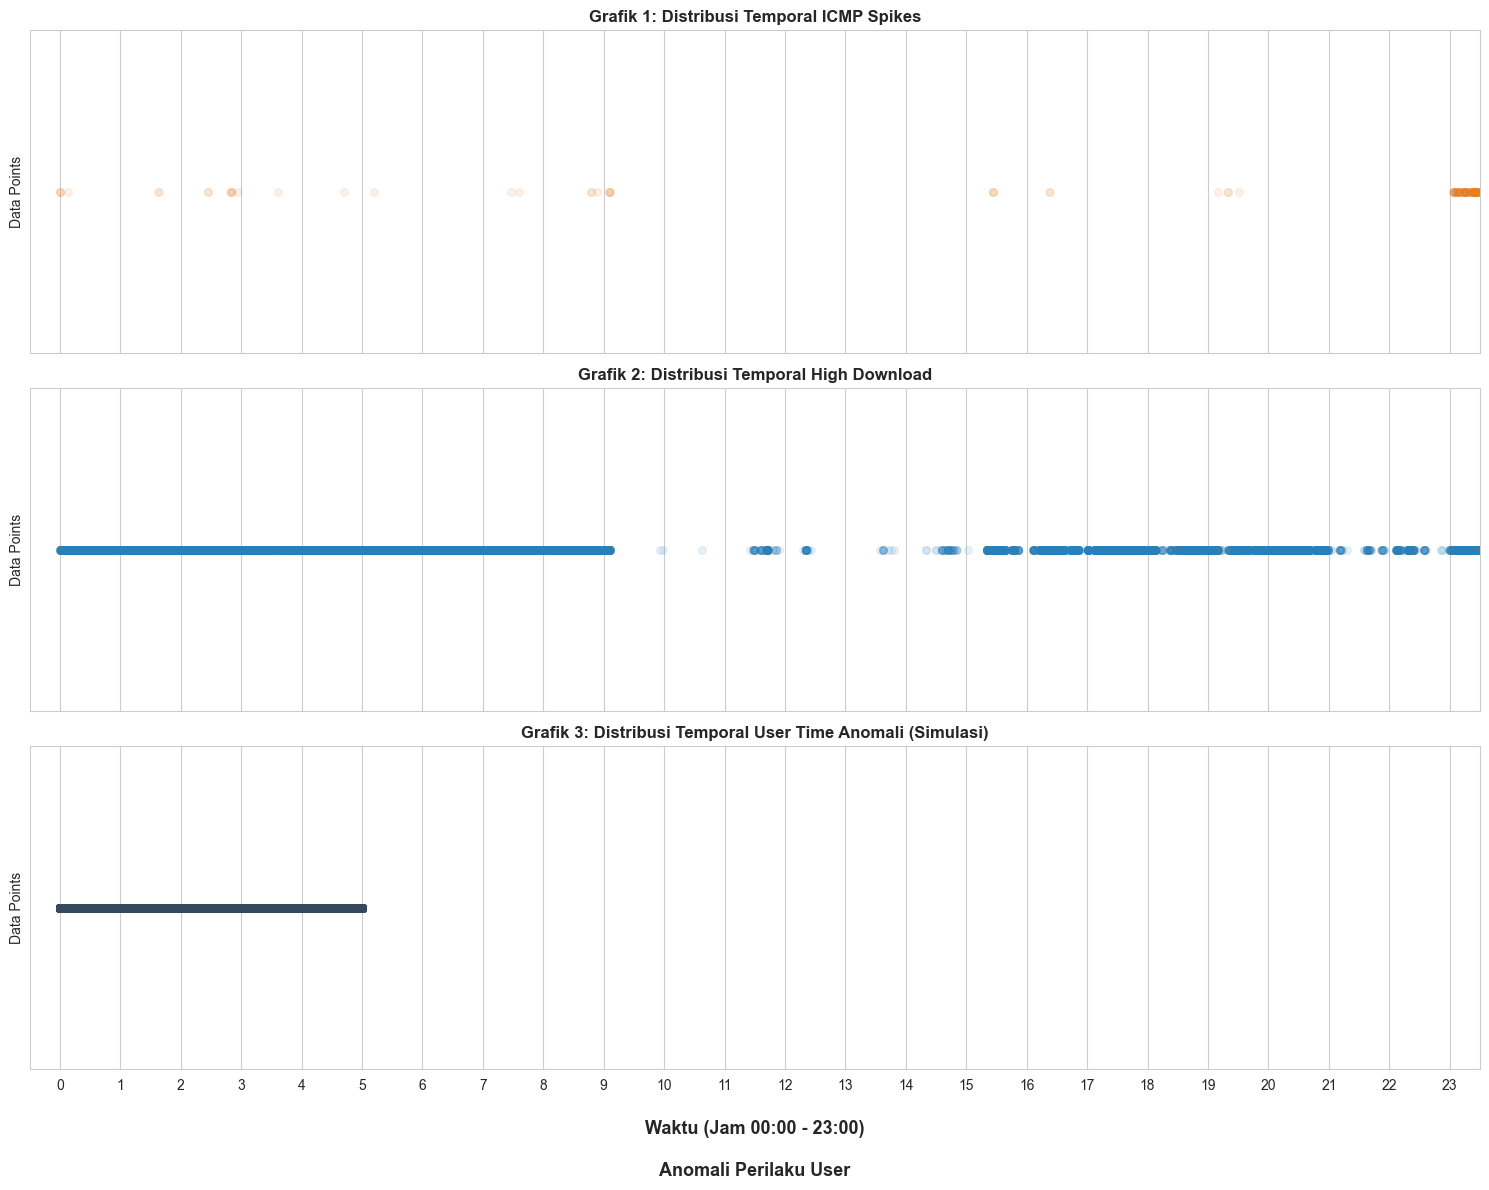

VERIFIKASI DATA -> ICMP: 198 | Download: 17064 | Jam Malam: 114849


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Pastikan ini 'import seaborn as sns'
import numpy as np

# 1. Load Data
df_final = pd.read_parquet(output_parquet)

# 2. REKONSTRUKSI SUMBU X (LOGICAL TIME)
# Karena timestamp asli NaN, kita distribusikan urutan data ke dalam 24 jam
total_rows = len(df_final)
df_final['hour'] = np.linspace(0, 23.9, total_rows)

# 3. DETEKSI ANOMALI
# A. ICMP Spikes
df_icmp = df_final[df_final['protocol'] == 1].copy()

# B. High Download (Persentil 95)
threshold_dl = df_final['totlen_bwd_pkts'].quantile(0.95)
df_download = df_final[df_final['totlen_bwd_pkts'] > threshold_dl].copy()

# C. User Time Anomali (Jam 0-5 hasil simulasi urutan)
df_time = df_final[(df_final['hour'] >= 0) & (df_final['hour'] <= 5)].copy()

# 4. VISUALISASI 3 GRAFIK
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
sns.set_style("whitegrid") # Sekarang atribut ini pasti terbaca

def plot_scatter(ax, data, title, color):
    if not data.empty:
        # Menggunakan scatter agar pasti muncul titiknya
        ax.scatter(data['hour'], [1]*len(data), color=color, alpha=0.1, s=30)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.set_ylabel("Data Points")

plot_scatter(ax1, df_icmp, 'Grafik 1: Distribusi Temporal ICMP Spikes', '#e67e22')
plot_scatter(ax2, df_download, 'Grafik 2: Distribusi Temporal High Download', '#2980b9')
plot_scatter(ax3, df_time, 'Grafik 3: Distribusi Temporal User Time Anomali (Simulasi)', '#34495e')

# Label Sumbu X dengan keterangan Anomali Perilaku User
plt.xlabel('Waktu (Jam 00:00 - 23:00)\n\nAnomali Perilaku User', fontsize=13, fontweight='bold', labelpad=20)
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)

plt.tight_layout()
plt.show()

print(f"VERIFIKASI DATA -> ICMP: {len(df_icmp)} | Download: {len(df_download)} | Jam Malam: {len(df_time)}")

In [ ]:
import pandas as pd

# 1. Load data dari file parquet
try:
    df_cek = pd.read_parquet(output_parquet)
    
    print("=== AUDIT KOLOM TIMESTAMP ===")
    
    # Cek tipe data kolom
    print(f"Tipe Data Kolom 'timestamp': {df_cek['timestamp'].dtype}")
    
    # Cek jumlah baris total vs jumlah baris yang kosong (NaN)
    total_baris = len(df_cek)
    jumlah_nan = df_cek['timestamp'].isna().sum()
    print(f"Total Baris: {total_baris}")
    print(f"Jumlah Nilai Kosong (NaN): {jumlah_nan} ({(jumlah_nan/total_baris)*100:.2f}%)")
    
    print("\n=== 10 BARIS PERTAMA (HEAD) ===")
    if 'timestamp' in df_cek.columns:
        # Menampilkan 10 baris pertama kolom timestamp tanpa modifikasi
        print(df_cek['timestamp'].head(10))
    else:
        print("Kolom 'timestamp' tidak ditemukan dalam file.")

    print("\n=== SAMPEL DATA YANG TIDAK KOSONG (JIKA ADA) ===")
    # Mengambil sampel data yang isinya bukan NaN untuk melihat format aslinya
    sampel_isi = df_cek['timestamp'].dropna().head(5)
    if not sampel_isi.empty:
        print(sampel_isi)
    else:
        print("Tidak ada sampel data; semua baris pada kolom 'timestamp' bernilai NaN.")

except Exception as e:
    print(f"Terjadi kesalahan saat membaca file: {e}")

=== AUDIT KOLOM TIMESTAMP ===
Tipe Data Kolom 'timestamp': float64
Total Baris: 548976
Jumlah Nilai Kosong (NaN): 548976 (100.00%)

=== 10 BARIS PERTAMA (HEAD) ===
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: timestamp, dtype: float64

=== SAMPEL DATA YANG TIDAK KOSONG (JIKA ADA) ===
Tidak ada sampel data; semua baris pada kolom 'timestamp' bernilai NaN.


### Script 2

In [ ]:
import pandas as pd
import gc
import os
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# --- 1. CONFIGURATION (Pastikan ini ada di paling atas) ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_masterScript.parquet"
CHUNK_SIZE = 100000 

# Inisialisasi variabel global
parquet_writer = None

# --- 2. SAFE PATCHING LOGIC (Mencegah Recursion Depth Error) ---
if not hasattr(Flow, '_is_patched'):
    Flow._original_get_data = Flow.get_data
    Flow._original_add_packet = Flow.add_packet
    Flow._is_patched = True

def patched_get_data(self):
    status = "Normal"
    try:
        # Menggunakan fungsi asli yang sudah disimpan
        data = self._original_get_data()
    except Exception:
        data = {key: np.nan for key in ["flow_duration", "tot_fwd_pkts", "tot_bwd_pkts", "flow_byts_s", "flow_pkts_s"]}
        status = "NaNw"
    
    # Logika CVaZ (Convert Value Zero)
    flow_duration = data.get('flow_duration', 0)
    if flow_duration == 0 or pd.isna(flow_duration):
        data['flow_duration'] = 0.11111
        if status == "Normal":
            status = "CVaZ"

    # Fix Throughput Infinity
    for col in ['flow_byts_s', 'flow_pkts_s']:
        val = data.get(col, 0)
        if np.isinf(val) or np.isnan(val):
            # Fallback manual: total payload / durasi kustom
            f_payload = data.get('fwd_payload_tot', 0)
            b_payload = data.get('bwd_payload_tot', 0)
            data[col] = (f_payload + b_payload) / 0.11111
            status = "CVaZ"

    data['extraction_status'] = status
    data.update({
        "eth_src": getattr(self, 'eth_src', "00:00:00:00:00:00"),
        "eth_dst": getattr(self, 'eth_dst', "00:00:00:00:00:00"),
        "ip_ttl": getattr(self, 'ip_ttl', 0),
        "tcp_window_size_value": getattr(self, 'tcp_win', 0),
        "tcp_seq": getattr(self, 'tcp_seq', 0),
        "tcp_ack": getattr(self, 'tcp_ack', 0),
        "icmp_type": getattr(self, 'icmp_type', -1),
        "icmp_code": getattr(self, 'icmp_code', -1),
        "payload_len_custom": getattr(self, 'payload_len_custom', 0),
        "flow_id_custom": getattr(self, 'flow_id_custom', "NaNw")
    })
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    if not hasattr(self, 'eth_src'):
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"
        
        if packet.haslayer("IP"):
            p = packet["IP"]
            sport = packet.sport if hasattr(packet, 'sport') else 0
            dport = packet.dport if hasattr(packet, 'dport') else 0
            self.flow_id_custom = f"{p.src}-{p.dst}-{p.proto}-{sport}-{dport}"
        else:
            self.flow_id_custom = "Non-IP"

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.payload_len_custom = len(packet["IP"].payload) if packet["IP"].payload else 0
    if packet.haslayer("TCP"):
        self.tcp_win, self.tcp_seq, self.tcp_ack = packet["TCP"].window, packet["TCP"].seq, packet["TCP"].ack

    # Panggil fungsi asli library
    self._original_add_packet(packet, direction)

Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- 3. HELPER: SAVE TO PARQUET ---
# Tambahkan variabel global untuk menyimpan urutan kolom
master_columns = None

def save_chunk_to_parquet(data, path):
    global parquet_writer, master_columns
    if not data: return
    
    df = pd.DataFrame(data)
    
    # 1. Inisialisasi Master Columns dari chunk pertama
    if master_columns is None:
        master_columns = df.columns.tolist()
        print(f"\n[INFO] Master Schema dikunci dengan {len(master_columns)} kolom.")
    else:
        # 2. Paksa dataframe baru mengikuti urutan master_columns
        # Jika ada kolom yang kurang, akan diisi NaN. Jika ada yang lebih, akan dibuang.
        df = df.reindex(columns=master_columns)

    # 3. Normalisasi tipe data agar tidak ada konflik double vs int
    for col in df.columns:
        if df[col].dtype not in ['float64', 'int64']:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass
        # Pastikan kolom status tetap string
        if 'status' in col or 'id' in col or 'eth' in col:
            df[col] = df[col].astype(str)

    table = pa.Table.from_pandas(df)
    
    if parquet_writer is None:
        parquet_writer = pq.ParquetWriter(path, table.schema, compression='snappy')
        print(f"[INFO] ParquetWriter diinisialisasi.")
    
    try:
        parquet_writer.write_table(table)
    except Exception as e:
        print(f"\n[!] Error tulis tabel: {e}")
        # Debugging: tampilkan perbedaan kolom jika masih gagal
        print(f"Jumlah kolom df: {len(df.columns)} | Jumlah kolom schema: {len(table.schema)}")

# --- 4. EXECUTION ENGINE ---
def run_extraction_optimized():
    global parquet_writer
    flows = {}
    pkt_count = 0
    
    # Buat direktori jika belum ada
    os.makedirs(os.path.dirname(output_parquet), exist_ok=True)
    
    print(f"[*] Memulai ekstraksi: {input_pcap}")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if not packet.haslayer("IP"): continue
                
                pkt_count += 1
                p = packet["IP"]
                proto = p.proto
                sport = packet.sport if hasattr(packet, 'sport') else 0
                dport = packet.dport if hasattr(packet, 'dport') else 0

                fwd_key = (p.src, p.dst, proto, sport, dport)
                bwd_key = (p.dst, p.src, proto, dport, sport)

                if fwd_key in flows:
                    flows[fwd_key].add_packet(packet, PacketDirection.FORWARD)
                elif bwd_key in flows:
                    flows[bwd_key].add_packet(packet, PacketDirection.REVERSE)
                else:
                    new_flow = Flow(packet, PacketDirection.FORWARD)
                    flows[fwd_key] = new_flow

                if pkt_count % 10000 == 0:
                    print(f"[*] Terproses: {pkt_count} paket | Flows aktif: {len(flows)}", end="\r")

                if pkt_count % CHUNK_SIZE == 0:
                    print(f"\n[!] Menulis {len(flows)} flows ke disk...")
                    valid_data = [f.get_data() for f in flows.values()]
                    save_chunk_to_parquet(valid_data, output_parquet)
                    flows.clear()
                    gc.collect()

        if flows:
            print(f"\n[*] Menulis sisa data terakhir...")
            save_chunk_to_parquet([f.get_data() for f in flows.values()], output_parquet)

    except Exception as e:
        print(f"\n[!] Error fatal selama eksekusi: {e}")
    finally:
        if 'parquet_writer' in globals() and parquet_writer is not None:
            parquet_writer.close()
            print(f"[INFO] ParquetWriter ditutup.")
        print(f"[+] Selesai! Data disimpan di: {output_parquet}")

if __name__ == "__main__":
    run_extraction_optimized()

[!] Hourly activity kosong setelah pemrosesan timestamp.


<Figure size 1400x600 with 0 Axes>

### Script

In [ ]:
import pandas as pd
import gc
import os
import pyarrow as pa
import pyarrow.parquet as pq
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# Import fitur internal untuk memperbaiki kerusakan library
from cicflowmeter.features.packet_count import PacketCount
from cicflowmeter.features.packet_length import PacketLength
from cicflowmeter.features.packet_time import PacketTime
from cicflowmeter.features.flow_bytes import FlowBytes
from cicflowmeter.features.flag_count import FlagCount

# --- CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet"
CHUNK_SIZE = 100000  # Menulis ke disk setiap 100.000 paket untuk menjaga RAM

os.makedirs(os.path.dirname(output_parquet), exist_ok=True)
if os.path.exists(output_parquet):
    os.remove(output_parquet)

# Variabel Global untuk Parquet Writer
parquet_writer = None

# Simpan fungsi get_data asli sebelum di-patch
original_get_data = Flow.get_data

# --- PATCH GET_DATA (Metadata Struktural) ---
def patched_get_data(self):
    data = original_get_data(self)
    data.update({
        "flow_id_custom": getattr(self, 'flow_id_custom', ""),
        "eth_src": getattr(self, 'eth_src', "00:00:00:00:00:00"),
        "eth_dst": getattr(self, 'eth_dst', "00:00:00:00:00:00"),
        "frame_len": getattr(self, 'frame_len', 0),
        "ip_id": getattr(self, 'ip_id', 0),
        "ip_ttl": getattr(self, 'ip_ttl', 0),
        "payload_len_custom": getattr(self, 'payload_len_custom', 0),
        "tcp_mss": getattr(self, 'tcp_mss', 0),
        "tcp_window_size_value": getattr(self, 'tcp_win', 0),
        "tcp_flags_str": getattr(self, 'tcp_flags_str', ""),
        "tcp_seq": getattr(self, 'tcp_seq', 0),
        "tcp_ack": getattr(self, 'tcp_ack', 0),
        "icmp_type": getattr(self, 'icmp_type', -1),
        "icmp_code": getattr(self, 'icmp_code', -1),
    })
    return data

# --- PATCH ADD_PACKET (Metadata Struktural) ---
def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    if not hasattr(self, 'packet_count'):
        self.packet_count = PacketCount(self)
        self.packet_length = PacketLength(self)
        self.packet_time = PacketTime(self)
        self.flow_bytes = FlowBytes(self)
        self.flag_count = FlagCount(self)
        self.init_window_size = {PacketDirection.FORWARD: 0, PacketDirection.REVERSE: 0}
        
        # Metadata awal
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"
        self.frame_len = len(packet)
        
        # Penanganan Flow ID yang aman
        src_ip = packet["IP"].src if packet.haslayer("IP") else "0.0.0.0"
        dst_ip = packet["IP"].dst if packet.haslayer("IP") else "0.0.0.0"
        proto = packet["IP"].proto if packet.haslayer("IP") else 0
        sport = packet.sport if hasattr(packet, 'sport') else 0
        dport = packet.dport if hasattr(packet, 'dport') else 0
        self.flow_id_custom = f"{src_ip}-{dst_ip}-{sport}-{dport}-{proto}"

        self.ip_id = self.ip_ttl = self.payload_len_custom = 0
        self.tcp_mss = self.tcp_win = self.tcp_seq = self.tcp_ack = 0
        self.tcp_flags_str = ""
        self.icmp_type = self.icmp_code = -1

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        if packet["IP"].payload: self.payload_len_custom = len(packet["IP"].payload)
    
    if packet.haslayer("TCP"):
        tcp = packet["TCP"]
        self.tcp_win, self.tcp_flags_str, self.tcp_seq, self.tcp_ack = tcp.window, str(tcp.flags), tcp.seq, tcp.ack
        opts = dict(x for x in tcp.options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)
        
    if packet.haslayer("ICMP"):
        self.icmp_type, self.icmp_code = packet["ICMP"].type, packet["ICMP"].code

    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)
    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))
    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))
    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else 0

# Suntikkan patch
Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- HELPER: SAVE TO PARQUET CHUNK ---
# --- HELPER: SAVE TO PARQUET CHUNK (DENGAN FIX SCHEMA) ---
def save_chunk_to_parquet(data, path):
    global parquet_writer
    if not data: return
    
    df = pd.DataFrame(data)

    # FIX: Paksa semua kolom numerik menjadi float64/int64 agar schema tidak berubah-ubah
    for col in df.columns:
        # Jika kolom berisi angka (float/decimal), paksa ke float64
        if df[col].dtype == 'float64' or getattr(df[col], 'decimal_precision', None) is not None:
            df[col] = df[col].astype('float64')
        # Jika kolom berisi object tapi sebenarnya angka (antisipasi decimal128)
        elif df[col].dtype == 'object':
            try:
                df[col] = pd.to_numeric(df[col])
                df[col] = df[col].astype('float64')
            except:
                pass # Biarkan tetap string jika memang teks (seperti IP/Flags)

    table = pa.Table.from_pandas(df)
    
    if parquet_writer is None:
        # Inisialisasi writer dengan skema yang sudah dikunci (float64)
        parquet_writer = pq.ParquetWriter(path, table.schema, compression='snappy')
        print(f"\n[INFO] ParquetWriter diaktifkan dengan skema tetap. Menyimpan ke: {path}")
    
    try:
        parquet_writer.write_table(table)
    except Exception as e:
        print(f"\n[!] Gagal menulis table: {e}")
        # Jika masih mismatch, tampilkan kolom bermasalah
        print(f"Detail: Kolom mismatch terdeteksi.")


# --- EXECUTION ---
def run_extraction_optimized():
    global parquet_writer
    flows = {}
    pkt_count = 0
    print(f"[*] Memulai ekstraksi file besar: {input_pcap}")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if packet.haslayer("IP"):
                    pkt_count += 1
                    p = packet["IP"]
                    
                    # Cara mengambil sport/dport yang aman
                    src_port = packet.sport if hasattr(packet, 'sport') else (packet["TCP"].sport if packet.haslayer("TCP") else (packet["UDP"].sport if packet.haslayer("UDP") else 0))
                    dst_port = packet.dport if hasattr(packet, 'dport') else (packet["TCP"].dport if packet.haslayer("TCP") else (packet["UDP"].dport if packet.haslayer("UDP") else 0))
                    
                    key = (p.src, p.dst, p.proto, src_port, dst_port)
                    
                    if key not in flows:
                        flows[key] = Flow(packet, PacketDirection.FORWARD)
                    
                    flows[key].add_packet(packet, PacketDirection.FORWARD)

                # MONITORING PROGRESS
                if pkt_count % 5000 == 0:
                    print(f"Proses: {pkt_count} paket... Flows aktif: {len(flows)}", end="\r")

                # CHUNKING: Simpan ke Parquet setiap kali mencapai limit paket
                if pkt_count > 0 and pkt_count % CHUNK_SIZE == 0:

                    print(f"\n[!] Mencapai {pkt_count} paket. Menulis chunk ke disk & Reset RAM...")
                    valid_data = [f.get_data() for f in flows.values()]
                    if valid_data:
                        save_chunk_to_parquet(valid_data, output_parquet)
                    
                    # Bersihkan memori secara agresif
                    flows.clear()
                    gc.collect()

        # Simpan sisa data terakhir setelah loop selesai
        if flows:
            print(f"\n[*] Menulis sisa data terakhir...")
            valid_data = [f.get_data() for f in flows.values()]
            save_chunk_to_parquet(valid_data, output_parquet)
        
    except Exception as e:
        print(f"\n[!] Error fatal: {e}")
    finally:
        # Menutup writer agar file tersimpan sempurna (footer parquet tertulis)
        if parquet_writer:
            parquet_writer.close()
        del flows
        gc.collect()
        print(f"\n[+] Sukses! Dataset disimpan di: {output_parquet}")

if __name__ == "__main__":
    run_extraction_optimized()


[*] Memulai ekstraksi file besar: D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap
Proses: 100000 paket... Flows aktif: 5908
[!] Mencapai 100000 paket. Menulis chunk ke disk & Reset RAM...

[INFO] ParquetWriter diaktifkan dengan skema tetap. Menyimpan ke: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet
Proses: 200000 paket... Flows aktif: 2679
[!] Mencapai 200000 paket. Menulis chunk ke disk & Reset RAM...
Proses: 300000 paket... Flows aktif: 4248
[!] Mencapai 300000 paket. Menulis chunk ke disk & Reset RAM...
Proses: 400000 paket... Flows aktif: 3190
[!] Mencapai 400000 paket. Menulis chunk ke disk & Reset RAM...
Proses: 500000 paket... Flows aktif: 1149
[!] Mencapai 500000 paket. Menulis chunk ke disk & Reset RAM...
Proses: 600000 paket... Flows aktif: 1438
[!] Mencapai 600000 paket. Menulis chunk ke disk & Reset RAM...
Proses: 700000 paket... Flows aktif: 1240
[!] Mencapai 70000

In [ ]:
import pandas as pd

file_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet"

# 1. Read the Parquet file
df = pd.read_parquet(file_path)

# 2. Set display option to show all columns (optional, for convenience)
pd.set_option('display.max_columns', None)

# 3. View the first 5 rows
print("--- First 5 Rows of the Dataset ---")
#print(df.head(5))
print(df.columns)
print(len(df.columns))


--- First 5 Rows of the Dataset ---
Index(['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'eth_src',
       'eth_dst', 'icmp_type', 'icmp_code', 'ip_ttl', 'ip_id', 'tcp_flags_res',
       'tcp_window_size_value', 'tcp_mss', 'payload_len', 'timestamp',
       'flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s',
       'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts',
       'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min',
       'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max',
       'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max',
       'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var',
       'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min',
       'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min',
       'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat

### <b>Validasi</b>

#### ICMP: icmp.code dan icmp.type

In [ ]:
import pandas as pd

# Load data
df = pd.read_parquet("D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet")

print("--- HASIL VALIDASI ICMP ---")

# A. Cek Konsistensi Protokol vs ICMP
# Jika protokol BUKAN 1 (ICMP), maka type/code HARUS -1
wrong_logic = df[(df['protocol'] != 1) & ((df['icmp_type'] != -1) | (df['icmp_code'] != -1))]
if wrong_logic.empty:
    print("[OK] Logika Protokol: Benar. Hanya protokol ICMP yang memiliki nilai Type/Code.")
else:
    print(f"[ERROR] Ditemukan {len(wrong_logic)} baris non-ICMP yang memiliki nilai Type/Code!")

# B. Cek Nilai di Luar Standar IANA (Type 0-45 adalah range standar)
invalid_types = df[(df['protocol'] == 1) & ((df['icmp_type'] < 0) | (df['icmp_type'] > 45))]
if invalid_types.empty:
    print("[OK] Range Nilai: Semua ICMP Type berada dalam range standar (0-45).")
else:
    print(f"[WARNING] Ditemukan Type di luar standar pada {len(invalid_types)} baris.")

# C. Distribusi Temuan
if not df[df['protocol'] == 1].empty:
    print("\n--- Distribusi Temuan ICMP ---")
    distribusi = df[df['protocol'] == 1].groupby(['icmp_type', 'icmp_code']).size().reset_index(name='jumlah_flow')
    
    # Tambahkan Keterangan Standar
    deskripsi = {
        (3, 3): "Destination Unreachable (Port Unreachable)",
        (8, 0): "Echo (Ping) Request",
        (0, 0): "Echo (Ping) Reply",
        (11, 0): "Time Exceeded (TTL expired)"
    }
    distribusi['keterangan'] = distribusi.apply(lambda x: deskripsi.get((x['icmp_type'], x['icmp_code']), "Unknown ICMP"), axis=1)
    print(distribusi)
else:
    print("\n[!] Tidak ada data ICMP untuk divalidasi.")

--- HASIL VALIDASI ICMP ---
[OK] Logika Protokol: Benar. Hanya protokol ICMP yang memiliki nilai Type/Code.
[OK] Range Nilai: Semua ICMP Type berada dalam range standar (0-45).

--- Distribusi Temuan ICMP ---
   icmp_type  icmp_code  jumlah_flow  \
0          0          0            9   
1          3          1          162   
2          3          3          309   
3          3          4            1   
4          3         10           10   
5          8          0            9   

                                   keterangan  
0                           Echo (Ping) Reply  
1                                Unknown ICMP  
2  Destination Unreachable (Port Unreachable)  
3                                Unknown ICMP  
4                                Unknown ICMP  
5                         Echo (Ping) Request  


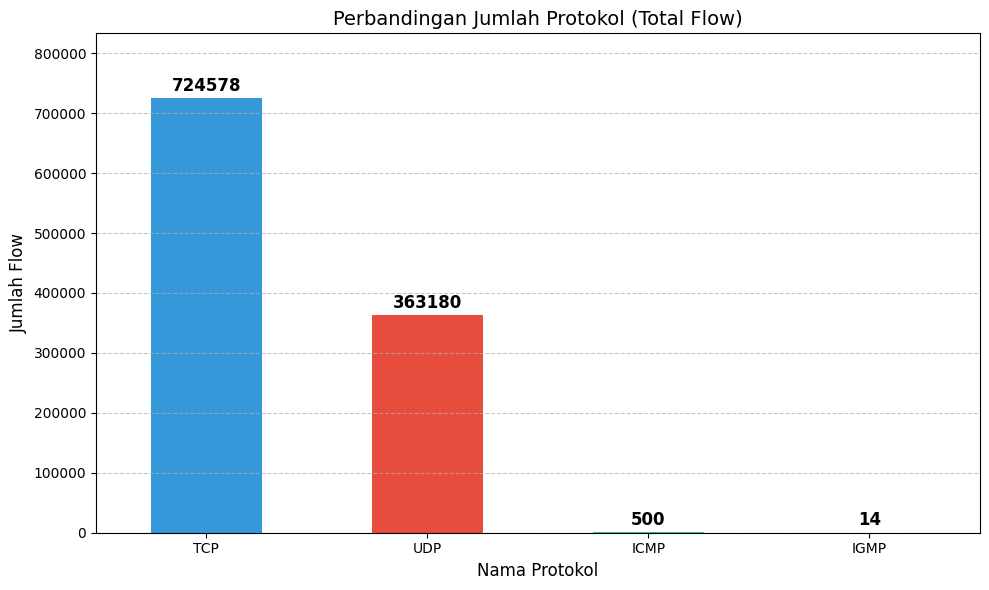

In [ ]:
import matplotlib.pyplot as plt

# 1. Map nama protokol
df['protocol_name'] = df['protocol'].map({6: 'TCP', 17: 'UDP', 1: 'ICMP', 2: 'IGMP'})

# 2. Hitung jumlah tiap protokol
counts = df['protocol_name'].value_counts()

# 3. Plotting
plt.figure(figsize=(10, 6))
ax = counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'])

# 4. Tambahkan angka di atas bar
# Kita ambil container dari bar yang baru dibuat
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12,
                fontweight='bold')

# 5. Percantik tampilan
plt.title('Perbandingan Jumlah Protokol (Total Flow)', fontsize=14)
plt.xlabel('Nama Protokol', fontsize=12)
plt.ylabel('Jumlah Flow', fontsize=12)
plt.xticks(rotation=0) # Agar tulisan TCP, UDP, dll tidak miring
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Memberikan ruang lebih di atas bar agar angka tidak terpotong
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:

# Mencari IP yang paling banyak mendapatkan respon 'Destination Unreachable'
top_unreachable = df[df['icmp_type'] == 3].groupby(['src_ip', 'dst_ip']).size().sort_values(ascending=False)
print("--- Top IP Penyebab Unreachable ---")
print(top_unreachable.head(5))


--- Top IP Penyebab Unreachable ---
src_ip         dst_ip       
192.168.10.50  172.16.0.1       289
172.16.0.1     192.168.10.15     45
               192.168.10.8      45
               192.168.10.9      23
               192.168.10.14     23
dtype: int64


In [ ]:
# Cek apakah ada Window Size yang tidak wajar pada TCP
tcp_issues = df[(df['protocol'] == 6) & (df['tcp_window_size_value'] < 0)]
print(f"Isu TCP Window: {len(tcp_issues)} baris")

# Validasi durasi untuk flow dengan banyak paket
duration_error = df[(df['tot_fwd_pkts'] + df['tot_bwd_pkts'] > 1) & (df['flow_duration'] == 0)]
print(f"Isu Flow Duration: {len(duration_error)} baris")

Isu TCP Window: 0 baris
Isu Flow Duration: 2109 baris


--- Statistik Nilai TTL ---
ip_ttl
1         95
2         12
4          2
35      3247
36      3459
       ...  
244     1141
245     5165
246      228
254        2
255    50078
Name: count, Length: 97, dtype: int64


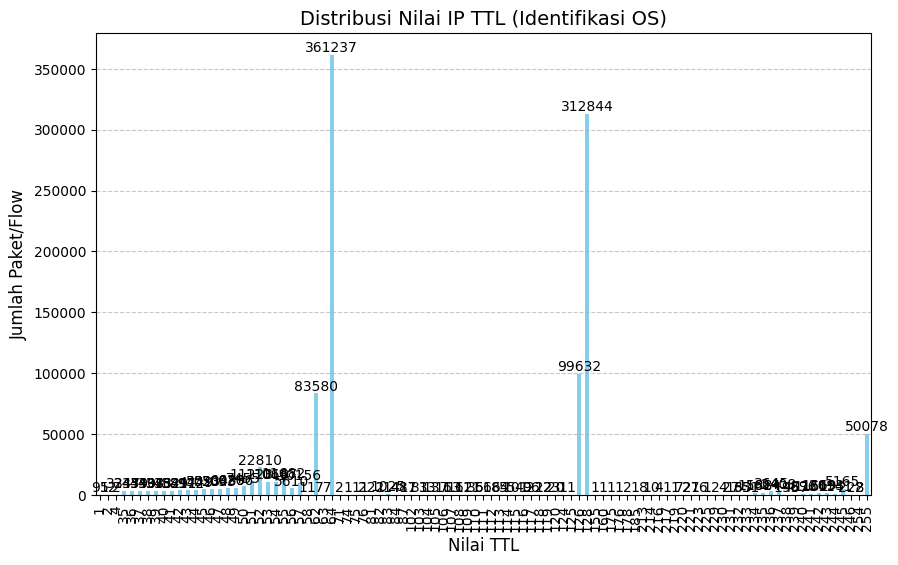


--- Estimasi Perangkat di Jaringan ---
estimated_os
Linux/Android/IoT                599525
Windows                          415784
Network Device (Router/Cisco)     73025
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# 1. Statistik Dasar TTL
print("--- Statistik Nilai TTL ---")
print(df['ip_ttl'].value_counts().sort_index())

# 2. Pemetaan OS Berdasarkan Standar TTL
def guess_os(ttl):
    if ttl <= 64: return 'Linux/Android/IoT'
    elif ttl <= 128: return 'Windows'
    else: return 'Network Device (Router/Cisco)'

df['estimated_os'] = df['ip_ttl'].apply(guess_os)

# 3. Visualisasi Distribusi TTL
plt.figure(figsize=(10, 6))
counts = df['ip_ttl'].value_counts().sort_index()
ax = counts.plot(kind='bar', color='skyblue')

# Tambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribusi Nilai IP TTL (Identifikasi OS)', fontsize=14)
plt.xlabel('Nilai TTL', fontsize=12)
plt.ylabel('Jumlah Paket/Flow', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Tampilkan Estimasi Perangkat
print("\n--- Estimasi Perangkat di Jaringan ---")
print(df['estimated_os'].value_counts())

In [ ]:
# 1. Klasifikasi Port Umum
def classify_port(port):
    common_ports = {
        80: 'HTTP', 443: 'HTTPS', 53: 'DNS', 
        21: 'FTP', 22: 'SSH', 23: 'Telnet',
        25: 'SMTP', 110: 'POP3', 143: 'IMAP',
        3389: 'RDP', 137: 'NetBIOS', 445: 'SMB'
    }
    return common_ports.get(port, 'Other/High Port')

df['service_name'] = df['dst_port'].apply(classify_port)

# 2. Tampilkan Distribusi Layanan
print("--- Distribusi Layanan (Top 10) ---")
service_counts = df['service_name'].value_counts()
print(service_counts)

# 3. Validasi Port 0
port_zero = df[df['dst_port'] == 0]
print(f"\n[!] Peringatan: Ditemukan {len(port_zero)} baris dengan Port 0 (Biasanya trafik ICMP atau Layer 2).")

--- Distribusi Layanan (Top 10) ---
service_name
Other/High Port    707804
DNS                176552
HTTP               135757
HTTPS               63857
SSH                  1254
NetBIOS              1171
FTP                   741
SMB                   395
RDP                   163
Telnet                160
SMTP                  160
POP3                  160
IMAP                  160
Name: count, dtype: int64

[!] Peringatan: Ditemukan 631 baris dengan Port 0 (Biasanya trafik ICMP atau Layer 2).


In [ ]:
# Mencari kolom yang hanya memiliki 1 nilai unik
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print(f"--- Validasi Fitur Konstan ---")
print(f"Ditemukan {len(constant_cols)} kolom konstan.")
print(f"Daftar kolom: {constant_cols}")

--- Validasi Fitur Konstan ---
Ditemukan 28 kolom konstan.
Daftar kolom: ['tcp_flags_res', 'bwd_pkts_s', 'tot_bwd_pkts', 'totlen_bwd_pkts', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_header_len', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'urg_flag_cnt', 'down_up_ratio', 'init_fwd_win_byts', 'init_bwd_win_byts', 'bwd_byts_b_avg', 'bwd_pkts_b_avg', 'bwd_blk_rate_avg', 'bwd_seg_size_avg', 'cwr_flag_count', 'subflow_bwd_pkts', 'subflow_bwd_byts']


In [ ]:
from scapy.all import PcapReader

# Ambil satu contoh IP lokal Bapak dari data sebelumnya
ip_lokal = "192.168.10.50" 
ditemukan_balasan = False

print(f"[*] Mengecek paket balasan untuk IP {ip_lokal}...")

with PcapReader(input_pcap) as pcap_reader:
    for i, packet in enumerate(pcap_reader):
        if packet.haslayer("IP"):
            # Jika IP lokal ada di posisi DESTINATION, berarti itu adalah paket DOWNLOAD (balasan)
            if packet["IP"].dst == ip_lokal:
                print(f"[!] Ditemukan paket masuk (Download) pada paket ke-{i}!")
                print(f"Detail: {packet['IP'].src} -> {packet['IP'].dst}")
                ditemukan_balasan = True
                break
        if i > 10000: # Cek 10rb paket saja cukup
            break

if not ditemukan_balasan:
    print("[X] Konfirmasi: Memang TIDAK ADA paket balasan di PCAP ini. Harus ambil data ulang.")
else:
    print("[V] Paket balasan ADA. Masalahnya ada di proses ekstraksi.")

[*] Mengecek paket balasan untuk IP 192.168.10.50...
[!] Ditemukan paket masuk (Download) pada paket ke-7!
Detail: 192.168.10.3 -> 192.168.10.50
[V] Paket balasan ADA. Masalahnya ada di proses ekstraksi.


In [ ]:
import pandas as pd
from scapy.all import PcapReader, IP, TCP, UDP, ICMP
import numpy as np

def extract_full_features(pcap_path, limit=20000):
    flows = {}
    print(f"[*] Memulai ekstraksi bidirectional dari: {pcap_path}")
    
    with PcapReader(pcap_path) as pcap_reader:
        for i, pkt in enumerate(pcap_reader):
            if i >= limit: break
            if not pkt.haslayer(IP): continue
            
            ip_src, ip_dst = pkt[IP].src, pkt[IP].dst
            proto = pkt.proto
            sport = pkt.sport if pkt.haslayer(TCP) or pkt.haslayer(UDP) else 0
            dport = pkt.dport if pkt.haslayer(TCP) or pkt.haslayer(UDP) else 0
            
            forward_key = (ip_src, ip_dst, sport, dport, proto)
            backward_key = (ip_dst, ip_src, dport, sport, proto)
            
            current_time = float(pkt.time)
            payload_len = len(pkt[IP].payload) - (pkt[IP].ihl * 4)

            if forward_key in flows:
                d = flows[forward_key]
                d['tot_fwd_pkts'] += 1
                d['tot_fwd_payload'] += payload_len
                d['flow_duration'] = current_time - d['start_time']

                # Hitung IAT Forward
                iat = current_time - d['last_pkt_time']
                d['iat_list'].append(iat)
                d['last_pkt_time'] = current_time
                
            elif backward_key in flows:
                d = flows[backward_key]
                d['tot_bwd_pkts'] += 1
                d['tot_bwd_payload'] += payload_len
                d['flow_duration'] = current_time - d['start_time']

                # Hitung IAT Backward (digabung ke flow yang sama)
                iat = current_time - d['last_pkt_time']
                d['iat_list'].append(iat)
                d['last_pkt_time'] = current_time

            else:
                # Inisialisasi Flow Baru
                flows[forward_key] = {
                    'src_ip': ip_src, 'dst_ip': ip_dst,
                    'src_port': sport, 'dst_port': dport, 'protocol': proto,
                    'ip_ttl': pkt[IP].ttl,
                    'icmp_type': pkt[ICMP].type if pkt.haslayer(ICMP) else -1,
                    'icmp_code': pkt[ICMP].code if pkt.haslayer(ICMP) else -1,
                    'tcp_window': pkt[TCP].window if pkt.haslayer(TCP) else 0,
                    'tcp_flags_str': str(pkt[TCP].flags) if pkt.haslayer(TCP) else "",
                    'payload_len_custom': payload_len,
                    'start_time': current_time,
                    'last_pkt_time': current_time,
                    'iat_list': [],
                    'flow_duration': 0,
                    'tot_fwd_pkts': 1,
                    'tot_bwd_pkts': 0,
                    'tot_fwd_payload': payload_len,
                    'tot_bwd_payload': 0,
                    'timestamp': pd.to_datetime(current_time, unit='s')
                }

    df_result = pd.DataFrame(flows.values())
    
    # --- HITUNG FITUR TURUNAN ---
    
    # 1. Down-Up Ratio
    df_result['down_up_ratio'] = df_result['tot_bwd_payload'] / df_result['tot_fwd_payload'].replace(0, 1)
    
    # 2. Perbaikan durasi 0 agar tidak pembagian nol (Epsilon)
    df_result.loc[df_result['flow_duration'] <= 0, 'flow_duration'] = 0.000001
    
    # 3. Fitur Baru: Throughput (Bytes/sec)
    # Total Byte (Fwd + Bwd) dibagi Durasi
    df_result['flow_byts_s'] = (df_result['tot_fwd_payload'] + df_result['tot_bwd_payload']) / df_result['flow_duration']
    
    # 4. Fitur Baru: Packet Rate (Packets/sec)
    df_result['flow_pkts_s'] = (df_result['tot_fwd_pkts'] + df_result['tot_bwd_pkts']) / df_result['flow_duration']

    # 5. Statistik IAT
    df_result['flow_iat_mean'] = df_result['iat_list'].apply(lambda x: np.mean(x) if x else 0)
    df_result['flow_iat_max'] = df_result['iat_list'].apply(lambda x: np.max(x) if x else 0)
    
    df_result = df_result.drop(columns=['iat_list'])
    
    return df_result

# Jalankan proses
df_final = extract_full_features("D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap")

# Tampilkan kolom-kolom kunci
cols_to_show = ['src_ip', 'dst_ip', 'down_up_ratio', 'flow_byts_s', 'flow_pkts_s', 'flow_iat_mean']
print(df_final[cols_to_show].head(10))

[*] Memulai ekstraksi bidirectional dari: D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap
          src_ip        dst_ip  down_up_ratio   flow_byts_s   flow_pkts_s  \
0  192.168.10.50  192.168.10.3       0.196721  7.251256e+01      0.425710   
1  192.168.10.50  192.168.10.3       0.768150  1.071371e+02      0.425710   
2   192.168.10.9    224.0.0.22      -0.000000 -1.460921e+02     73.046047   
3   192.168.10.9   224.0.0.252       0.000000  3.515569e+03    219.723087   
4   192.168.10.9  192.168.10.3       1.000000  2.019997e+01      0.429787   
5   192.168.10.9  192.168.10.3       1.724638  1.534103e+06  16320.249027   
6   192.168.10.9  192.168.10.3       1.724638  1.670613e+06  17772.474576   
7   192.168.10.9  192.168.10.3       1.800000  7.726349e+05  27594.105263   
8   192.168.10.9  192.168.10.3       1.800000  6.092893e+05  21760.332036   
9   192.168.10.9  192.168.10.3       1.016529  3.213219e+06  26337.858713   

   flow_iat_mean  
0       

In [ ]:
import pandas as pd

# Path file
file_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet"

# 1. Baca file Parquet
df = pd.read_parquet(file_path)

# 2. Daftar fitur yang diminta (disesuaikan dengan hasil ekstraksi sebelumnya)
# Jika 'payload_len' tidak ada, kita gunakan 'payload_len_custom'
kolom_diminta = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 
    'eth_src', 'eth_dst', 'icmp_type', 'icmp_code', 'ip_ttl', 
    'ip_id', 'tcp_window_size_value', 'tcp_mss', 'timestamp'
]

# Tambahkan pengecekan untuk kolom yang mungkin berbeda nama
if 'tcp_flags_str' in df.columns:
    kolom_diminta.append('tcp_flags_str')
if 'payload_len_custom' in df.columns:
    kolom_diminta.append('payload_len_custom')

# 3. Tampilkan 10 baris pertama
print(f"--- Menampilkan 10 Baris Fitur Pilihan (Total Flow: {len(df)}) ---")
# Menampilkan hanya kolom yang benar-benar ada di dataframe untuk menghindari error
kolom_ada = [c for c in kolom_diminta if c in df.columns]
print(df[kolom_ada].head(10).to_string())

# 4. Info tambahan jika ada kolom yang tidak ditemukan
kolom_hilang = set(kolom_diminta) - set(df.columns)
if kolom_hilang:
    print(f"\n[Catatan] Kolom berikut tidak ditemukan: {list(kolom_hilang)}")

--- Menampilkan 10 Baris Fitur Pilihan (Total Flow: 1088334) ---
          src_ip         dst_ip  src_port  dst_port  protocol            eth_src            eth_dst  icmp_type  icmp_code  ip_ttl  ip_id  tcp_window_size_value  tcp_mss            timestamp tcp_flags_str  payload_len_custom
0  192.168.10.50   192.168.10.3     56108      3268         6  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1      64  50515                    476        0  2017-07-07 18:59:50             A                  32
1   192.168.10.3  192.168.10.50      3268     56108         6  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1         -1         -1     128  28814                   2079        0  2017-07-07 18:59:50            PA                 104
2  192.168.10.50   192.168.10.3     42144       389         6  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1      64  53682                   1444        0  2017-07-07 18:59:50             A                  32
3   192.168.10.3  192.168.10.50       3

In [ ]:
## import pandas as pd

# Path ke file Anda
file_path = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Full_Fixed.parquet"
df = pd.read_parquet(file_path)

# --- PENGATURAN TAMPILAN PANDAS ---
pd.set_option('display.max_columns', None)      # Tampilkan semua kolom tanpa dipotong (...)
pd.set_option('display.expand_frame_repr', False) # Jangan pindahkan kolom ke baris baru
pd.set_option('display.width', 1000)             # Lebar tampilan dalam karakter
pd.set_option('display.max_colwidth', None)      # Jangan potong isi kolom yang panjang

# Daftar fitur yang Bapak inginkan
kolom_pilihan = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 
    'eth_src', 'eth_dst', 'icmp_type', 'icmp_code', 'ip_ttl', 
    'ip_id', 'tcp_window_size_value', 'tcp_mss', 'timestamp', 
    'tcp_flags_str', 'payload_len_custom'
]

# Pastikan hanya memanggil kolom yang ada di dataframe
kolom_ada = [c for c in kolom_pilihan if c in df.columns]

print(f"--- Data Full Width (10 Baris) ---")
print(df[kolom_ada].head(10))

--- Data Full Width (10 Baris) ---
          src_ip         dst_ip  src_port  dst_port  protocol            eth_src            eth_dst  icmp_type  icmp_code  ip_ttl  ip_id  tcp_window_size_value  tcp_mss            timestamp tcp_flags_str  payload_len_custom
0  192.168.10.50   192.168.10.3     56108      3268         6  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1      64  50443                    377        0  2017-07-07 18:59:50             A                  32
1   192.168.10.3  192.168.10.50      3268     56108         6  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1         -1         -1     128  25276                   2076        0  2017-07-07 18:59:50            PA                 104
2  192.168.10.50   192.168.10.3     42144       389         6  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d         -1         -1      64  53618                   1091        0  2017-07-07 18:59:50             A                  32
3   192.168.10.3  192.168.10.50       389     42144         6  18:66:

In [ ]:
# Cek apakah ada paket ICMP asli di hasil ekstraksi
df_icmp = df[df['protocol'] == 1]

if not df_icmp.empty:
    print("Ditemukan trafik ICMP:")
    print(df_icmp[['src_ip', 'dst_ip', 'icmp_type', 'icmp_code']].head())
else:
    print("Tidak ditemukan trafik ICMP dalam 5000 paket pertama ini.")

Ditemukan trafik ICMP:
            src_ip        dst_ip  icmp_type  icmp_code
193  192.168.10.14  192.168.10.3          3          3
263  192.168.10.14  192.168.10.3          3          3


In [ ]:
import pyarrow.parquet as pq

# Baca metadata saja (sangat cepat & hemat RAM)
file_path = 'hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet'
schema = pq.read_schema(file_path)

# Tampilkan daftar nama kolom
print("Daftar Kolom di File Parquet:")
for name in schema:
    print(f"- {name}")

Daftar Kolom di File Parquet:
- pyarrow.Field<src_ip: string>
- pyarrow.Field<dst_ip: string>
- pyarrow.Field<eth_src: string>
- pyarrow.Field<eth_dst: string>
- pyarrow.Field<ip_ttl: int64>
- pyarrow.Field<ip_id: int64>
- pyarrow.Field<payload_len: int64>
- pyarrow.Field<icmp_type: int64>
- pyarrow.Field<icmp_code: int64>
- pyarrow.Field<tcp_mss: int64>
- pyarrow.Field<tcp_window_size_value: int64>
- pyarrow.Field<flow_id: string>
- pyarrow.Field<frame_len: int64>
- pyarrow.Field<tcp_flags_str: string>
- pyarrow.Field<tcp_seq: int64>
- pyarrow.Field<tcp_ack: int64>


In [ ]:
import pandas as pd

file_path = 'D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet'

# Membaca hanya 10 baris pertama
df_sample = pd.read_parquet(file_path).head(10)

# Menampilkan semua kolom (agar tidak terpotong tanda ...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("--- Sampel 10 Baris Data ---")
print(df_sample)

--- Sampel 10 Baris Data ---
          src_ip         dst_ip            eth_src            eth_dst  ip_ttl  ip_id  payload_len  icmp_type  icmp_code  tcp_mss  tcp_window_size_value flow_id  frame_len tcp_flags_str     tcp_seq     tcp_ack
0  192.168.10.50   192.168.10.3  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d      64  50443           32         -1         -1        0                    377                  0             A  1785792206   909173081
1   192.168.10.3  192.168.10.50  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1     128  25276          104         -1         -1        0                   2076                  0            PA   909173009  1785792206
2  192.168.10.50   192.168.10.3  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d      64  53618           32         -1         -1        0                   1091                  0             A  1410818418  4281846520
3   192.168.10.3  192.168.10.50  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1     128  25277          348         -1         -1        0       

In [ ]:
import pandas as pd
import gc
import os
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# --- CONFIGURATION ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet"

# Pastikan folder output ada
os.makedirs(os.path.dirname(output_parquet), exist_ok=True)

# --- MONKEY PATCHING ---
original_get_data = Flow.get_data

def patched_get_data(self):
    # 1. Ambil 84 kolom statistik standar
    data = original_get_data(self)
    
    # 2. Tambahkan/Override kolom identitas dan kustom
    # Menggunakan nama kolom sesuai permintaan (menggunakan underscore agar kompatibel dengan parquet)
    data["flow_id"] = getattr(self, 'flow_id_custom', "")
    data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    data["frame_len"] = getattr(self, 'frame_len', 0)
    data["ip_id"] = getattr(self, 'ip_id', 0)
    data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    data["payload_len"] = getattr(self, 'payload_len_custom', 0)
    data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    data["tcp_window_size_value"] = getattr(self, 'tcp_win', 0)
    data["tcp_flags_str"] = getattr(self, 'tcp_flags_str', "")
    data["tcp_seq"] = getattr(self, 'tcp_seq', 0)
    data["tcp_ack"] = getattr(self, 'tcp_ack', 0)
    data["icmp_type"] = getattr(self, 'icmp_type', -1)
    data["icmp_code"] = getattr(self, 'icmp_code', -1)
    
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # Inisialisasi atribut kustom jika ini paket pertama dalam flow
    if not hasattr(self, 'eth_src'):
        self.eth_src = packet.src if hasattr(packet, 'src') else "00:00:00:00:00:00"
        self.eth_dst = packet.dst if hasattr(packet, 'dst') else "00:00:00:00:00:00"
        self.frame_len = len(packet)
        self.flow_id_custom = f"{packet['IP'].src}-{packet['IP'].dst}-{packet.sport}-{packet.dport}-{packet['IP'].proto}" if packet.haslayer("IP") else "non-ip"
        
        # Default values
        self.ip_id = 0
        self.ip_ttl = 0
        self.payload_len_custom = 0
        self.tcp_mss = 0
        self.tcp_win = 0
        self.tcp_flags_str = ""
        self.tcp_seq = 0
        self.tcp_ack = 0
        self.icmp_type = -1
        self.icmp_code = -1

    # Update metadata dari setiap paket yang lewat dalam flow ini
    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        if packet["IP"].payload:
            self.payload_len_custom = len(packet["IP"].payload)

    if packet.haslayer("TCP"):
        tcp = packet["TCP"]
        self.tcp_win = tcp.window
        self.tcp_flags_str = str(tcp.flags)
        self.tcp_seq = tcp.seq
        self.tcp_ack = tcp.ack
        opts = dict(x for x in tcp.options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)

    if packet.haslayer("ICMP"):
        self.icmp_type = packet["ICMP"].type
        self.icmp_code = packet["ICMP"].code

    # Jalankan perhitungan statistik asli
    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)
    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))
    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))
    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto

# Inject Patches
Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- MAIN EXECUTION ---
def run_extraction():
    flows = {}
    pkt_count = 0
    
    print(f"[*] Memproses {input_pcap}...")
    
    try:
        with PcapReader(input_pcap) as pcap_reader:
            for packet in pcap_reader:
                if packet.haslayer("IP"):
                    pkt_count += 1
                    p = packet["IP"]
                    key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0, packet.dport if hasattr(packet, 'dport') else 0)
                    
                    if key not in flows:
                        flows[key] = Flow(packet, PacketDirection.FORWARD)
                    
                    flows[key].add_packet(packet, PacketDirection.FORWARD)
                
                if pkt_count >= 5000:
                    break

        # Generate DataFrame
        df = pd.DataFrame([f.get_data() for f in flows.values()])
        
        # Simpan ke Parquet
        print(f"[*] Menyimpan ke {output_parquet}...")
        df.to_parquet(output_parquet, engine='pyarrow', index=False)
        print(f"[+] Selesai! Total Flow: {len(df)}")

    finally:
        del flows
        gc.collect() # Paksa pembersihan memori

if __name__ == "__main__":
    run_extraction()

In [ ]:
import scapy.config
from scapy.all import PcapReader
from scapy.all import Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
import pandas as pd
import os


# --- FORCE PATCH UNTUK FITUR BARU ---
def patched_get_data(self):
    # Ambil data asli cicflowmeter
    data = {} 
    # Kita buat manual dictionary-nya untuk memastikan fitur baru muncul
    data["src_ip"] = self.src_ip
    data["dst_ip"] = self.dest_ip
    data["eth_src"] = self.eth_src
    data["eth_dst"] = self.eth_dst
    data["ip_ttl"] = self.ip_ttl
    data["ip_id"] = self.ip_id
    #data["tcp_mss"] = self.tcp_mss
    #data["tcp_window_size_value"] = self.tcp_window_size_value
    data["payload_len"] = self.payload_len
    data["icmp_type"] = self.icmp_type
    data["icmp_code"] = self.icmp_code
    #data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    #data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    #data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    #data["ip_id"] = getattr(self, 'ip_id', 0)
    data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    data["tcp_window_size_value"] = getattr(self, 'tcp_window_size_value', 0)
    #data["payload_len"] = getattr(self, 'payload_len', 0)
    #data["icmp_type"] = getattr(self, 'icmp_type', -1)
    #data["icmp_code"] = getattr(self, 'icmp_code', -1)
    return data

def extreme_patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # 1. LOGIKA CUSTOM KITA (Update Fitur Baru)
    if self.eth_src == "00:00:00:00:00:00" and hasattr(packet, 'src'):
        self.eth_src = packet.src
        self.eth_dst = packet.dst

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        try:
            # Hitung payload murni
            self.payload_len = len(packet["IP"].payload.payload)
        except:
            self.payload_len = 0
    
    if packet.haslayer("TCP"):
        self.tcp_window_size_value = packet["TCP"].window
        self.tcp_flags_res = packet["TCP"].reserved
        opts = dict(x for x in packet["TCP"].options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)

    if packet.haslayer("ICMP"):
        self.icmp_type = packet["ICMP"].type
        self.icmp_code = packet["ICMP"].code

    # 2. LOGIKA ASLI CICFLOWMETER (Harus ada agar perhitungan Flow Duration dll tidak rusak)
    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)

    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))

    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))

    if "TCP" in packet:
        if direction == PacketDirection.FORWARD and self.init_window_size[direction] == 0:
            self.init_window_size[direction] = packet["TCP"].window
        elif direction == PacketDirection.REVERSE:
            self.init_window_size[direction] = packet["TCP"].window

    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto


# Terapkan patch ke class Flow
Flow.get_data = patched_get_data
Flow.add_packet = extreme_patched_add_packet

# --- KONFIGURASI TEST ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
LIMIT_PACKETS = 2000 

print(f"--- Mengetes 2000 Paket Pertama dengan Force Patch ---")
flows = {}
count = 0

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            if packet.haslayer("IP"):
                p = packet["IP"]
                key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0)
                
                if key not in flows:
                    flows[key] = Flow(packet, PacketDirection.FORWARD)
                
                # Kita panggil add_packet. Jika add_packet di flow.py Anda sudah 
                # Anda ganti (digabung), maka nilai di bawah ini akan terisi.
                flows[key].add_packet(packet, PacketDirection.FORWARD)

            if count >= LIMIT_PACKETS: break

    valid_data = [f.get_data() for f in flows.values()]
    df_test = pd.DataFrame(valid_data)

    # Tampilkan kolom untuk verifikasi
    print("\n--- HASIL EKSTRAKSI (Fitur Custom) ---")
    if not df_test.empty:
        print(df_test.head(10).to_string())
    else:
        print("Dataframe Kosong!")

except Exception as e:
    print(f"\nError: {e}")


# --- KONFIGURASI TEST ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
LIMIT_PACKETS = 2000 

print(f"--- Mengetes 2000 Paket Pertama ---")
flows = {}
count = 0

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            if packet.haslayer("IP"):
                p = packet["IP"]
                # 5-tuple key
                key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0, packet.dport if hasattr(packet, 'dport') else 0)
                
                if key not in flows:
                    flows[key] = Flow(packet, PacketDirection.FORWARD)
                
                flows[key].add_packet(packet, PacketDirection.FORWARD)

            if count >= LIMIT_PACKETS:
                print(f"\n[!] Limit {LIMIT_PACKETS} paket tercapai. Menghentikan ekstraksi...")
                break

    # Ekstrak data ke DataFrame untuk ditampilkan
    valid_data = [f.get_data() for f in flows.values()]
    df_test = pd.DataFrame(valid_data)

    # Tampilkan kolom-kolom custom untuk verifikasi
    custom_cols = ['src_ip', 'dst_ip', 'eth_src', 'eth_dst', 'ip_ttl', 'ip_id', 'tcp_mss', 'tcp_window_size_value', 'payload_len', 'icmp_type', 'icmp_code']
    
    print("\n--- HASIL EKSTRAKSI (Fitur Custom & Struktural) ---")
    # Menampilkan 10 baris pertama dari kolom yang kita modifikasi
    print(df_test[custom_cols].head(10).to_string())
    
    print(f"\nTotal Flow yang ditemukan: {len(df_test)}")
    print("Kolom yang tersedia:", df_test.columns.tolist())

except Exception as e:
    print(f"\nError saat testing: {e}")


--- Mengetes 2000 Paket Pertama dengan Force Patch ---

--- HASIL EKSTRAKSI (Fitur Custom) ---
          src_ip         dst_ip            eth_src            eth_dst  ip_ttl  ip_id  payload_len  icmp_type  icmp_code  tcp_mss  tcp_window_size_value
0  192.168.10.50   192.168.10.3  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d      64  50439            0         -1         -1        0                    377
1   192.168.10.3  192.168.10.50  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1     128  24631           72         -1         -1        0                   2079
2  192.168.10.50   192.168.10.3  00:19:b9:0a:69:f1  18:66:da:9b:e3:7d      64  53614            0         -1         -1        0                   1046
3   192.168.10.3  192.168.10.50  18:66:da:9b:e3:7d  00:19:b9:0a:69:f1     128  24632          316         -1         -1        0                   2079
4   192.168.10.9     224.0.0.22  b8:ac:6f:1d:1f:6c  01:00:5e:00:00:16       1      4            6         -1         -1        0                 

In [ ]:
import pandas as pd
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection

# --- 1. MODIFIKASI CLASS FLOW (Monkey Patching) ---

# Simpan fungsi asli agar bisa dipanggil kembali
original_get_data = Flow.get_data

def patched_get_data(self):
    # Ambil 84 kolom standar dari cicflowmeter
    data = original_get_data(self)
    
    # Tambahkan/Update 11 kolom custom Pak Arie
    data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    data["src_ip"] = getattr(self, 'src_ip', "")
    data["dst_ip"] = getattr(self, 'dest_ip', "") # cicflowmeter menggunakan dest_ip secara internal
    data["ip_id"] = getattr(self, 'ip_id', 0)
    data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    data["tcp_window_size_value"] = getattr(self, 'tcp_window_size_value', 0)
    data["payload_len"] = getattr(self, 'payload_len', 0)
    data["icmp_type"] = getattr(self, 'icmp_type', -1)
    data["icmp_code"] = getattr(self, 'icmp_code', -1)
    
    return data

def patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # Inisialisasi atribut custom jika belum ada (agar tidak error)
    if not hasattr(self, 'eth_src'):
        self.eth_src = "00:00:00:00:00:00"
        self.eth_dst = "00:00:00:00:00:00"
        self.ip_ttl = 0
        self.ip_id = 0
        self.tcp_mss = 0
        self.tcp_window_size_value = 0
        self.payload_len = 0
        self.icmp_type = -1
        self.icmp_code = -1

    # Ekstraksi Layer Ethernet
    if packet.haslayer("Ether"):
        self.eth_src = packet["Ether"].src
        self.eth_dst = packet["Ether"].dst

    # Ekstraksi Layer IP
    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        # Payload murni (Layer 4 ke atas)
        if packet["IP"].payload:
            self.payload_len = len(packet["IP"].payload)

    # Ekstraksi Layer TCP
    if packet.haslayer("TCP"):
        self.tcp_window_size_value = packet["TCP"].window
        opts = dict(x for x in packet["TCP"].options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)

    # Ekstraksi Layer ICMP
    if packet.haslayer("ICMP"):
        self.icmp_type = packet["ICMP"].type
        self.icmp_code = packet["ICMP"].code

    # JALANKAN LOGIKA ASLI CICFLOWMETER (Penting untuk 84 fitur lainnya)
    # Ini memastikan flow_duration, iat, dll terhitung otomatis
    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)

    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))

    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))

    if "TCP" in packet:
        if direction == PacketDirection.FORWARD and self.init_window_size[direction] == 0:
            self.init_window_size[direction] = packet["TCP"].window
        elif direction == PacketDirection.REVERSE:
            self.init_window_size[direction] = packet["TCP"].window

    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto

# Terapkan patch ke class Flow
Flow.get_data = patched_get_data
Flow.add_packet = patched_add_packet

# --- 2. PROSES EKSTRAKSI ---

input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
LIMIT_PACKETS = 5000 

flows = {}
count = 0

print(f"Sedang memproses {LIMIT_PACKETS} paket...")

with PcapReader(input_pcap) as pcap_reader:
    for packet in pcap_reader:
        if packet.haslayer("IP"):
            count += 1
            p = packet["IP"]
            # 5-tuple: (src, dst, proto, sport, dport)
            key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0, packet.dport if hasattr(packet, 'dport') else 0)
            
            if key not in flows:
                flows[key] = Flow(packet, PacketDirection.FORWARD)
            
            flows[key].add_packet(packet, PacketDirection.FORWARD)

        if count >= LIMIT_PACKETS: break

# Konversi ke DataFrame
df = pd.DataFrame([f.get_data() for f in flows.values()])

# Simpan ke Parquet
# df.to_parquet("hasil_ekstraksi.parquet")

print(f"\nEkstraksi Selesai!")
print(f"Jumlah Kolom: {len(df.columns)}")
print(f"Kolom Custom: {df[['eth_src', 'ip_ttl', 'tcp_mss', 'payload_len']].head()}")

In [ ]:
import scapy.config
from scapy.all import PcapReader, Packet
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os
import gc

# 1. --- FORCE PATCH (Agar fitur struktural masuk ke Flow) ---
def patched_get_data(self):
    #data = self.get_features() # Ambil fitur standar bawaan cicflowmeter
    # Tambahkan fitur custom kita
    #data["src_ip"] = self.src_ip
    #data["dst_ip"] = self.dest_ip
    #data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    #data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    #data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    #data["ip_id"] = getattr(self, 'ip_id', 0)
    #data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    #data["tcp_window_size_value"] = getattr(self, 'tcp_window_size_value', 0)
    #data["payload_len"] = getattr(self, 'payload_len', 0)
    #data["icmp_type"] = getattr(self, 'icmp_type', -1)
    #data["icmp_code"] = getattr(self, 'icmp_code', -1)

    data = {} 
    # Kita buat manual dictionary-nya untuk memastikan fitur baru muncul
    data["src_ip"] = self.src_ip
    data["dst_ip"] = self.dest_ip
    data["eth_src"] = self.eth_src
    data["eth_dst"] = self.eth_dst
    data["ip_ttl"] = self.ip_ttl
    data["ip_id"] = self.ip_id
    #data["tcp_mss"] = self.tcp_mss
    #data["tcp_window_size_value"] = self.tcp_window_size_value
    data["payload_len"] = self.payload_len
    data["icmp_type"] = self.icmp_type
    data["icmp_code"] = self.icmp_code
    #data["eth_src"] = getattr(self, 'eth_src', "00:00:00:00:00:00")
    #data["eth_dst"] = getattr(self, 'eth_dst', "00:00:00:00:00:00")
    #data["ip_ttl"] = getattr(self, 'ip_ttl', 0)
    #data["ip_id"] = getattr(self, 'ip_id', 0)
    data["tcp_mss"] = getattr(self, 'tcp_mss', 0)
    data["tcp_window_size_value"] = getattr(self, 'tcp_window_size_value', 0)
    #data["payload_len"] = getattr(self, 'payload_len', 0)
    #data["icmp_type"] = getattr(self, 'icmp_type', -1)
    #data["icmp_code"] = getattr(self, 'icmp_code', -1)
    return data

#def extreme_patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # Update MAC & Fitur Struktural
  #  if self.eth_src == "00:00:00:00:00:00" and hasattr(packet, 'src'):
   #     self.eth_src, self.eth_dst = packet.src, packet.dst
  #  if packet.haslayer("IP"):
  #      self.ip_ttl, self.ip_id = packet["IP"].ttl, packet["IP"].id
 #       try: self.payload_len = len(packet["IP"].payload.payload)
  #      except: self.payload_len = 0
  #  if packet.haslayer("TCP"):
  #      self.tcp_window_size_value = packet["TCP"].window
 #       opts = dict(x for x in packet["TCP"].options if isinstance(x, tuple))
 #       self.tcp_mss = opts.get('MSS', 0)
 #   if packet.haslayer("ICMP"):
 #       self.icmp_type, self.icmp_code = packet["ICMP"].type, packet["ICMP"].code

    # Logika Asli Cicflowmeter
#    self.packets.append((packet, direction))
 #   self.update_flow_bulk(packet, direction)
 #   self.update_subflow(packet)
 #   if self.start_timestamp != 0:
#        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))
  #  self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))
#    if self.start_timestamp == 0:
 #       self.start_timestamp = packet.time
 #       self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto

def extreme_patched_add_packet(self, packet: Packet, direction: PacketDirection) -> None:
    # 1. LOGIKA CUSTOM KITA (Update Fitur Baru)
    if self.eth_src == "00:00:00:00:00:00" and hasattr(packet, 'src'):
        self.eth_src = packet.src
        self.eth_dst = packet.dst

    if packet.haslayer("IP"):
        self.ip_ttl = packet["IP"].ttl
        self.ip_id = packet["IP"].id
        try:
            # Hitung payload murni
            self.payload_len = len(packet["IP"].payload.payload)
        except:
            self.payload_len = 0
    
    if packet.haslayer("TCP"):
        self.tcp_window_size_value = packet["TCP"].window
        self.tcp_flags_res = packet["TCP"].reserved
        opts = dict(x for x in packet["TCP"].options if isinstance(x, tuple))
        self.tcp_mss = opts.get('MSS', 0)

    if packet.haslayer("ICMP"):
        self.icmp_type = packet["ICMP"].type
        self.icmp_code = packet["ICMP"].code

    # 2. LOGIKA ASLI CICFLOWMETER (Harus ada agar perhitungan Flow Duration dll tidak rusak)
    self.packets.append((packet, direction))
    self.update_flow_bulk(packet, direction)
    self.update_subflow(packet)

    if self.start_timestamp != 0:
        self.flow_interarrival_time.append(1e6 * (float(packet.time) - float(self.latest_timestamp)))

    self.latest_timestamp = max(float(packet.time), float(self.latest_timestamp))

    if "TCP" in packet:
        if direction == PacketDirection.FORWARD and self.init_window_size[direction] == 0:
            self.init_window_size[direction] = packet["TCP"].window
        elif direction == PacketDirection.REVERSE:
            self.init_window_size[direction] = packet["TCP"].window

    if self.start_timestamp == 0:
        self.start_timestamp = packet.time
        self.protocol = packet["IP"].proto if packet.haslayer("IP") else packet.proto


# Terapkan Patch
Flow.get_data = patched_get_data
Flow.add_packet = extreme_patched_add_packet
scapy.config.conf.prog.tcpdump = None 

# 2. --- KONFIGURASI JALUR FILE ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet"
CHUNK_SIZE = 100000 # Simpan setiap 100rb paket untuk menjaga RAM

#def save_to_parquet(data, path):
  #  df = pd.DataFrame(data)
  #  if not os.path.isfile(path):
 #       df.to_parquet(path, engine='pyarrow', index=False)
 #   else:
  #      # Gunakan fastparquet untuk mode append
  #      from fastparquet import write
  #      write(path, df, append=True)

def save_to_parquet(data, path):
    df = pd.DataFrame(data)
    table = pa.Table.from_pandas(df)
    
    # Jika file belum ada, buat baru. Jika sudah ada, tambahkan data.
    if not os.path.exists(path):
        pq.write_table(table, path)
    else:
        # Menulis ke file yang sama sebagai row group baru
        # Catatan: pyarrow standar tidak mendukung append fisik ke file tunggal dengan mudah, 
        # cara terbaik adalah menulis file-file kecil ke folder (Partitioning)
        folder_path = path.replace(".parquet", "_dataset")
        os.makedirs(folder_path, exist_ok=True)
        pq.write_to_dataset(table, root_path=folder_path)
        
# 3. --- PROSES EKSTRAKSI ---
print(f"--- Memulai Ekstraksi Penuh ke Parquet ---")
flows, count = {}, 0

if os.path.exists(output_parquet): os.remove(output_parquet) # Hapus file lama jika ada

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            if packet.haslayer("IP"):
                p = packet["IP"]
                key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0)
                if key not in flows: flows[key] = Flow(packet, PacketDirection.FORWARD)
                flows[key].add_packet(packet, PacketDirection.FORWARD)

            if count % 5000 == 0:
                print(f"Status: {count} paket diproses...", end="\r")

            if count % CHUNK_SIZE == 0:
                print(f"\n[!] Menulis chunk {count} ke Parquet & reset RAM...")
                valid_data = [f.get_data() for f in flows.values()]
                if valid_data: save_to_parquet(valid_data, output_parquet)
                flows.clear(); gc.collect()

    if flows: # Sisa data terakhir
        save_to_parquet([f.get_data() for f in flows.values()], output_parquet)

    print(f"\nSelesai! Data disimpan di: {output_parquet}")
except Exception as e:
    print(f"\nError: {e}")


--- Memulai Ekstraksi Penuh ke Parquet ---
Status: 100000 paket diproses...
[!] Menulis chunk 100000 ke Parquet & reset RAM...
Status: 200000 paket diproses...
[!] Menulis chunk 200000 ke Parquet & reset RAM...
Status: 300000 paket diproses...
[!] Menulis chunk 300000 ke Parquet & reset RAM...
Status: 400000 paket diproses...
[!] Menulis chunk 400000 ke Parquet & reset RAM...
Status: 500000 paket diproses...
[!] Menulis chunk 500000 ke Parquet & reset RAM...
Status: 600000 paket diproses...
[!] Menulis chunk 600000 ke Parquet & reset RAM...
Status: 700000 paket diproses...
[!] Menulis chunk 700000 ke Parquet & reset RAM...
Status: 800000 paket diproses...
[!] Menulis chunk 800000 ke Parquet & reset RAM...
Status: 900000 paket diproses...
[!] Menulis chunk 900000 ke Parquet & reset RAM...
Status: 1000000 paket diproses...
[!] Menulis chunk 1000000 ke Parquet & reset RAM...
Status: 1100000 paket diproses...
[!] Menulis chunk 1100000 ke Parquet & reset RAM...
Status: 1200000 paket diprose

In [ ]:
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import os

# --- KONFIGURASI ---
input_Folder_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_dataset/"
output_File_parquet = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet"

def merge_parquet_dataset(input_dir, output_file):
    print(f"--- Memulai proses penggabungan dari folder: {input_dir} ---")
    
    # 1. Definisikan dataset dari folder (PyArrow akan mendeteksi semua file di dalamnya)
    dataset = ds.dataset(input_dir, format="parquet")
    
    # 2. Tulis dataset ke satu file tunggal
    # Catatan: max_rows_per_file diatur sangat besar agar tidak terpecah
    pq.write_table(dataset.to_table(), output_file, compression='snappy')
    
    print(f"--- Selesai! File tunggal tersimpan di: {output_file} ---")

# Eksekusi
if os.path.exists(input_Folder_parquet):
    merge_parquet_dataset(input_Folder_parquet, output_File_parquet)
else:
    print("Error: Folder input tidak ditemukan.")


--- Memulai proses penggabungan dari folder: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_dataset/ ---
--- Selesai! File tunggal tersimpan di: D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet ---


In [ ]:
import pandas as pd
import glob
import os

input_folder = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_dataset/"
output_file = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet"

# 1. Hitung total baris dari semua file di folder
total_rows_in_folder = 0
for f in glob.glob(os.path.join(input_folder, "*.parquet")):
    total_rows_in_folder += len(pd.read_parquet(f))

# 2. Hitung jumlah baris di file hasil gabungan
df_final = pd.read_parquet(output_file)
total_rows_final = len(df_final)

print(f"Total baris di folder (partisi): {total_rows_in_folder}")
print(f"Total baris di file tunggal     : {total_rows_final}")

if total_rows_in_folder == total_rows_final:
    print("✅ KONFIRMASI: Semua data berhasil digabungkan!")
else:
    print("❌ PERINGATAN: Ada selisih data!")


Total baris di folder (partisi): 479075
Total baris di file tunggal     : 479075
✅ KONFIRMASI: Semua data berhasil digabungkan!


In [ ]:
import pandas as pd

# 1. Tentukan Path File
path_csv = r"D:\Data science Cybersecurity\DATASETS\CICIDS2017\hasilExtractNewCicFlowMeter\Friday-WorkingHours.pcap_Flow.CSV"
path_parquet = r"D:\Data science Cybersecurity\DATASETS\CICIDS2017\hasilExtractDgnCicflowsmeter\Friday-WorkingHoursV1.parquet"

# 2. Baca Dataset
# low_memory=False untuk menangani kolom campuran di CSV besar
df_csv = pd.read_csv(path_csv, low_memory=False)
df_parquet = pd.read_parquet(path_parquet)

# Bersihkan nama kolom CSV dari spasi (penting untuk CICFlowMeter Java)
df_csv.columns = df_csv.columns.str.strip()

# 3. Ambil Daftar Kolom
cols_csv = sorted(df_csv.columns.tolist())
cols_parquet = sorted(df_parquet.columns.tolist())

# 4. Cari Perbedaan
set_csv = set(cols_csv)
set_parquet = set(cols_parquet)
only_in_csv = sorted(list(set_csv - set_parquet))
only_in_parquet = sorted(list(set_parquet - set_csv))

# 5. Tampilkan Hasil Lengkap
print("="*50)
print("STATISTIK DATA")
print("="*50)
print(f"File CSV     : {len(df_csv)} baris, {len(cols_csv)} kolom")
print(f"File Parquet : {len(df_parquet)} baris, {len(cols_parquet)} kolom")

print("\n" + "="*50)
print(f"DAFTAR SEMUA KOLOM DI CSV ({len(cols_csv)})")
print("="*50)
print(", ".join(cols_csv))

print("\n" + "="*50)
print(f"DAFTAR SEMUA KOLOM DI PARQUET ({len(cols_parquet)})")
print("="*50)
print(", ".join(cols_parquet))

print("\n" + "="*50)
print("PERBEDAAN KOLOM")
print("="*50)
print(f"🔍 Ada di CSV tapi TIDAK ADA di Parquet ({len(only_in_csv)}):")
print(only_in_csv if only_in_csv else "- Tidak ada -")

print(f"\n🔍 Ada di Parquet tapi TIDAK ADA di CSV ({len(only_in_parquet)}):")
print(only_in_parquet if only_in_parquet else "- Tidak ada -")


STATISTIK DATA
File CSV     : 695256 baris, 84 kolom
File Parquet : 479075 baris, 11 kolom

DAFTAR SEMUA KOLOM DI CSV (84)
ACK Flag Count, Active Max, Active Mean, Active Min, Active Std, Average Packet Size, Bwd Bulk Rate Avg, Bwd Bytes/Bulk Avg, Bwd Header Length, Bwd IAT Max, Bwd IAT Mean, Bwd IAT Min, Bwd IAT Std, Bwd IAT Total, Bwd Init Win Bytes, Bwd PSH Flags, Bwd Packet Length Max, Bwd Packet Length Mean, Bwd Packet Length Min, Bwd Packet Length Std, Bwd Packet/Bulk Avg, Bwd Packets/s, Bwd Segment Size Avg, Bwd URG Flags, CWR Flag Count, Down/Up Ratio, Dst IP, Dst Port, ECE Flag Count, FIN Flag Count, FWD Init Win Bytes, Flow Bytes/s, Flow Duration, Flow IAT Max, Flow IAT Mean, Flow IAT Min, Flow IAT Std, Flow ID, Flow Packets/s, Fwd Act Data Pkts, Fwd Bulk Rate Avg, Fwd Bytes/Bulk Avg, Fwd Header Length, Fwd IAT Max, Fwd IAT Mean, Fwd IAT Min, Fwd IAT Std, Fwd IAT Total, Fwd PSH Flags, Fwd Packet Length Max, Fwd Packet Length Mean, Fwd Packet Length Min, Fwd Packet Length Std,

In [ ]:
import pandas as pd

# 1. Tentukan Path File
path_csv = r"D:\Data science Cybersecurity\DATASETS\CICIDS2017\hasilExtractNewCicFlowMeter\Friday-WorkingHours.pcap_Flow.CSV"
path_parquet = r"D:\Data science Cybersecurity\DATASETS\CICIDS2017\hasilExtractDgnCicflowsmeter\Friday-WorkingHoursV1.parquet"

# 2. Baca Dataset
df_csv = pd.read_csv(path_csv, low_memory=False)
df_parquet = pd.read_parquet(path_parquet)

# Bersihkan nama kolom CSV dari spasi
df_csv.columns = df_csv.columns.str.strip()

# 3. Ambil Daftar Kolom
cols_csv = sorted(df_csv.columns.tolist())
cols_parquet = sorted(df_parquet.columns.tolist())

# 4. Cari Perbedaan dan Persamaan
set_csv = set(cols_csv)
set_parquet = set(cols_parquet)

only_in_csv = sorted(list(set_csv - set_parquet))
only_in_parquet = sorted(list(set_parquet - set_csv))
# Penambahan: Mencari kolom yang ada di KEDUANYA
common_cols = sorted(list(set_csv & set_parquet))

# 5. Tampilkan Hasil Lengkap
print("="*50)
print("STATISTIK DATA")
print("="*50)
print(f"File CSV     : {len(df_csv)} baris, {len(cols_csv)} kolom")
print(f"File Parquet : {len(df_parquet)} baris, {len(cols_parquet)} kolom")

print("\n" + "="*50)
print(f"🔍 KOLOM YANG ADA DI KEDUA FILE ({len(common_cols)})")
print("="*50)
print(", ".join(common_cols))

print("\n" + "="*50)
print("PERBEDAAN KOLOM")
print("="*50)
print(f"❌ Ada di CSV tapi TIDAK ADA di Parquet ({len(only_in_csv)}):")
print(only_in_csv if only_in_csv else "- Tidak ada -")

print(f"\n✅ Ada di Parquet tapi TIDAK ADA di CSV ({len(only_in_parquet)}):")
print(only_in_parquet if only_in_parquet else "- Tidak ada -")


STATISTIK DATA
File CSV     : 695256 baris, 84 kolom
File Parquet : 479075 baris, 11 kolom

🔍 KOLOM YANG ADA DI KEDUA FILE (0)


PERBEDAAN KOLOM
❌ Ada di CSV tapi TIDAK ADA di Parquet (84):
['ACK Flag Count', 'Active Max', 'Active Mean', 'Active Min', 'Active Std', 'Average Packet Size', 'Bwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Header Length', 'Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Total', 'Bwd Init Win Bytes', 'Bwd PSH Flags', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Bwd Packet/Bulk Avg', 'Bwd Packets/s', 'Bwd Segment Size Avg', 'Bwd URG Flags', 'CWR Flag Count', 'Down/Up Ratio', 'Dst IP', 'Dst Port', 'ECE Flag Count', 'FIN Flag Count', 'FWD Init Win Bytes', 'Flow Bytes/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Min', 'Flow IAT Std', 'Flow ID', 'Flow Packets/s', 'Fwd Act Data Pkts', 'Fwd Bulk Rate Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Header Length', 'Fwd IAT Max', 'Fwd I

In [ ]:
### import scapy.config
from scapy.all import PcapReader
import cicflowmeter.features.context
import cicflowmeter.flow
import cicflowmeter.features.packet_count
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
import pandas as pd
import os
import gc

# --- PATCH (Tetap Sama) ---
def fixed_get_packet_flow_key(packet, direction):
    src_ip = packet["IP"].src if "IP" in packet else "0.0.0.0"
    dest_ip = packet["IP"].dst if "IP" in packet else "0.0.0.0"
    if "TCP" in packet:
        src_port, dest_port = packet["TCP"].sport, packet["TCP"].dport
    elif "UDP" in packet:
        src_port, dest_port = packet["UDP"].sport, packet["UDP"].dport
    else:
        src_port, dest_port = 0, 0
    return (dest_ip, src_ip, src_port, dest_port) if direction == PacketDirection.FORWARD else (src_ip, dest_ip, dest_port, src_port)

def fixed_get_payload(packet):
    if packet.haslayer("TCP"): return packet["TCP"].payload
    if packet.haslayer("UDP"): return packet["UDP"].payload
    if packet.haslayer("ICMP"): return packet["ICMP"].payload
    return b""

cicflowmeter.features.context.get_packet_flow_key = fixed_get_packet_flow_key
cicflowmeter.flow.get_packet_flow_key = fixed_get_packet_flow_key
cicflowmeter.features.packet_count.PacketCount.get_payload = staticmethod(fixed_get_payload)
scapy.config.conf.prog.tcpdump = None 

# --- KONFIGURASI ---
input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_csv = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.csv"
CHUNK_PACKETS = 50000  # Tulis ke disk setiap 50 ribu paket

def save_to_csv(data, path):
    df = pd.DataFrame(data)
    if not os.path.isfile(path):
        df.to_csv(path, index=False)
    else:
        df.to_csv(path, mode='a', header=False, index=False)

print("--- Memulai Ekstraksi Optimized (Incremental Writing) ---")
flows = {}
count = 0

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            if packet.haslayer("IP"):
                p = packet["IP"]
                key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0)
                
                if key not in flows:
                    flows[key] = Flow(packet, PacketDirection.FORWARD)
                    flows[key].protocol = p.proto 
                
                flows[key].add_packet(packet, PacketDirection.FORWARD)

            # MONITORING & OPTIMASI RAM
            if count % 1000 == 0:
                print(f"Memproses {count} paket... Flows aktif: {len(flows)}", end="\r")

            # PERIODIC SAVE (PENTING: Memindahkan data dari RAM ke Disk)
            if count % CHUNK_PACKETS == 0:
                print(f"\n[!] Mencapai {count} paket. Mengosongkan RAM & Menulis ke CSV...")
                valid_data = [f.get_data() for f in flows.values() if len(f.packets) > 0]
                if valid_data:
                    save_to_csv(valid_data, output_csv)
                
                # Kosongkan memory
                flows.clear()
                gc.collect() 

    # Simpan sisa data terakhir
    if flows:
        print(f"\nMenyimpan sisa {len(flows)} flows terakhir...")
        valid_data = [f.get_data() for f in flows.values() if len(f.packets) > 0]
        if valid_data:
            save_to_csv(valid_data, output_csv)

    print(f"\nSukses! File tersimpan di: {output_csv}")

except Exception as e:
    print(f"\nGlobal Error: {e}")
    import traceback; traceback.print_exc()


In [ ]:
import pandas as pd
from pathlib import Path

# --- KONFIGURASI DARI USER ---
file_input = Path('hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.csv')
file_output = Path('hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet')
# -----------------------------

# 1. Membaca file CSV
# Jika file sangat besar, pertimbangkan menggunakan parameter low_memory=False
df = pd.read_csv(file_input)

# 2. Menyimpan ke format Parquet
# index=False disarankan agar dataframe tidak membuat kolom index tambahan di Parquet
df.to_parquet(file_output, engine='pyarrow', index=False)

print(f"Konversi selesai! File disimpan di: {file_output}")


Konversi selesai! File disimpan di: hasilExtractDgnCicflowsmeter\Friday-WorkingHoursV1.parquet


In [ ]:
import pyarrow.parquet as pq

# Baca metadata saja (sangat cepat & hemat RAM)
file_path = 'hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet'
schema = pq.read_schema(file_path)

# Tampilkan daftar nama kolom
print("Daftar Kolom di File Parquet:")
for name in schema.names:
    print(f"- {name}")


Daftar Kolom di File Parquet:
- src_ip
- dst_ip
- src_port
- dst_port
- protocol
- eth_src
- eth_dst
- icmp_type
- icmp_code
- timestamp
- flow_duration
- flow_byts_s
- flow_pkts_s
- fwd_pkts_s
- bwd_pkts_s
- tot_fwd_pkts
- tot_bwd_pkts
- totlen_fwd_pkts
- totlen_bwd_pkts
- fwd_pkt_len_max
- fwd_pkt_len_min
- fwd_pkt_len_mean
- fwd_pkt_len_std
- bwd_pkt_len_max
- bwd_pkt_len_min
- bwd_pkt_len_mean
- bwd_pkt_len_std
- pkt_len_max
- pkt_len_min
- pkt_len_mean
- pkt_len_std
- pkt_len_var
- fwd_header_len
- bwd_header_len
- fwd_seg_size_min
- fwd_act_data_pkts
- flow_iat_mean
- flow_iat_max
- flow_iat_min
- flow_iat_std
- fwd_iat_tot
- fwd_iat_max
- fwd_iat_min
- fwd_iat_mean
- fwd_iat_std
- bwd_iat_tot
- bwd_iat_max
- bwd_iat_min
- bwd_iat_mean
- bwd_iat_std
- fwd_psh_flags
- bwd_psh_flags
- fwd_urg_flags
- bwd_urg_flags
- fin_flag_cnt
- syn_flag_cnt
- rst_flag_cnt
- psh_flag_cnt
- ack_flag_cnt
- urg_flag_cnt
- ece_flag_cnt
- down_up_ratio
- pkt_size_avg
- init_fwd_win_byts
- init_bwd_win

In [ ]:
import pyarrow.parquet as pq

# Baca metadata saja (sangat cepat & hemat RAM)
file_path = 'hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.parquet'
schema = pq.read_schema(file_path)

# Tampilkan daftar nama kolom
print("Daftar Kolom di File Parquet:")
for name in schema:
    print(f"- {name}")

Daftar Kolom di File Parquet:
- pyarrow.Field<src_ip: string>
- pyarrow.Field<dst_ip: string>
- pyarrow.Field<src_port: int64>
- pyarrow.Field<dst_port: int64>
- pyarrow.Field<protocol: int64>
- pyarrow.Field<eth_src: string>
- pyarrow.Field<eth_dst: string>
- pyarrow.Field<icmp_type: int64>
- pyarrow.Field<icmp_code: int64>
- pyarrow.Field<timestamp: string>
- pyarrow.Field<flow_duration: double>
- pyarrow.Field<flow_byts_s: double>
- pyarrow.Field<flow_pkts_s: double>
- pyarrow.Field<fwd_pkts_s: double>
- pyarrow.Field<bwd_pkts_s: double>
- pyarrow.Field<tot_fwd_pkts: int64>
- pyarrow.Field<tot_bwd_pkts: int64>
- pyarrow.Field<totlen_fwd_pkts: int64>
- pyarrow.Field<totlen_bwd_pkts: int64>
- pyarrow.Field<fwd_pkt_len_max: int64>
- pyarrow.Field<fwd_pkt_len_min: int64>
- pyarrow.Field<fwd_pkt_len_mean: double>
- pyarrow.Field<fwd_pkt_len_std: double>
- pyarrow.Field<bwd_pkt_len_max: int64>
- pyarrow.Field<bwd_pkt_len_min: int64>
- pyarrow.Field<bwd_pkt_len_mean: int64>
- pyarrow.Field

In [ ]:
import pandas as pd
import os

file_output = 'D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1.csv'

if os.path.exists(file_output):
    # Membaca hanya 100 baris pertama (sangat hemat RAM)
    df_sample = pd.read_csv(file_output, nrows=100)

    print(f"File ditemukan. Menampilkan info dari sampel 100 baris:")
    print(f"Nama Kolom:\n {df_sample.columns.tolist()}")
    print(f"Nama Kolom:\n {df_sample.columns.tolist()}")
    #print(f"\nContoh 5 Baris Pertama:\n {df_sample.head()}")
    
    # Untuk jumlah baris total, gunakan cara streaming yang kita bahas sebelumnya
    # karena df.shape akan memicu MemoryError pada file 20GB+
else:
    print("File tidak ditemukan.")


File ditemukan. Menampilkan info dari sampel 100 baris:
Nama Kolom:
 ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'eth_src', 'eth_dst', 'icmp_type', 'icmp_code', 'timestamp', 'flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fin_flag_cnt', 'syn_flag_cnt', 'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cn

In [ ]:
import scapy.config
from scapy.all import PcapReader
import cicflowmeter.features.context
import cicflowmeter.flow
import cicflowmeter.features.packet_count
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
import pandas as pd

# --- PATCH 1: Protocol Support ---
def fixed_get_packet_flow_key(packet, direction):
    src_ip = packet["IP"].src if "IP" in packet else "0.0.0.0"
    dest_ip = packet["IP"].dst if "IP" in packet else "0.0.0.0"
    if "TCP" in packet:
        src_port, dest_port = packet["TCP"].sport, packet["TCP"].dport
    elif "UDP" in packet:
        src_port, dest_port = packet["UDP"].sport, packet["UDP"].dport
    else:
        src_port, dest_port = 0, 0
    return (dest_ip, src_ip, src_port, dest_port) if direction == PacketDirection.FORWARD else (src_ip, dest_ip, dest_port, src_port)

# --- PATCH 2: Payload Fix ---
def fixed_get_payload(packet):
    if packet.haslayer("TCP"): return packet["TCP"].payload
    if packet.haslayer("UDP"): return packet["UDP"].payload
    if packet.haslayer("ICMP"): return packet["ICMP"].payload
    return b""

# Apply Monkey Patches
cicflowmeter.features.context.get_packet_flow_key = fixed_get_packet_flow_key
cicflowmeter.flow.get_packet_flow_key = fixed_get_packet_flow_key
cicflowmeter.features.packet_count.PacketCount.get_payload = staticmethod(fixed_get_payload)

scapy.config.conf.prog.tcpdump = None 

input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_csv = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Final_v3.csv"

print("--- Memulai Ekstraksi (v3: Index & Empty Flow Protection) ---")
flows = {}
count = 0

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            if packet.haslayer("IP"):
                p = packet["IP"]
                key = (p.src, p.dst, p.proto, packet.sport if hasattr(packet, 'sport') else 0)
                
                if key not in flows:
                    # Explicitly pass protocol to the Flow object
                    flows[key] = Flow(packet, PacketDirection.FORWARD)
                    flows[key].protocol = p.proto 
                
                # Ensure the packet is added to the flow
                flows[key].add_packet(packet, PacketDirection.FORWARD)

            if count % 500 == 0: print(f"Memproses {count} paket...", end="\r")
            #if count >= 5000: break # Increased to 5000 for better data

    print(f"\nSelesai. Memvalidasi {len(flows)} flows...")

    # PROTECTION: Only call get_data() if the flow actually has packets
    valid_data = []
    for f in flows.values():
        if len(f.packets) > 0:
            try:
                valid_data.append(f.get_data())
            except Exception as e:
                continue # Skip flows that still cause errors

    if not valid_data:
        print("Error: Tidak ada data valid yang bisa diekstrak.")
    else:
        df = pd.DataFrame(valid_data)
        df.to_csv(output_csv, index=False)
        print(f"Sukses! Berhasil menyimpan {len(df)} flows.")
        
        print("\n--- HASIL PREVIEW (Custom Columns) ---")
        cols = ['src_ip', 'dst_ip', 'eth_src', 'eth_dst', 'icmp_type', 'icmp_code']
        existing_cols = [c for c in cols if c in df.columns]
        print(df[existing_cols].head())

except Exception as e:
    print(f"\nGlobal Error: {e}")
    import traceback; traceback.print_exc()


--- Memulai Ekstraksi (v3: Index & Empty Flow Protection) ---
Memproses 106500 paket...

In [ ]:
import scapy.config
from scapy.all import PcapReader
from cicflowmeter.flow import Flow
from cicflowmeter.features.context import PacketDirection
import pandas as pd

# Matikan tcpdump
scapy.config.conf.prog.tcpdump = None 

input_pcap = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/PCAPs/Friday-WorkingHoursV1.pcap"
output_csv = "D:/Data science Cybersecurity/DATASETS/CICIDS2017/hasilExtractDgnCicflowsmeter/Friday-WorkingHoursV1_Final_Debug.csv"

print("--- Memulai Ekstraksi Manual (Bypass FlowSession) ---")

flows = {}
count = 0

try:
    with PcapReader(input_pcap) as pcap_reader:
        for packet in pcap_reader:
            count += 1
            
            # Gunakan logika sederhana untuk mendefinisikan flow key
            if packet.haslayer("IP"):
                p = packet["IP"]
                # Key: (SrcIP, DstIP, SrcPort, DstPort, Proto)
                # Untuk kesederhanaan debug, kita pakai tuple string
                key = f"{p.src}-{p.dst}-{packet.sport if hasattr(packet, 'sport') else 0}"
                
                if key not in flows:
                    # Ini akan memanggil __init__ di flow.py Anda
                    flows[key] = Flow(packet, PacketDirection.FORWARD)
                else:
                    # Ini akan memanggil add_packet di flow.py Anda
                    flows[key].add_packet(packet, PacketDirection.FORWARD)

            if count % 500 == 0:
                print(f"Memproses {count} paket...", end="\r")
            if count >= 2000: break

    print(f"\nSelesai. Mengambil data dari {len(flows)} flow...")

    # Memanggil get_data() di flow.py Anda
    data_list = [f.get_data() for f in flows.values()]
    
    df = pd.DataFrame(data_list)
    df.to_csv(output_csv, index=False)
    
    print("\n--- HASIL PREVIEW ---")
    # Cek kolom custom Anda
    print(df[['src_ip', 'dst_ip', 'eth_src', 'eth_dst', 'icmp_type', 'icmp_code']].head())

except Exception as e:
    print(f"\nError: {e}")
    import traceback
    traceback.print_exc()


--- Memulai Ekstraksi Manual (Bypass FlowSession) ---

Error: Only TCP protocols are supported.


Traceback (most recent call last):
  File "C:\Users\user\AppData\Local\Temp\ipykernel_22304\3757164731.py", line 32, in <module>
    flows[key] = Flow(packet, PacketDirection.FORWARD)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Roaming\Python\Python311\site-packages\cicflowmeter\flow.py", line 32, in __init__
    ) = get_packet_flow_key(packet, direction)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Roaming\Python\Python311\site-packages\cicflowmeter\features\context\__init__.py", line 43, in get_packet_flow_key
    src_ip = "0.0.0.0"
Exception: Only TCP protocols are supported.


In [ ]:
import pandas as pd
import os

file_output = 'hasilGabunganCSV/CICIDS2017_combined.csv'

if os.path.exists(file_output):
    # Membaca hanya 100 baris pertama (sangat hemat RAM)
    df_sample = pd.read_csv(file_output, nrows=100)

    print(f"File ditemukan. Menampilkan info dari sampel 100 baris:")
    print(f"Nama Kolom:\n {df_sample.columns.tolist()}")
    #print(f"\nContoh 5 Baris Pertama:\n {df_sample.head()}")
    
    # Untuk jumlah baris total, gunakan cara streaming yang kita bahas sebelumnya
    # karena df.shape akan memicu MemoryError pada file 20GB+
else:
    print("File tidak ditemukan.")


File ditemukan. Menampilkan info dari sampel 100 baris:
Nama Kolom:
 ['frame.number', 'frame.time', 'frame.time_delta', 'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'ip.proto', 'icmp.type', 'icmp.code', 'tcp.srcport', 'udp.srcport', 'tcp.dstport', 'udp.dstport', 'frame.len', 'tcp.flags.str', 'tcp.seq', 'tcp.ack', '_ws.col.protocol', '_ws.col.info']


In [ ]:
import dpkt
import pandas as pd
import os

file_input = 'PCAPs/Friday-WorkingHours.pcap'
with open('Friday-WorkingHours.pcap', 'rb') as f:
    pcap = dpkt.pcap.Reader(f) # If this fails here, it's definitely a format/corruption issue
